# Lección 14.2 · Diversidad alfa y beta: cuántos microbios hay en una muestra y cuánto se parecen dos intestinos

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/juvenalyosa/bioinformatica-practica/blob/main/modulo-14-metagenomica/14.2_diversidad_alfa_beta.ipynb) [![Copiloto: Claude](https://img.shields.io/badge/Copiloto-Claude-D97757?logo=claude&logoColor=white)](https://claude.ai) [![Licencia: MIT](https://img.shields.io/badge/Licencia-MIT-2a78d6.svg)](https://github.com/juvenalyosa/bioinformatica-practica/blob/main/LICENSE)

**Módulo 14 — Metagenómica y microbioma** · Bioinformática Práctica (Maestría)

👤 **Juvenal Yosa, PhD** · ✉️ [juvenal.yosa@gmail.com](mailto:juvenal.yosa@gmail.com) · 🤖 Copiloto: **Claude** (Anthropic)

| ⏱️ Duración | 📶 Nivel | 🧰 Requisitos |
|---|---|---|
| ~4 horas | Intermedio–avanzado | Lección 14.1 (16S rRNA y tabla de ASVs); probabilidad básica (binomial, Poisson); álgebra lineal (autovalores); logaritmos |

---

## 🎯 Objetivos de aprendizaje

Al terminar esta clase usted podrá:

1. **Describir** una tabla de abundancias de microbioma con la notación del libro ($x_{ki}$, $N_k$, $p_{ki}$) y
   **explicar** por qué casi todas sus celdas son ceros y por qué la profundidad $N_k$ cambia de muestra en muestra.
2. **Calcular** a mano y con código la riqueza $S$, la entropía de Shannon $H$, el índice de Simpson $D$ (y sus
   formas $1-D$ y $1/D$) y la equidad de Pielou $J$, sabiendo a qué pregunta responde cada uno.
3. **Demostrar** la cota de Chao con la desigualdad de Cauchy-Schwarz, **usar** $\hat S_{\text{Chao1}}$ con criterio
   y **reconocer**, con una comunidad artificial de composición conocida, por qué los *singletons* de un amplicón
   engañan.
4. **Construir** curvas de rarefacción exactas (fórmula hipergeométrica), **leer** la cobertura de Good-Turing y
   **argumentar** en la controversia sobre rarificar tablas.
5. **Unificar** riqueza, Shannon y Simpson con los **números de Hill** ${}^qD$, deducir ${}^1D=e^H$ por L'Hôpital y
   **aplicar** el principio de replicación de Jost.
6. **Explicar** por qué los datos de microbioma son **composicionales** y usar la transformación clr y la distancia
   de Aitchison.
7. **Calcular** las disimilitudes de Bray-Curtis, Jaccard y UniFrac, **ordenar** muestras con PCoA programado desde
   cero y **contrastar** grupos con PERMANOVA (y conocer su punto débil: la dispersión).
8. **Aplicar** todo lo anterior a datos reales: la microbiota intestinal de un ratón en sus primeros días tras el
   destete frente a cinco meses después (MiSeq SOP de mothur).

## 🗺️ Mapa de la clase

1. La tabla de abundancias (datos reales del MiSeq SOP)
2. Riqueza, Shannon y Simpson (el ejemplo del libro «Una comunidad de nueve taxones»)
3. Lo que no vimos: el estimador Chao1 (demostración y una comunidad artificial que desenmascara los *singletons*)
4. Rarefacción (las comunidades A, B y C del libro, 🎛️ curvas interactivas de las muestras reales,
   🎬 animación del submuestreo) y la controversia
5. Números de Hill: una familia que unifica
6. Los datos de microbioma son composicionales (clr y Aitchison)
7. Diversidad beta: Bray-Curtis, Jaccard y la idea de UniFrac
8. PCoA desde cero (la simulación sano / cambio de dieta / antibiótico del libro, 🎛️ PCoA interactivo real)
9. PERMANOVA (🎬 animación de las permutaciones) y su punto débil: PERMDISP
10. Caso real completo: ¿cambia la microbiota del ratón después del destete?
11. Ejercicios, resumen y lecturas

> 📖 **Compañero del libro.** Esta lección acompaña la sección «Diversidad alfa y beta» del capítulo 14 del libro
> *Bioinformática Práctica*. Usamos exactamente sus símbolos ($x_{ki}$, $N_k$, $p_{ki}$, $S$, $H$, $D$, $f_k$,
> $\lambda_i$, $\hat S_{\text{Chao1}}$, $\mathbb E[S_n]$, ${}^qD$, $\operatorname{clr}$, $d_{\text{BC}}$,
> $d_{\text{J}}$, $d_{\text{U}}$, $\mathbf B$, $SS_T$, $SS_W$, $F$) y reproducimos con código sus ejemplos resueltos y
> sus figuras simuladas, **cifra por cifra y con la misma semilla**; pero el notebook se puede seguir sin el libro.

> 🧬 **Los datos de hoy.** Kozich et al. (2013) secuenciaron la región V4 del 16S de heces de ratones recogidas a
> diario después del **destete** (el paso de la leche materna al alimento sólido), un momento en que la microbiota
> intestinal se reorganiza por completo; Schloss et al. (2012) mostraron que se **estabiliza** en pocas semanas. El
> tutorial MiSeq SOP del programa mothur publica un subconjunto: 19 muestras de la hembra **F3**, nueve de los días 0–9
> («tempranas», falta el día 4) y diez de los días 141–150 («tardías»), además de una **comunidad artificial** (*mock*) de 21 bacterias
> conocidas. De esas lecturas construimos una tabla compacta de 351 variantes de secuencia guardada en el repositorio.
> La misma pregunta, «¿cuánto cambió la comunidad?», es la que se hace un gastroenterólogo tras un ciclo de
> antibióticos o un nutricionista tras un cambio de dieta.

In [1]:
# ⚙️ Configuración del entorno (ejecute esta celda primero)
# Bioinformática Práctica · Juvenal Yosa, PhD · Copiloto: Claude
import os, sys, urllib.request

try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

# Descarga el estilo gráfico del curso (en Colab) o lo toma del repositorio (local)
STYLE_URL = "https://raw.githubusercontent.com/juvenalyosa/bioinformatica-practica/main/utils/estilo_curso.py"
if os.path.exists("../utils/estilo_curso.py"):
    sys.path.insert(0, "../utils")
elif not os.path.exists("estilo_curso.py"):
    urllib.request.urlretrieve(STYLE_URL, "estilo_curso.py")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import estilo_curso as ec

ec.set_style()
print("Entorno listo ✔  |  Colab:", IN_COLAB)

import json, math, time, collections
import plotly.express as px
import plotly.graph_objects as go
from matplotlib.patches import Rectangle, FancyArrowPatch
from scipy.special import gammaln
from scipy.spatial.distance import pdist, squareform
from scipy.cluster.hierarchy import linkage, dendrogram, to_tree

RAW = "https://raw.githubusercontent.com/juvenalyosa/bioinformatica-practica/main"

def course_file(name):
    """Ruta local de un archivo del curso: 1) copia en ../data; 2) descarga desde el repositorio en GitHub."""
    local = os.path.join("..", "data", name)
    if os.path.exists(local):
        return local
    if not os.path.exists(name):
        try:
            urllib.request.urlretrieve(f"{RAW}/data/{name}", name)
        except Exception as err:
            raise RuntimeError(f"No se pudo obtener {name}: {err}")
    return name

# Colores fijos de la lección: período temprano (días 0–9) y tardío (días 141–150) tras el destete
PERIOD_COLORS = {"early": ec.ORANGE, "late": ec.BLUE}
PERIOD_NAMES = {"early": "temprano (días 0–9)", "late": "tardío (días 141–150)"}
rng_nb = np.random.default_rng(142)      # generador PROPIO del notebook (el del libro se usa aparte)
t_start = time.time()

Entorno listo ✔  |  Colab: False


## 1. La tabla de abundancias

### 1.1 De las lecturas a una tabla

Imagine que recoge 5 000 fichas de un saco enorme en el que cada ficha lleva escrito el nombre de una bacteria, y
anota cuántas fichas de cada nombre sacó. Eso es, en esencia, secuenciar el 16S de una muestra de heces: cada lectura
es una ficha y el «nombre» es su secuencia (una ASV, *amplicon sequence variant*, Lección 14.1). Repita la operación
con 19 sacos y obtendrá una **tabla**: una fila por muestra, una columna por taxón y, en cada celda, cuántas lecturas
de ese taxón aparecieron en esa muestra.

El libro fija la notación (sección «La tabla de abundancias»):

$$
X=\bigl[x_{ki}\bigr],\qquad N_k=\sum_i x_{ki},\qquad p_{ki}=\frac{x_{ki}}{N_k}.
$$

| Símbolo | Significado |
|---|---|
| $x_{ki}$ | Número de lecturas del taxón $i$ en la muestra $k$ (un conteo entero $\ge 0$). |
| $N_k$ | Profundidad de secuenciación de la muestra $k$: el total de sus lecturas. |
| $p_{ki}$ | Abundancia relativa del taxón $i$ en la muestra $k$ (fracción de sus lecturas); $\sum_i p_{ki}=1$. |

Dos rasgos distinguen estas tablas de, por ejemplo, una tabla de expresión génica:

* **Casi todas las celdas son ceros.** En un estudio con muchas personas, cada una alberga una fracción pequeña de
  todas las ASVs vistas en el estudio: más del 90 % de las celdas suelen ser ceros.
* **$N_k$ no significa nada biológico.** Depende de cuántas moléculas de la biblioteca de esa muestra cayeron en la
  celda de flujo del secuenciador, no de cuántas bacterias había en el intestino.

### 1.2 Nuestra tabla real

Kozich et al. (2013) secuenciaron con MiSeq (2 × 250 pb) la región V4. Para esta lección tomamos la **lectura 1** de
cada par, descartamos la primera base (que el instrumento a veces lee como `N`), recortamos a 150 pb, eliminamos las
lecturas con más de un error esperado (más estricto que el $\mathrm{EE}\le 2$ de la Lección 14.1, algo que podemos
permitirnos con lecturas sueltas de 150 pb) y **agrupamos las secuencias idénticas**. Nos
quedamos con las secuencias vistas al menos 8 veces en el conjunto y descartamos las que distan 1 o 2 bases de otra
mucho más abundante (una regla de abundancia al estilo de UNOISE: un error de secuenciación es mucho más raro que su
«madre»). El resultado son 351 variantes y el 85 % de las lecturas. Al final de la lección hay una celda opcional que
repite todo desde los FASTQ originales, y otra que la compara con la tabla de la Lección 14.1.

In [2]:
counts = pd.read_csv(course_file("142_miseqsop_counts.tsv"), sep="\t", index_col=0)
meta = pd.read_csv(course_file("142_miseqsop_samples.tsv"), sep="\t", index_col=0)
seqs = counts.pop("sequence")                       # secuencia de 150 pb de cada ASV
X_real = counts.T.values.astype(np.int64)           # muestras × taxones, como en el libro: x_ki
samples = counts.columns.to_list()
meta = meta.loc[samples]
period = meta["period"].to_numpy(dtype=str)
N_k = X_real.sum(axis=1)
P_real = X_real / N_k[:, None]                       # p_ki

print(f"Tabla X: {X_real.shape[0]} muestras × {X_real.shape[1]} ASVs · {X_real.sum():,} lecturas en total")
print(f"Fracción de celdas en cero: {(X_real == 0).mean():.1%}")
print(f"Profundidad N_k: mínimo {N_k.min():,} ({samples[N_k.argmin()]}), máximo {N_k.max():,} ({samples[N_k.argmax()]}),"
      f" razón {N_k.max() / N_k.min():.1f}×")
display(meta.assign(N_k=N_k)[["day_post_weaning", "period", "reads_raw", "reads_filtered", "N_k"]].T)

Tabla X: 19 muestras × 351 ASVs · 119,845 lecturas en total
Fracción de celdas en cero: 36.5%
Profundidad N_k: mínimo 2,567 (F3D142), máximo 16,100 (F3D2), razón 6.3×


sample,F3D0,F3D1,F3D2,F3D3,F3D5,F3D6,F3D7,F3D8,F3D9,F3D141,F3D142,F3D143,F3D144,F3D145,F3D146,F3D147,F3D148,F3D149,F3D150
day_post_weaning,0,1,2,3,5,6,7,8,9,141,142,143,144,145,146,147,148,149,150
period,early,early,early,early,early,early,early,early,early,late,late,late,late,late,late,late,late,late,late
reads_raw,7793,5869,19620,6758,4448,7989,5129,5294,7070,5958,3183,3178,4827,7377,5021,17070,12405,13083,5509
reads_filtered,7438,5557,18770,6453,4237,7656,4897,5040,6780,5679,3041,3045,4546,7057,4782,16323,11841,12473,5216
N_k,6268,4562,16100,5524,3585,6551,4202,4260,5773,4890,2567,2589,3834,5980,4040,13899,10130,10693,4398


> 🔎 **Qué observamos.** Una muestra tiene 6,3 veces más lecturas que otra (16 100 frente a 2 567) sin que eso diga
> nada sobre el intestino del ratón. La fracción de ceros (≈ 37 %) es menor que el 90 % típico porque las 19 muestras
> son **del mismo animal** y porque ya descartamos las secuencias raras; en un estudio con cientos de personas, cada
> una con su propia colección de cepas, la tabla es muchísimo más vacía.

Veamos la tabla completa como imagen. Ordenamos las ASVs por abundancia total y usamos una escala logarítmica de
color: los ceros quedan en blanco.

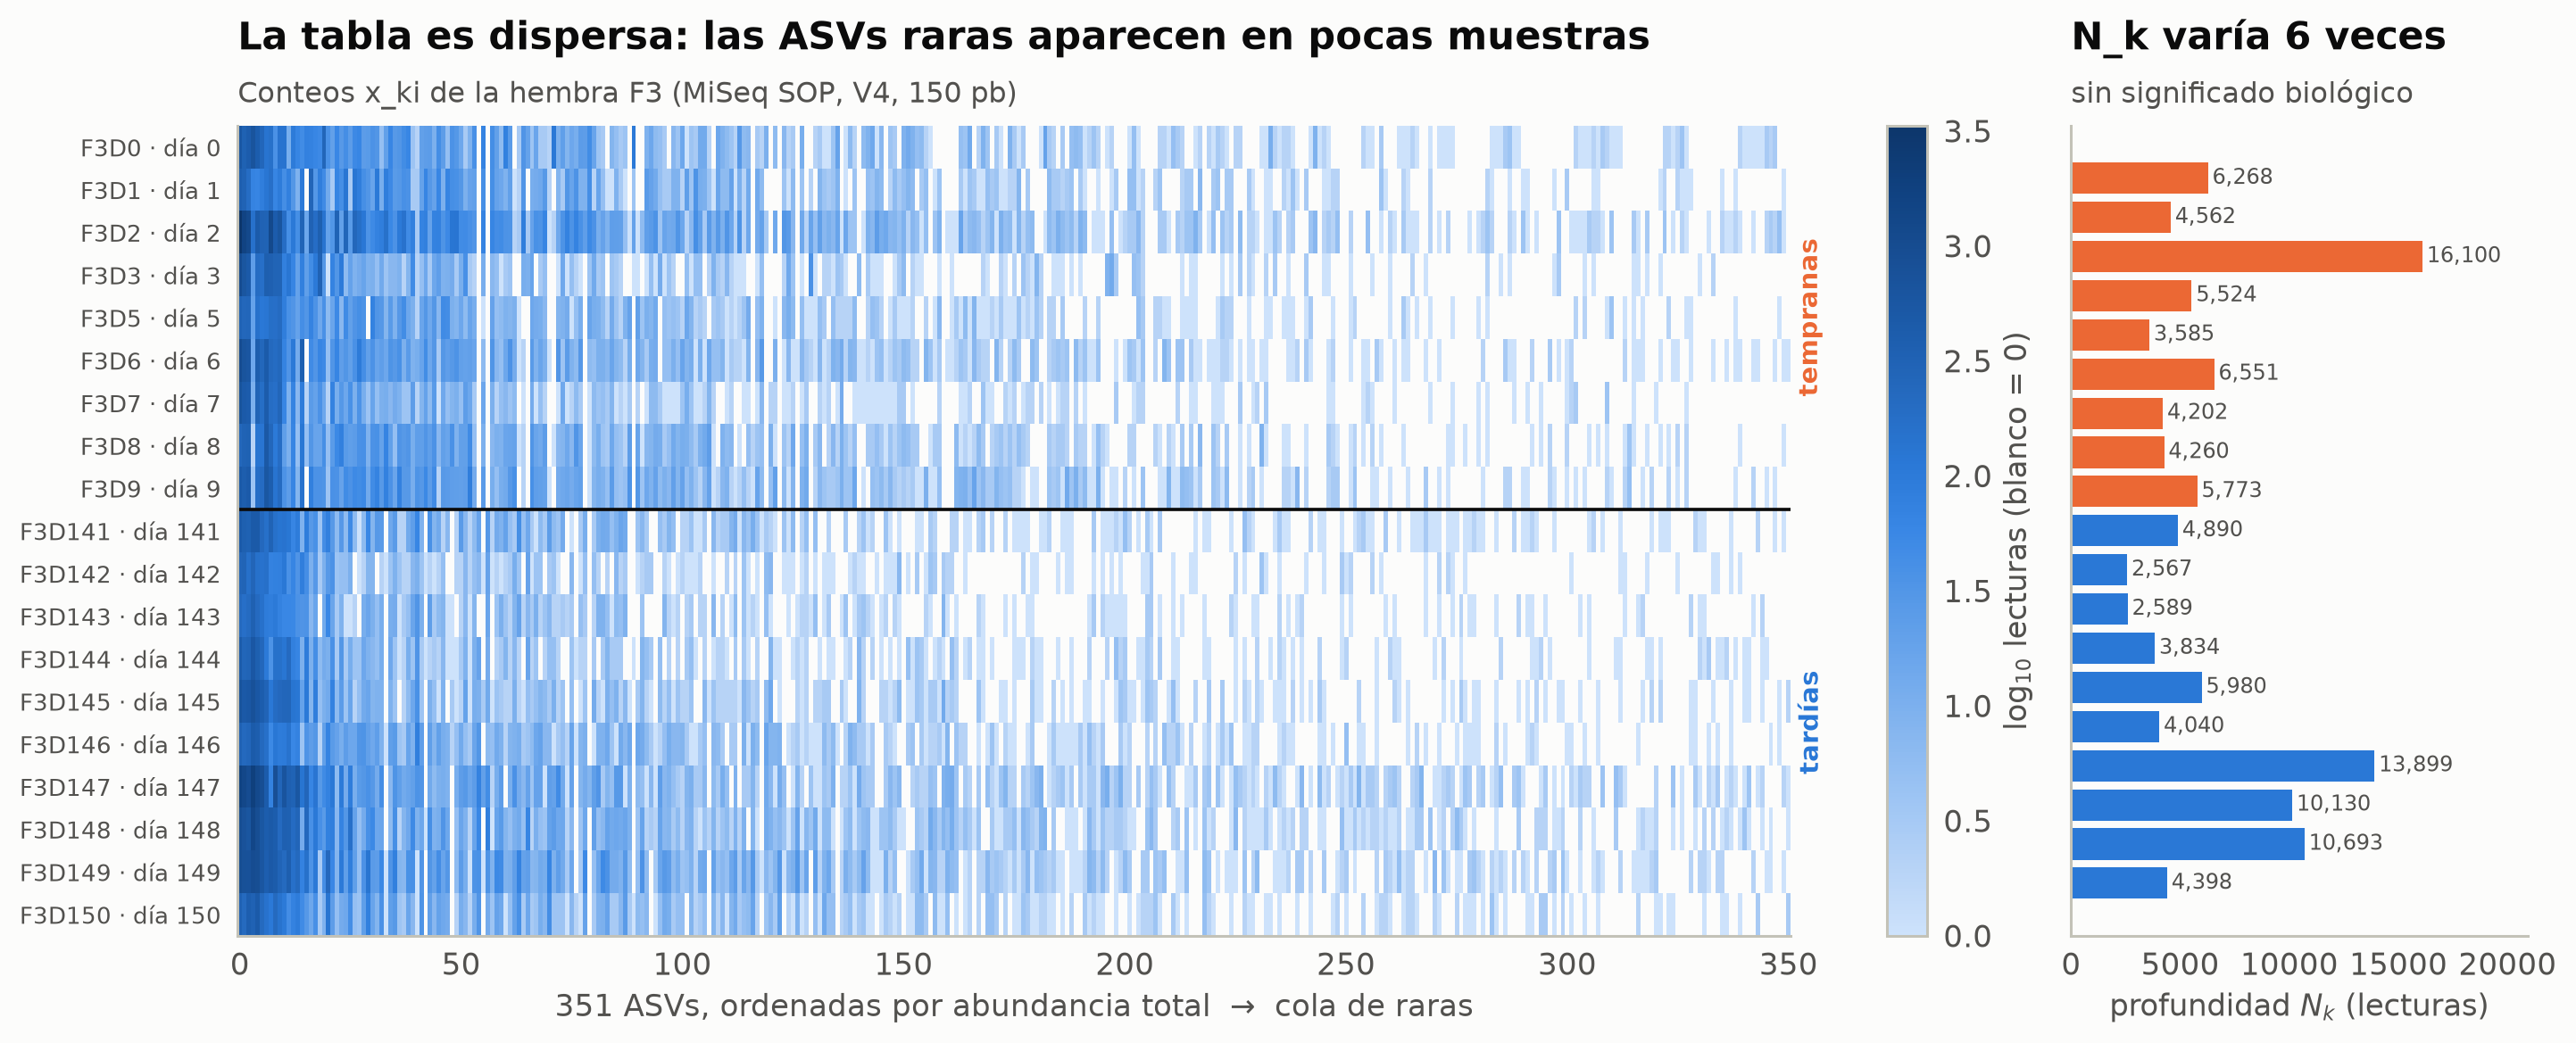

In [3]:
order = np.argsort(-X_real.sum(axis=0))
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5.2), gridspec_kw=dict(width_ratios=[3.4, 1]))
Z = np.log10(np.where(X_real[:, order] > 0, X_real[:, order], np.nan))
im = ax1.imshow(Z, aspect="auto", cmap=ec.CMAP_SEQ, interpolation="nearest"); ax1.grid(False)
ax1.set_yticks(range(len(samples)), [f"{s} · día {d}" for s, d in zip(samples, meta.day_post_weaning)], fontsize=8.5)
ax1.set_xlabel("351 ASVs, ordenadas por abundancia total  →  cola de raras")
ax1.axhline(8.5, color=ec.INK, lw=1.2)
ax1.text(352, 4, "tempranas", rotation=90, va="center", ha="left", fontsize=9.5, color=ec.ORANGE, fontweight="bold")
ax1.text(352, 13.5, "tardías", rotation=90, va="center", ha="left", fontsize=9.5, color=ec.BLUE, fontweight="bold")
cb = fig.colorbar(im, ax=ax1, fraction=0.03, pad=0.04); cb.set_label("log$_{10}$ lecturas (blanco = 0)")
ec.title(ax1, "La tabla es dispersa: las ASVs raras aparecen en pocas muestras",
         "Conteos x_ki de la hembra F3 (MiSeq SOP, V4, 150 pb)")
ax2.barh(range(len(samples)), N_k, color=[PERIOD_COLORS[p] for p in period])
ax2.invert_yaxis(); ax2.set_yticks([])
ax2.set_xlabel("profundidad $N_k$ (lecturas)")
for k, n in enumerate(N_k):
    ax2.text(n + 200, k, f"{n:,}", va="center", fontsize=8, color=ec.INK_2)
ax2.set_xlim(0, N_k.max() * 1.3)
ec.title(ax2, "N_k varía 6 veces", "sin significado biológico")
plt.show()

> 🔎 **Qué observamos.** Las primeras decenas de columnas son oscuras en todas las filas: los taxones dominantes están
> en todas partes. Hacia la derecha la tabla se llena de blanco: las ASVs raras aparecen sólo en algunas muestras, y
> a veces sólo en las más profundas. Esa dependencia de la profundidad es el hilo que recorrerá media lección.

Siguiendo la tradición ecológica distinguimos dos escalas:

* la **diversidad alfa** describe **una** muestra: cuántos taxones contiene y cuán equitativamente se reparten;
* la **diversidad beta** describe la **diferencia entre muestras**: cuánto cambia la composición de una a otra.

## 2. Riqueza, Shannon y Simpson

### 2.1 Dos bosques con veinte especies

El libro abre la sección con dos bosques de veinte especies de árboles. En el primero cada especie aporta la misma
cantidad de ejemplares: caminar por él es encontrarse a cada paso con algo distinto. En el segundo, un único pino
representa el 95 % de los árboles y las otras diecinueve especies aparecen, con suerte, una vez por hectárea.
**Contar especies** dice que son igual de diversos; la experiencia de cualquier caminante dice que no. Necesitamos
índices que tengan en cuenta **cuánto** hay de cada cosa.

Hay tres preguntas naturales, y cada una da un índice:

1. ¿**Cuántos** taxones distintos hay? → la riqueza $S$.
2. Si saco una lectura al azar, ¿**cuán sorprendido** estaré de su identidad? → la entropía de Shannon $H$.
3. Si saco **dos** lecturas al azar, ¿qué probabilidad hay de que sean **del mismo** taxón? → el índice de Simpson $D$.

### 2.2 Las definiciones

Para una muestra con abundancias relativas $p_1,\dots,p_S$ (todas positivas):

$$
S = \#\{i : p_i > 0\}, \qquad
H = -\sum_{i=1}^{S} p_i \ln p_i, \qquad
D = \sum_{i=1}^{S} p_i^2 .
$$

| Símbolo | Significado |
|---|---|
| $S$ | Riqueza: número de taxones observados en la muestra. |
| $p_i$ | Abundancia relativa del taxón $i$ (fracción de las lecturas de la muestra). |
| $H$ | Entropía de Shannon, en *nats* si se usa $\ln$; mide la incertidumbre sobre el taxón de una lectura elegida al azar. |
| $D$ | Probabilidad de que dos lecturas elegidas al azar (con reposición) pertenezcan al mismo taxón. |
| $1-D$ | Índice de Gini-Simpson: probabilidad de que dos lecturas sean de taxones **distintos**. |
| $1/D$ | Simpson inverso. |
| $J=H/\ln S$ | Equidad de Pielou: la entropía dividida por su máximo posible. |

Cada índice responde una pregunta distinta. $S$ ignora las abundancias: da el mismo peso a un taxón con una lectura
que a uno con un millón. $H$ es **máxima**, $\ln S$, cuando todos los taxones son igual de abundantes, y vale cero
cuando uno solo acapara la muestra. $D$ está dominado por los taxones abundantes, porque eleva las proporciones al
cuadrado: un taxón con $p=0{,}01$ aporta $0{,}0001$, casi nada.

> 🤔 **Antes de ejecutar, prediga.** El libro propone una muestra de $N=100$ lecturas con conteos
> $(50, 20, 10, 10, 5, 2, 1, 1, 1)$. ¿Cuál será mayor: $1-D$ o $J$? ¿Y cuántos «taxones efectivos» cree que hay: más
> cerca de 2, de 4 o de 9?

### 2.3 Una comunidad de nueve taxones (ejemplo del libro)

A mano, término a término:

$$
\begin{aligned}
H &= -\bigl(0{,}5\ln 0{,}5 + 0{,}2\ln 0{,}2 + 2\times0{,}1\ln 0{,}1 + 0{,}05\ln 0{,}05 + 0{,}02\ln 0{,}02 + 3\times 0{,}01\ln 0{,}01\bigr)\\
  &= 0{,}3466 + 0{,}3219 + 0{,}4605 + 0{,}1498 + 0{,}0782 + 0{,}1382 = 1{,}495,\\[4pt]
D &= 0{,}25 + 0{,}04 + 0{,}02 + 0{,}0025 + 0{,}0004 + 0{,}0003 = 0{,}3132 .
\end{aligned}
$$

In [4]:
toy = np.array([50, 20, 10, 10, 5, 2, 1, 1, 1])     # ejemplo del libro «Una comunidad de nueve taxones»
p = toy / toy.sum()
S = (toy > 0).sum()
H = -(p * np.log(p)).sum()
D = (p ** 2).sum()
J = H / np.log(S)
print("Aportes a H, -p ln p :", np.round(-p * np.log(p), 4))
print("Aportes a D, p²      :", np.round(p ** 2, 4))
print(f"S = {S}   H = {H:.4f} nats   D = {D:.4f}   1 − D = {1 - D:.4f}   1/D = {1 / D:.3f}   J = {J:.3f}   e^H = {np.exp(H):.3f}")

Aportes a H, -p ln p : [0.3466 0.3219 0.2303 0.2303 0.1498 0.0782 0.0461 0.0461 0.0461]
Aportes a D, p²      : [2.5e-01 4.0e-02 1.0e-02 1.0e-02 2.5e-03 4.0e-04 1.0e-04 1.0e-04 1.0e-04]
S = 9   H = 1.4952 nats   D = 0.3132   1 − D = 0.6868   1/D = 3.193   J = 0.680   e^H = 4.460


Las mismas cifras que el libro: $H=1{,}495$, $D=0{,}3132$, $1-D=0{,}687$, $1/D=3{,}19$ y $J=0{,}680$. Fíjese en los
aportes: a $H$ contribuyen bastante los taxones intermedios y hasta los raros (los tres *singletons* suman 0,138), pero
a $D$ los tres raros aportan sólo 0,0003: **$D$ es ciego a los raros**.

Observe también que los tres índices viven en escalas **incomparables**: una entropía de 1,5 nats, una probabilidad
de 0,69 y una «cantidad» de 3,2. En la sección 5 veremos cómo ponerlos en la misma escala. La figura resume el
ejemplo.

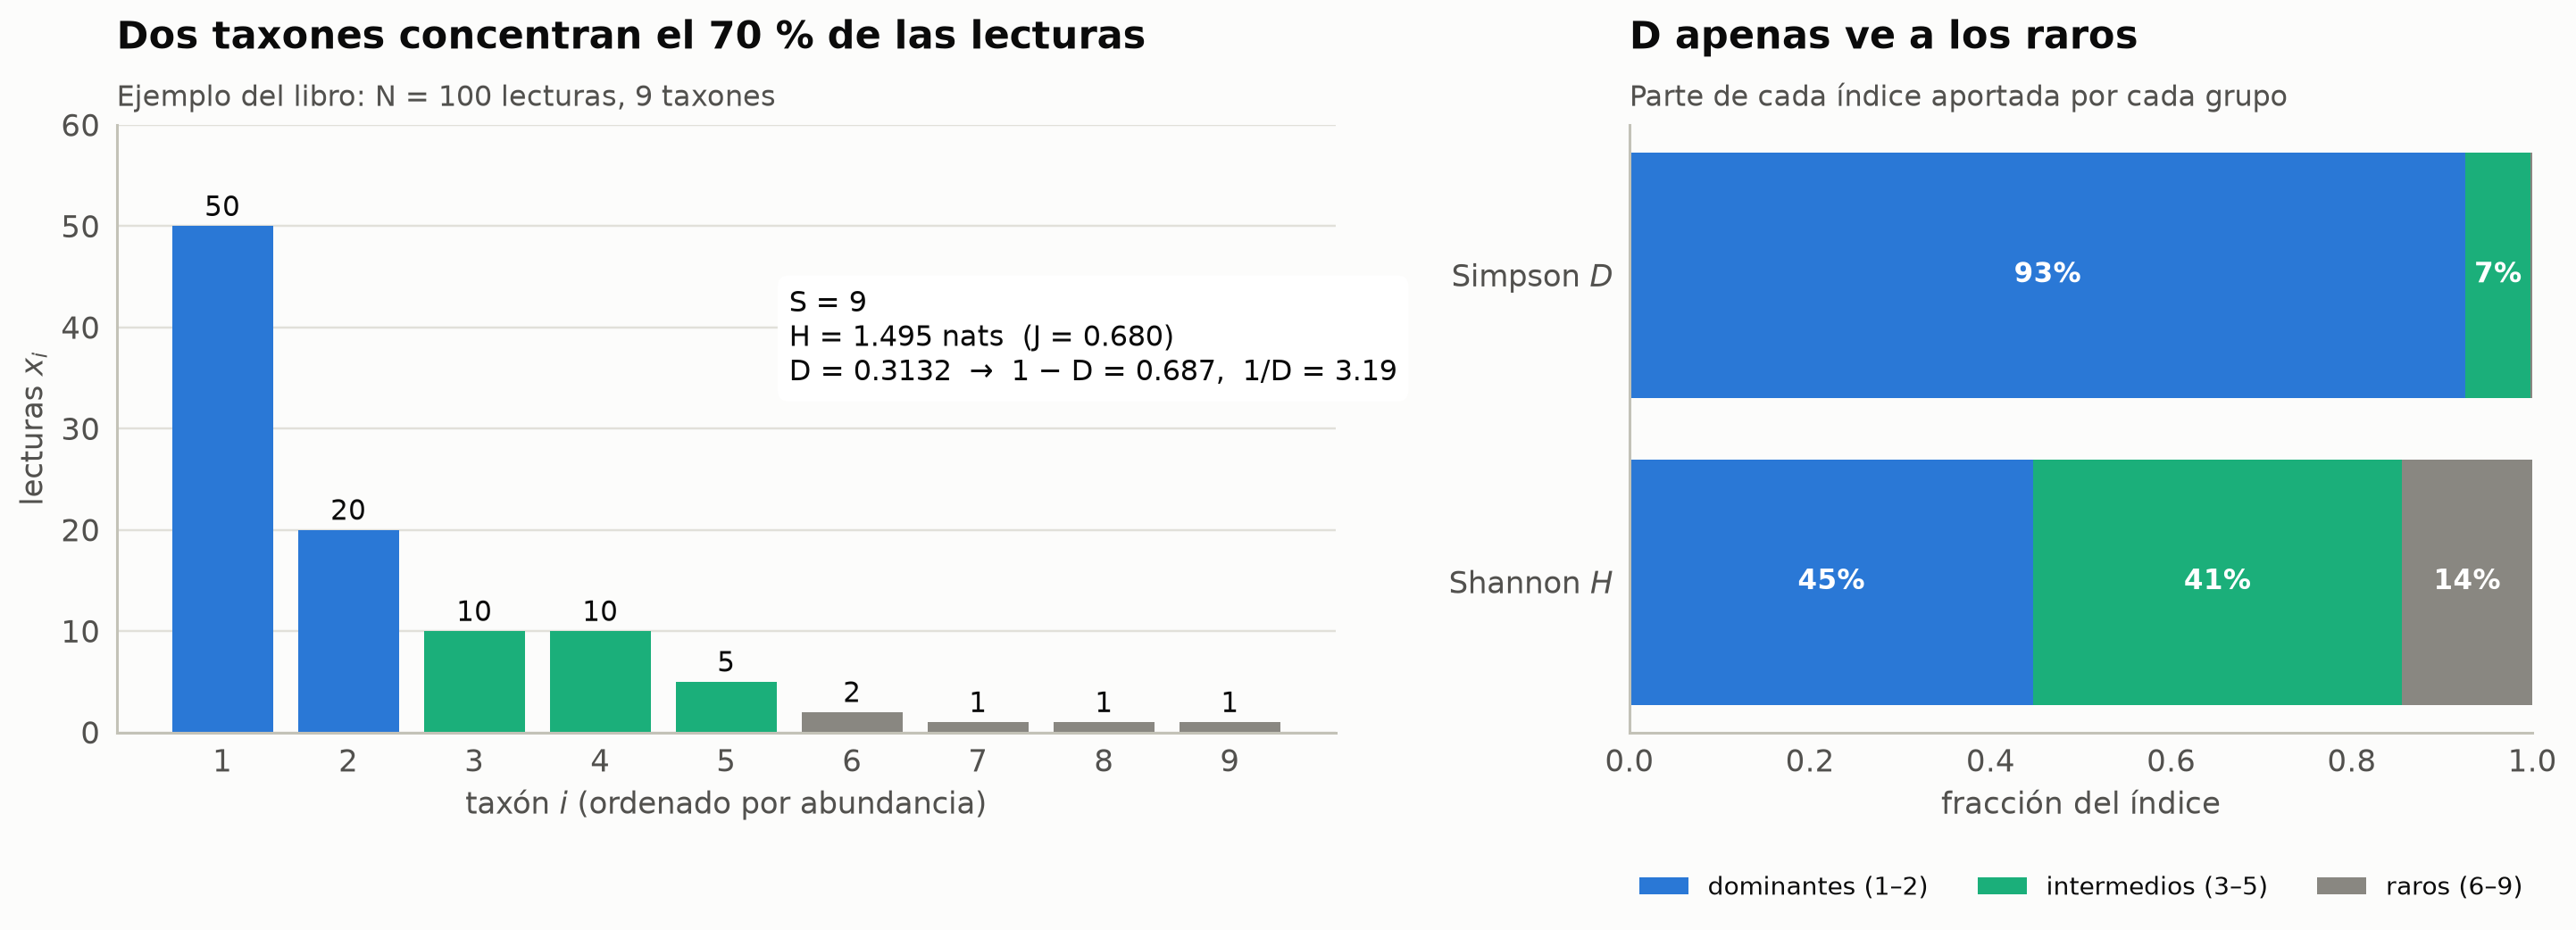

In [5]:
fig, (ax, axb) = plt.subplots(1, 2, figsize=(13, 4.6), gridspec_kw=dict(width_ratios=[1.35, 1]))
cols = [ec.BLUE] * 2 + [ec.AQUA] * 3 + [ec.MUTED] * 4
ax.bar(range(1, 10), toy, color=cols)
for i, v in enumerate(toy):
    ax.text(i + 1, v + 1, str(v), ha="center", fontsize=10, color=ec.INK)
ax.set_xticks(range(1, 10)); ax.set_xlabel("taxón $i$ (ordenado por abundancia)"); ax.set_ylabel("lecturas $x_i$")
ax.set_ylim(0, 60)
ax.text(5.5, 44, f"S = {S}\nH = {H:.3f} nats  (J = {J:.3f})\nD = {D:.4f}  →  1 − D = {1 - D:.3f},  1/D = {1 / D:.2f}",
        fontsize=10.5, va="top", color=ec.INK, bbox=dict(boxstyle="round,pad=0.4", fc="white", ec=ec.GRID))
ec.title(ax, "Dos taxones concentran el 70 % de las lecturas", "Ejemplo del libro: N = 100 lecturas, 9 taxones")
contrib = pd.DataFrame({"H": -p * np.log(p) / H, "D": p ** 2 / D}, index=range(1, 10))
groups = {"dominantes (1–2)": [1, 2], "intermedios (3–5)": [3, 4, 5], "raros (6–9)": [6, 7, 8, 9]}
left = np.zeros(2)
for (g, idx), c in zip(groups.items(), [ec.BLUE, ec.AQUA, ec.MUTED]):
    val = contrib.loc[idx].sum().values
    axb.barh([0, 1], val, left=left, color=c, label=g)
    for j in range(2):
        if val[j] > 0.04:
            axb.text(left[j] + val[j] / 2, j, f"{val[j]:.0%}", ha="center", va="center", color="white", fontsize=10,
                     fontweight="bold")
    left += val
axb.set_yticks([0, 1], ["Shannon $H$", "Simpson $D$"]); axb.set_xlim(0, 1); axb.set_xlabel("fracción del índice")
axb.legend(loc="upper center", bbox_to_anchor=(0.5, -0.2), ncol=3, frameon=False, fontsize=9)
ec.title(axb, "D apenas ve a los raros", "Parte de cada índice aportada por cada grupo")
plt.show()

> 🔎 **Qué observamos.** Los taxones 6–9 (con 1–2 lecturas) aportan el 14 % de la entropía de Shannon pero sólo el
> 0,2 % del índice de Simpson. Si un error de secuenciación inventa un taxón raro, $H$ lo nota un poco y $D$
> prácticamente nada; $S$, en cambio, lo cuenta como un taxón entero. Por eso **los índices sensibles a los raros son
> frágiles en datos de amplicones**.

> ✅ **Compruebe su comprensión.** ¿Qué valen $H$, $D$ y $J$ en una muestra con cuatro taxones de 25 lecturas cada
> uno? *(Todos $p_i=0{,}25$: $H=\ln 4=1{,}386$, $D=4\times0{,}0625=0{,}25$, $1/D=4$, $J=1$: equidad perfecta.)*

### 2.4 Los índices en el intestino del ratón

Escribimos funciones reutilizables y las aplicamos a las 19 muestras reales.

In [6]:
def alpha_indices(x):
    """Riqueza, Shannon, Simpson, Gini-Simpson, Simpson inverso y Pielou de un vector de conteos."""
    x = np.asarray(x, dtype=float)
    x = x[x > 0]
    p = x / x.sum()
    S = len(x); H = -(p * np.log(p)).sum(); D = (p ** 2).sum()
    return dict(S=S, H=H, D=D, gini_simpson=1 - D, inv_simpson=1 / D, J=H / np.log(S) if S > 1 else np.nan)

alpha = pd.DataFrame([alpha_indices(x) for x in X_real], index=samples)
alpha["period"] = period; alpha["day"] = meta.day_post_weaning.values; alpha["N_k"] = N_k
print(alpha.groupby("period")[["S", "H", "inv_simpson", "J", "N_k"]].mean().round(2).rename(index=PERIOD_NAMES))
print("\nCorrelación de Spearman entre la riqueza observada S y la profundidad N_k:",
      f"{pd.Series(alpha.S).corr(pd.Series(alpha.N_k), method='spearman'):.2f}")

                            S     H  inv_simpson     J      N_k
period                                                         
temprano (días 0–9)    221.89  3.82        22.78  0.71  6313.89
tardío (días 141–150)  223.60  3.57        18.78  0.66  6302.00



Correlación de Spearman entre la riqueza observada S y la profundidad N_k: 0.85


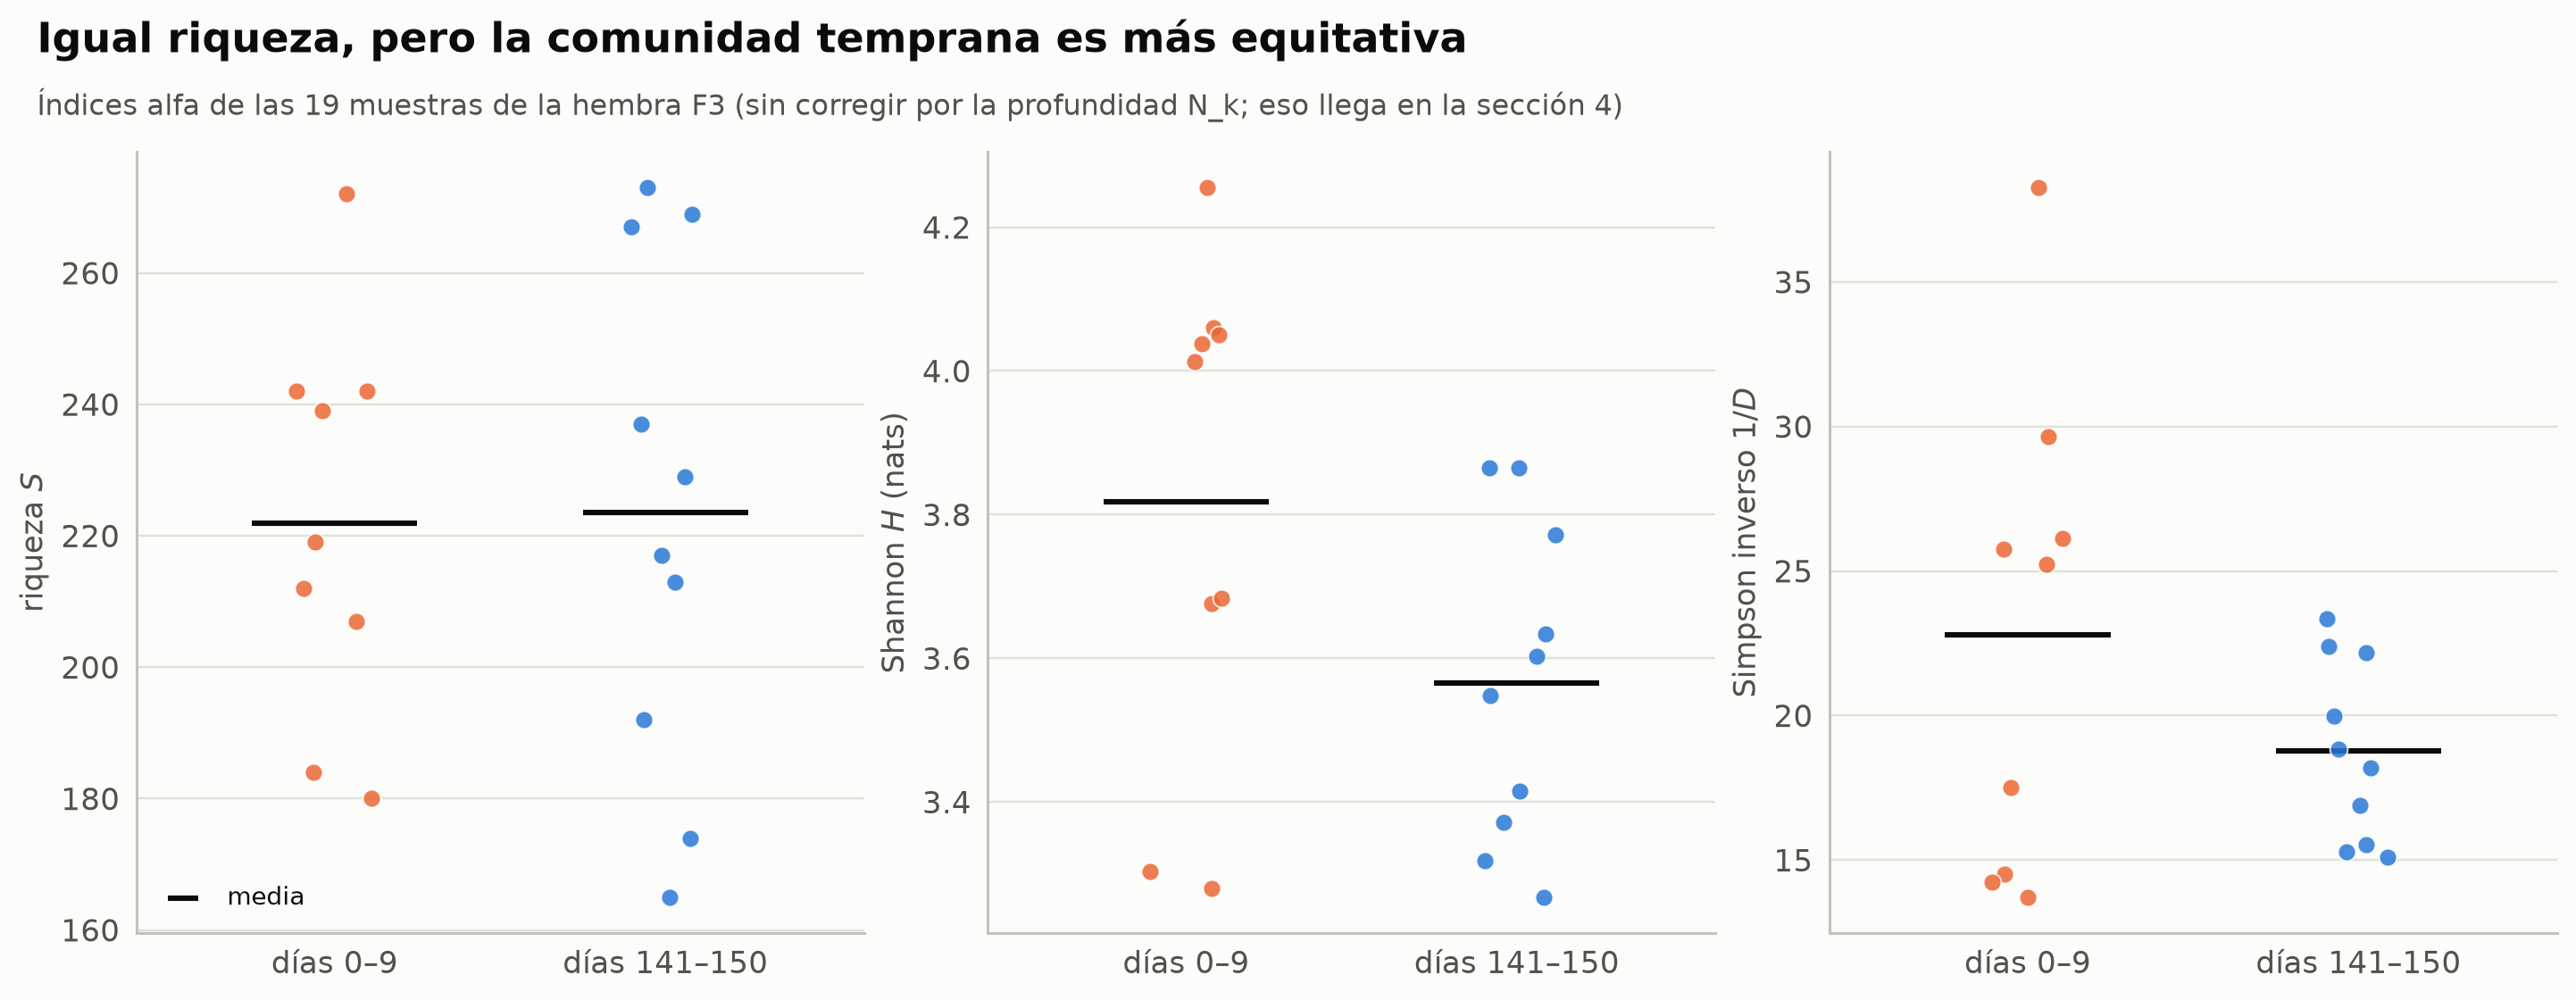

In [7]:
fig, axs = plt.subplots(1, 3, figsize=(13, 4.3))
for ax, col, lab in zip(axs, ["S", "H", "inv_simpson"], ["riqueza $S$", "Shannon $H$ (nats)", "Simpson inverso $1/D$"]):
    for j, per in enumerate(["early", "late"]):
        v = alpha.loc[alpha.period == per, col].values
        xj = j + rng_nb.uniform(-0.12, 0.12, len(v))
        ax.scatter(xj, v, s=42, color=PERIOD_COLORS[per], alpha=0.85, edgecolor="white", lw=0.6, zorder=3)
        ax.hlines(v.mean(), j - 0.25, j + 0.25, color=ec.INK, lw=2)
    ax.set_xticks([0, 1], ["días 0–9", "días 141–150"]); ax.set_xlim(-0.6, 1.6); ax.set_ylabel(lab)
axs[0].scatter([], [], color=ec.INK, marker="_", s=120, label="media")
axs[0].legend(frameon=False, loc="lower left", fontsize=9)
ec.fig_title(fig, "Igual riqueza, pero la comunidad temprana es más equitativa",
             "Índices alfa de las 19 muestras de la hembra F3 (sin corregir por la profundidad N_k; eso llega en la sección 4)")
plt.show()

> 🔎 **Qué observamos.** Los dos períodos tienen, en promedio, casi la misma riqueza observada (unas 220 ASVs), pero
> las muestras tempranas tienen más entropía y más Simpson inverso: sus lecturas se reparten de forma más equitativa
> entre muchos taxones, mientras que en la comunidad adulta unos pocos taxones dominan. La variabilidad de un día a
> otro es grande en el período temprano: la comunidad todavía se está reorganizando. Pero cuidado con la riqueza: la correlación con la profundidad nos avisa de que una parte de $S$ es
> simplemente «haber secuenciado más». Las dos secciones siguientes tratan justamente de eso.

## 3. Lo que no vimos: el estimador Chao1

### 3.1 Estimar lo que no se ha visto

La riqueza observada depende de la profundidad: con más lecturas aparecen más taxones raros. Lo que realmente
interesa es la riqueza **de la comunidad**,

$$
S_{\text{real}} = S_{\text{obs}} + f_0,
$$

donde $f_0$ es el número de taxones presentes pero **no observados**. Parece imposible estimar lo que no se ha visto,
pero piense en un ornitólogo que anilla aves en un bosque durante una semana. Si casi todas las especies que anotó
las vio muchas veces, probablemente ya conoce casi todas; si muchas especies aparecieron **una sola vez**, es señal de
que el bosque esconde más especies «tímidas» que todavía no han caído en la red. Los taxones vistos una o dos veces
contienen información sobre los vistos **cero** veces. Esta es la intuición del estimador de Chao (1987), desarrollado
para estimar tamaños de poblaciones animales por captura y recaptura.

Llamemos $f_k$ al número de taxones observados **exactamente** $k$ veces: $f_1$ son los *singletons* y $f_2$ los
*doubletons*. En el ejemplo de los nueve taxones, $(50,20,10,10,5,2,1,1,1)$, tenemos $f_1=3$ y $f_2=1$.

### 3.2 El modelo de Poisson

Supongamos que el número de lecturas del taxón $i$ sigue una distribución de Poisson de media $\lambda_i$, que
depende de su abundancia (y de la profundidad). Entonces el número esperado de taxones vistos exactamente $k$ veces
es (ecuación 14-fk del libro)

$$
\mathbb E[f_k] = \sum_{i=1}^{S_{\text{real}}} \frac{\lambda_i^k\, e^{-\lambda_i}}{k!}, \qquad k = 0, 1, 2, \dots
$$

| Símbolo | Significado |
|---|---|
| $f_k$ | Número de taxones con exactamente $k$ lecturas en la muestra ($f_0$: no observados). |
| $\lambda_i$ | Número esperado de lecturas del taxón $i$ con la profundidad dada. |
| $S_{\text{real}}$ | Número total de taxones de la comunidad, observados o no. |

### 3.3 La cota de Chao y su demostración

> **Teorema (cota inferior de Chao).** Bajo este modelo, $\mathbb E[f_0] \ge \mathbb E[f_1]^2 / \bigl(2\,\mathbb E[f_2]\bigr)$.
> En consecuencia, el estimador
> $$\hat{S}_{\text{Chao1}} = S_{\text{obs}} + \frac{f_1^2}{2 f_2}$$
> estima una **cota inferior** de la riqueza real. Cuando $f_2 = 0$ se usa la forma **corregida por sesgo**
> $S_{\text{obs}} + f_1(f_1-1)/\bigl(2(f_2+1)\bigr)$.

*Demostración.* Escribamos $a_i = e^{-\lambda_i/2}$ y $b_i = \lambda_i e^{-\lambda_i/2}$. Entonces
$a_i b_i=\lambda_i e^{-\lambda_i}$, $a_i^2=e^{-\lambda_i}$ y $b_i^2=\lambda_i^2e^{-\lambda_i}$. Por la desigualdad de
Cauchy-Schwarz, $\bigl(\sum_i a_ib_i\bigr)^2\le\bigl(\sum_i a_i^2\bigr)\bigl(\sum_i b_i^2\bigr)$:

$$
\mathbb E[f_1]^2 = \Bigl(\sum_i \lambda_i e^{-\lambda_i}\Bigr)^2 \le \Bigl(\sum_i e^{-\lambda_i}\Bigr)\Bigl(\sum_i \lambda_i^2e^{-\lambda_i}\Bigr) = \mathbb E[f_0]\cdot 2\,\mathbb E[f_2],
$$

y basta despejar. La igualdad de Cauchy-Schwarz se alcanza cuando los vectores $a$ y $b$ son proporcionales, es decir,
cuando **todos los $\lambda_i$ son iguales**; cuanto más heterogéneas sean las abundancias de los taxones raros, más
holgada es la cota. $\square$

La demostración explica también el uso correcto del estimador. Chao1 no «adivina» la riqueza: dice que, **como
mínimo**, faltan unos $f_1^2/(2f_2)$ taxones. Si muchos taxones aparecen una sola vez y pocos dos veces, la muestra
está lejos de estar completa; si casi no hay *singletons*, la muestra está saturada.

Comprobemos numéricamente el teorema con valores esperados exactos: primero con todos los $\lambda_i$ iguales
(debe dar igualdad) y luego con abundancias muy desiguales (la cota queda corta).

In [8]:
from scipy.special import factorial

def expected_fk(lam, k):
    """E[f_k] = Σ_i λ_i^k e^{-λ_i} / k!  (ecuación 14-fk del libro)."""
    return (lam ** k * np.exp(-lam) / factorial(k)).sum()

cases = {"200 taxones, todos con λ = 1,5": np.full(200, 1.5),
         "200 taxones, λ log-normal (muy desiguales)": rng_nb.lognormal(0.0, 1.5, 200)}
for name, lam in cases.items():
    f0, f1, f2 = (expected_fk(lam, k) for k in (0, 1, 2))
    print(f"{name}:\n   E[f0] = {f0:6.2f} taxones no vistos   ·   E[f1]²/(2E[f2]) = {f1 ** 2 / (2 * f2):6.2f}"
          f"   → la cota recupera el {f1 ** 2 / (2 * f2) / f0:.0%} de los no vistos")

# Ejemplo del libro: f1 = 3, f2 = 1
x = toy
S_obs, f1, f2 = (x > 0).sum(), (x == 1).sum(), (x == 2).sum()
print(f"\nNueve taxones: S_obs = {S_obs}, f1 = {f1}, f2 = {f2}")
print(f"   Chao1 clásico          = {S_obs} + {f1}²/(2·{f2}) = {S_obs + f1 ** 2 / (2 * f2):.2f}")
print(f"   Chao1 corregido (sesgo) = {S_obs} + {f1}·{f1 - 1}/(2·{f2 + 1}) = {S_obs + f1 * (f1 - 1) / (2 * (f2 + 1)):.2f}")

200 taxones, todos con λ = 1,5:
   E[f0] =  44.63 taxones no vistos   ·   E[f1]²/(2E[f2]) =  44.63   → la cota recupera el 100% de los no vistos
200 taxones, λ log-normal (muy desiguales):
   E[f0] =  85.99 taxones no vistos   ·   E[f1]²/(2E[f2]) =  39.99   → la cota recupera el 47% de los no vistos

Nueve taxones: S_obs = 9, f1 = 3, f2 = 1
   Chao1 clásico          = 9 + 3²/(2·1) = 13.50
   Chao1 corregido (sesgo) = 9 + 3·2/(2·2) = 10.50


Con abundancias iguales la cota es exacta; con abundancias desiguales se queda muy por debajo del número real de
taxones no vistos. En el ejemplo del libro, $\hat S_{\text{Chao1}} = 9 + 9/2 = 13{,}5$: faltan **al menos** unos
4,5 taxones. La forma corregida por sesgo, que el libro reserva para $f_2=0$ pero que muchos programas usan siempre,
da 10,5 con los mismos datos. En la figura de rarefacción del libro (sección 4) se usa la forma corregida; lo diremos
cada vez para que usted pueda reproducir las cifras.

Una función que usaremos en adelante:

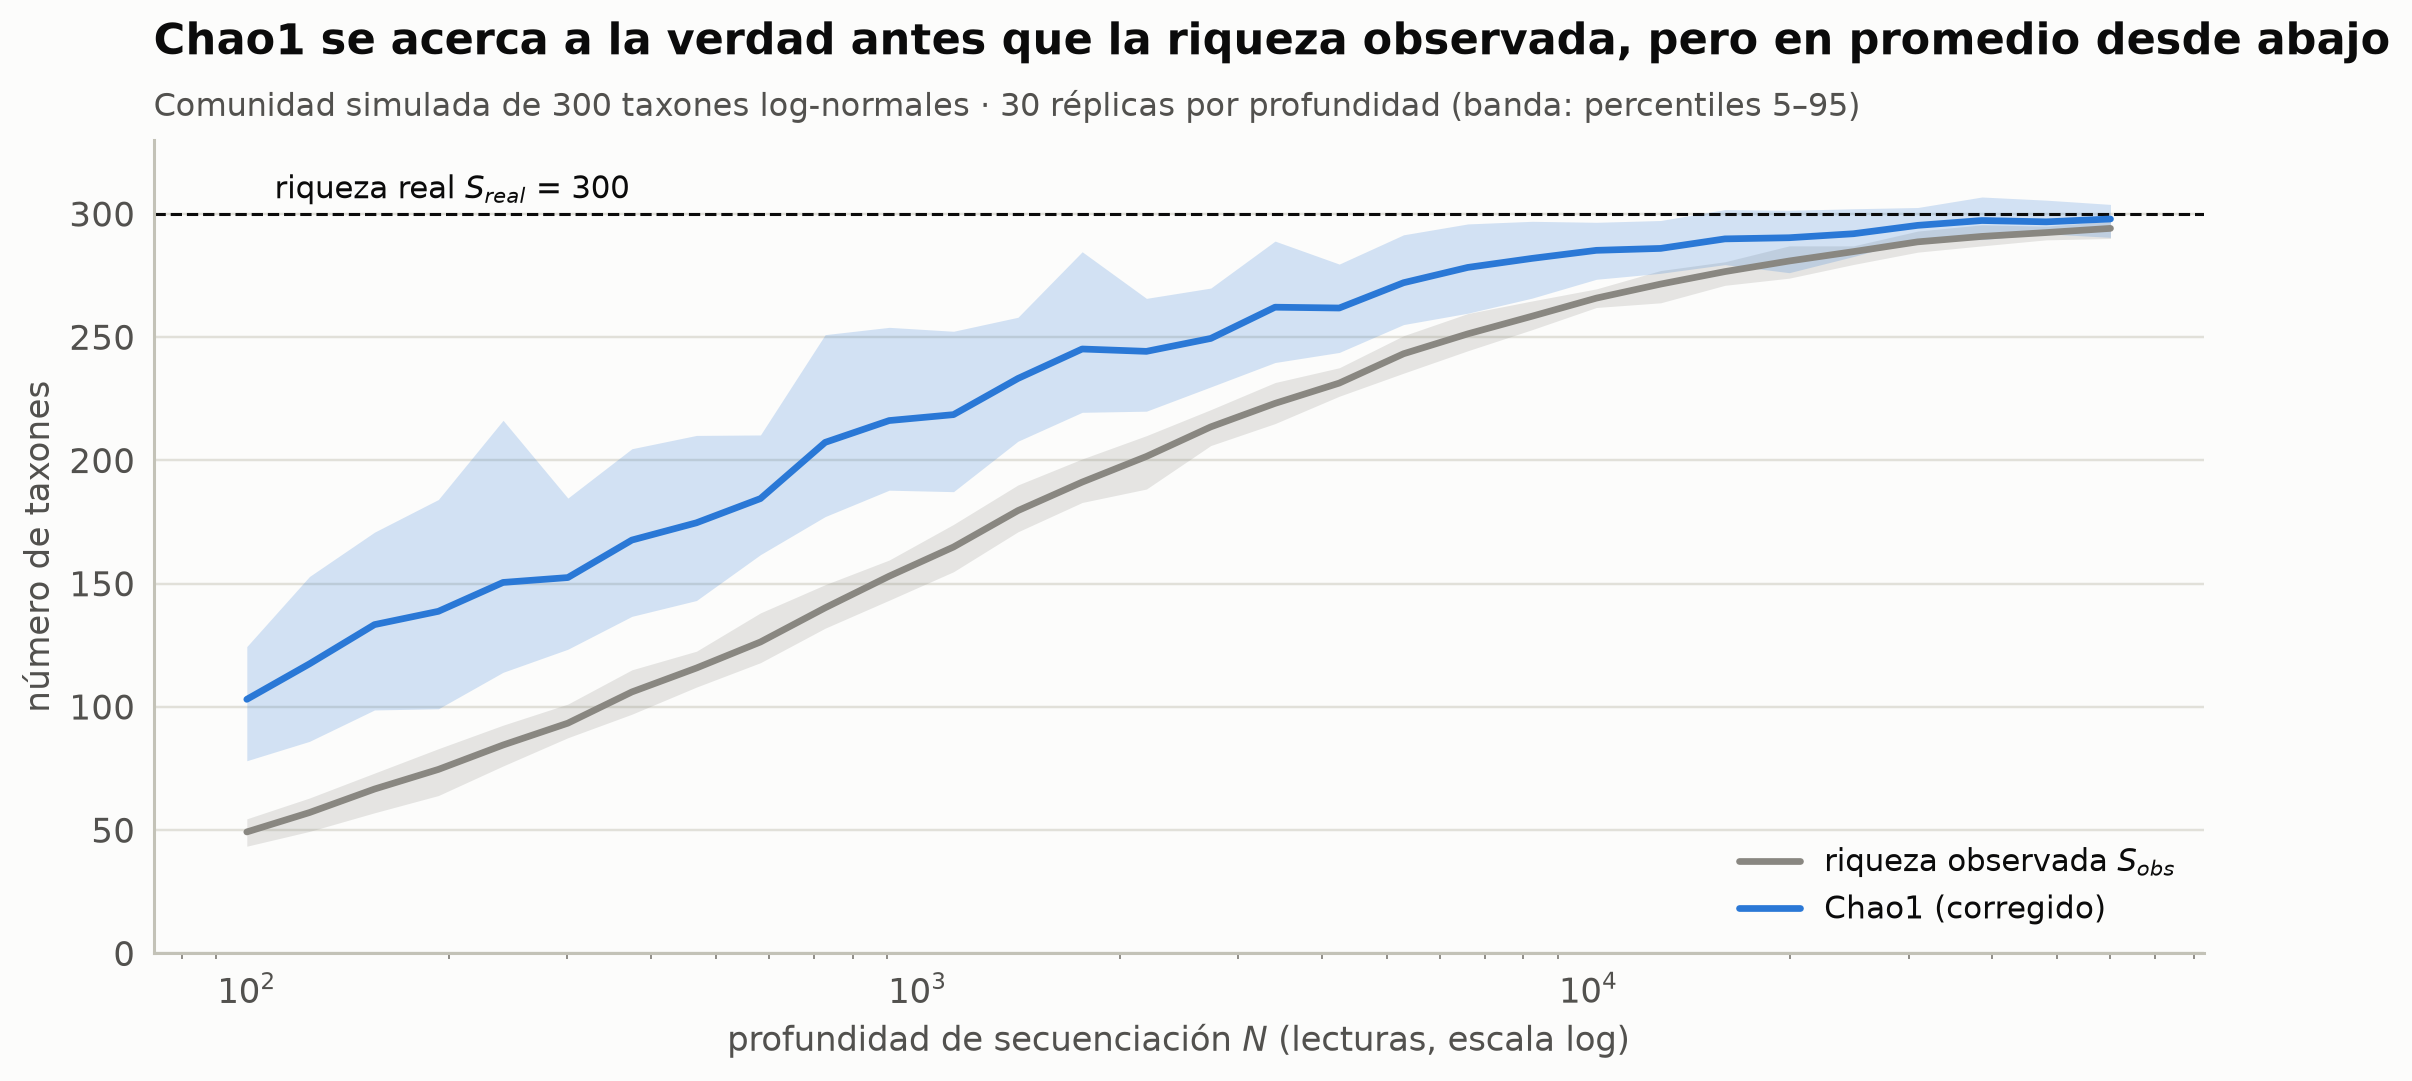

In [9]:
def chao1(x, bias_corrected=False):
    """Estimador Chao1 (clásico, o corregido por sesgo si bias_corrected o si f2 = 0)."""
    x = np.asarray(x); x = x[x > 0]
    S, f1, f2 = len(x), (x == 1).sum(), (x == 2).sum()
    if bias_corrected or f2 == 0:
        return S + f1 * (f1 - 1) / (2 * (f2 + 1))
    return S + f1 ** 2 / (2 * f2)

# ¿Cómo se comporta con la profundidad? Una comunidad de 300 taxones con abundancias log-normales
p_true = rng_nb.lognormal(0, 1.6, 300); p_true /= p_true.sum()
depths = np.unique(np.geomspace(100, 60000, 30).astype(int))
reps = 30
obs_curve, chao_curve = np.zeros((reps, len(depths))), np.zeros((reps, len(depths)))
for r in range(reps):
    for j, n in enumerate(depths):
        xs = rng_nb.multinomial(n, p_true)
        obs_curve[r, j] = (xs > 0).sum(); chao_curve[r, j] = chao1(xs, bias_corrected=True)

fig, ax = plt.subplots(figsize=(10, 4.8))
ax.axhline(300, color=ec.INK, lw=1, ls="--"); ax.text(110, 306, "riqueza real $S_{real}$ = 300", fontsize=10, color=ec.INK)
for arr, col, lab in ((obs_curve, ec.MUTED, "riqueza observada $S_{obs}$"), (chao_curve, ec.BLUE, "Chao1 (corregido)")):
    m, lo, hi = arr.mean(0), np.percentile(arr, 5, 0), np.percentile(arr, 95, 0)
    ax.fill_between(depths, lo, hi, color=col, alpha=0.2, lw=0)
    ax.plot(depths, m, color=col, lw=2.2, label=lab)
ax.set_xscale("log"); ax.set_xlabel("profundidad de secuenciación $N$ (lecturas, escala log)")
ax.set_ylabel("número de taxones"); ax.set_ylim(0, 330)
ax.legend(frameon=False, loc="lower right")
ec.title(ax, "Chao1 se acerca a la verdad antes que la riqueza observada, pero en promedio desde abajo",
         "Comunidad simulada de 300 taxones log-normales · 30 réplicas por profundidad (banda: percentiles 5–95)")
plt.show()

> 🔎 **Qué observamos.** A cualquier profundidad, Chao1 está en promedio por encima de la riqueza observada y por
> debajo de la real: estima una **cota inferior**, tal como garantiza el teorema (una réplica concreta puede pasarse
> un poco, porque $f_1$ y $f_2$ son aleatorios; el teorema habla de valores esperados). Con pocas lecturas su dispersión es enorme (depende
> de dos números pequeños, $f_1$ y $f_2$); con muchas lecturas ambas curvas convergen hacia 300.

### 3.4 ⚠️ Los *singletons* de un amplicón no son los de un censo

Chao1 descansa por completo en $f_1$ y $f_2$. Pero en un amplicón, la mayoría de las secuencias vistas una sola vez
**no son taxones raros, sino errores de secuenciación** (Lección 14.1). Con OTUs o secuencias sin depurar, los errores
inflan $f_1$ y con él la riqueza estimada. Con ASVs de DADA2 pasa lo contrario: DADA2 elimina por defecto las
secuencias vistas una sola vez, la tabla casi no tiene *singletons* y Chao1 coincide con la riqueza observada **por
construcción**, no porque la comunidad esté completa.

El MiSeq SOP incluye una muestra perfecta para verlo: una **comunidad artificial** (*mock*) del Human Microbiome
Project preparada mezclando ADN de **21 cepas bacterianas conocidas**. Sabemos la respuesta correcta. ¿Qué dice
Chao1 si contamos cada secuencia distinta como un taxón?

> 🤔 **Antes de ejecutar, prediga.** La muestra *mock* tiene unas 4 500 lecturas de buena calidad y 21 cepas. ¿Cuántas
> secuencias distintas de 150 pb cree que aparecerán? ¿Y cuánto dirá Chao1?

In [10]:
mock = pd.read_csv(course_file("142_mock_uniques.tsv"), sep="\t").fillna({"matched_organisms": ""})
m_raw = mock["count"].values
m_den = mock.loc[mock.kept_after_denoising == 1, "count"].values
organisms_all = sorted({o for s in mock.matched_organisms if s for o in s.split(",")})
organisms_den = sorted({o for s in mock.loc[mock.kept_after_denoising == 1, "matched_organisms"] if s for o in s.split(",")})
for name, x in (("secuencias únicas sin depurar", m_raw), ("variantes tras la regla de abundancia", m_den)):
    print(f"{name:<40}: lecturas = {x.sum():5d} · S_obs = {(x > 0).sum():4d} · f1 = {(x == 1).sum():4d} · "
          f"f2 = {(x == 2).sum():3d} · Chao1 = {chao1(x):7.1f}")
exact = mock.matched_organisms != ""
print(f"\nSecuencias idénticas a algún 16S de referencia de la mock: {exact.sum()} de {len(mock)} "
      f"({mock.loc[exact, 'count'].sum() / m_raw.sum():.0%} de las lecturas)")
print(f"Variantes depuradas que coinciden con la referencia: "
      f"{(mock.loc[mock.kept_after_denoising == 1, 'matched_organisms'] != '').sum()} de {len(m_den)}")
print(f"Cepas de la mock: 21 · detectadas por las variantes depuradas: {len(organisms_den)}")
print("Variantes depuradas y cepas a las que corresponden:")
print(mock.loc[mock.kept_after_denoising == 1, ["count", "matched_organisms"]].to_string(index=False))

secuencias únicas sin depurar           : lecturas =  4548 · S_obs =  637 · f1 =  533 · f2 =  60 · Chao1 =  3004.4
variantes tras la regla de abundancia   : lecturas =  3778 · S_obs =   20 · f1 =    0 · f2 =   0 · Chao1 =    20.0

Secuencias idénticas a algún 16S de referencia de la mock: 23 de 637 (84% de las lecturas)
Variantes depuradas que coinciden con la referencia: 20 de 20
Cepas de la mock: 21 · detectadas por las variantes depuradas: 20
Variantes depuradas y cepas a las que corresponden:
 count      matched_organisms
   521 S.aureus,S.epidermidis
   377            A.baumannii
   331               B.cereus
   302               H.pylori
   282        A.odontolyticus
   262         N.meningitidis
   243         C.beijerinckii
   192             B.vulgatus
   192               S.mutans
   168             E.faecalis
   155                 E.coli
   136        L.monocytogenes
   131           S.agalactiae
   126           P.aeruginosa
    90          D.radiodurans
    89           P

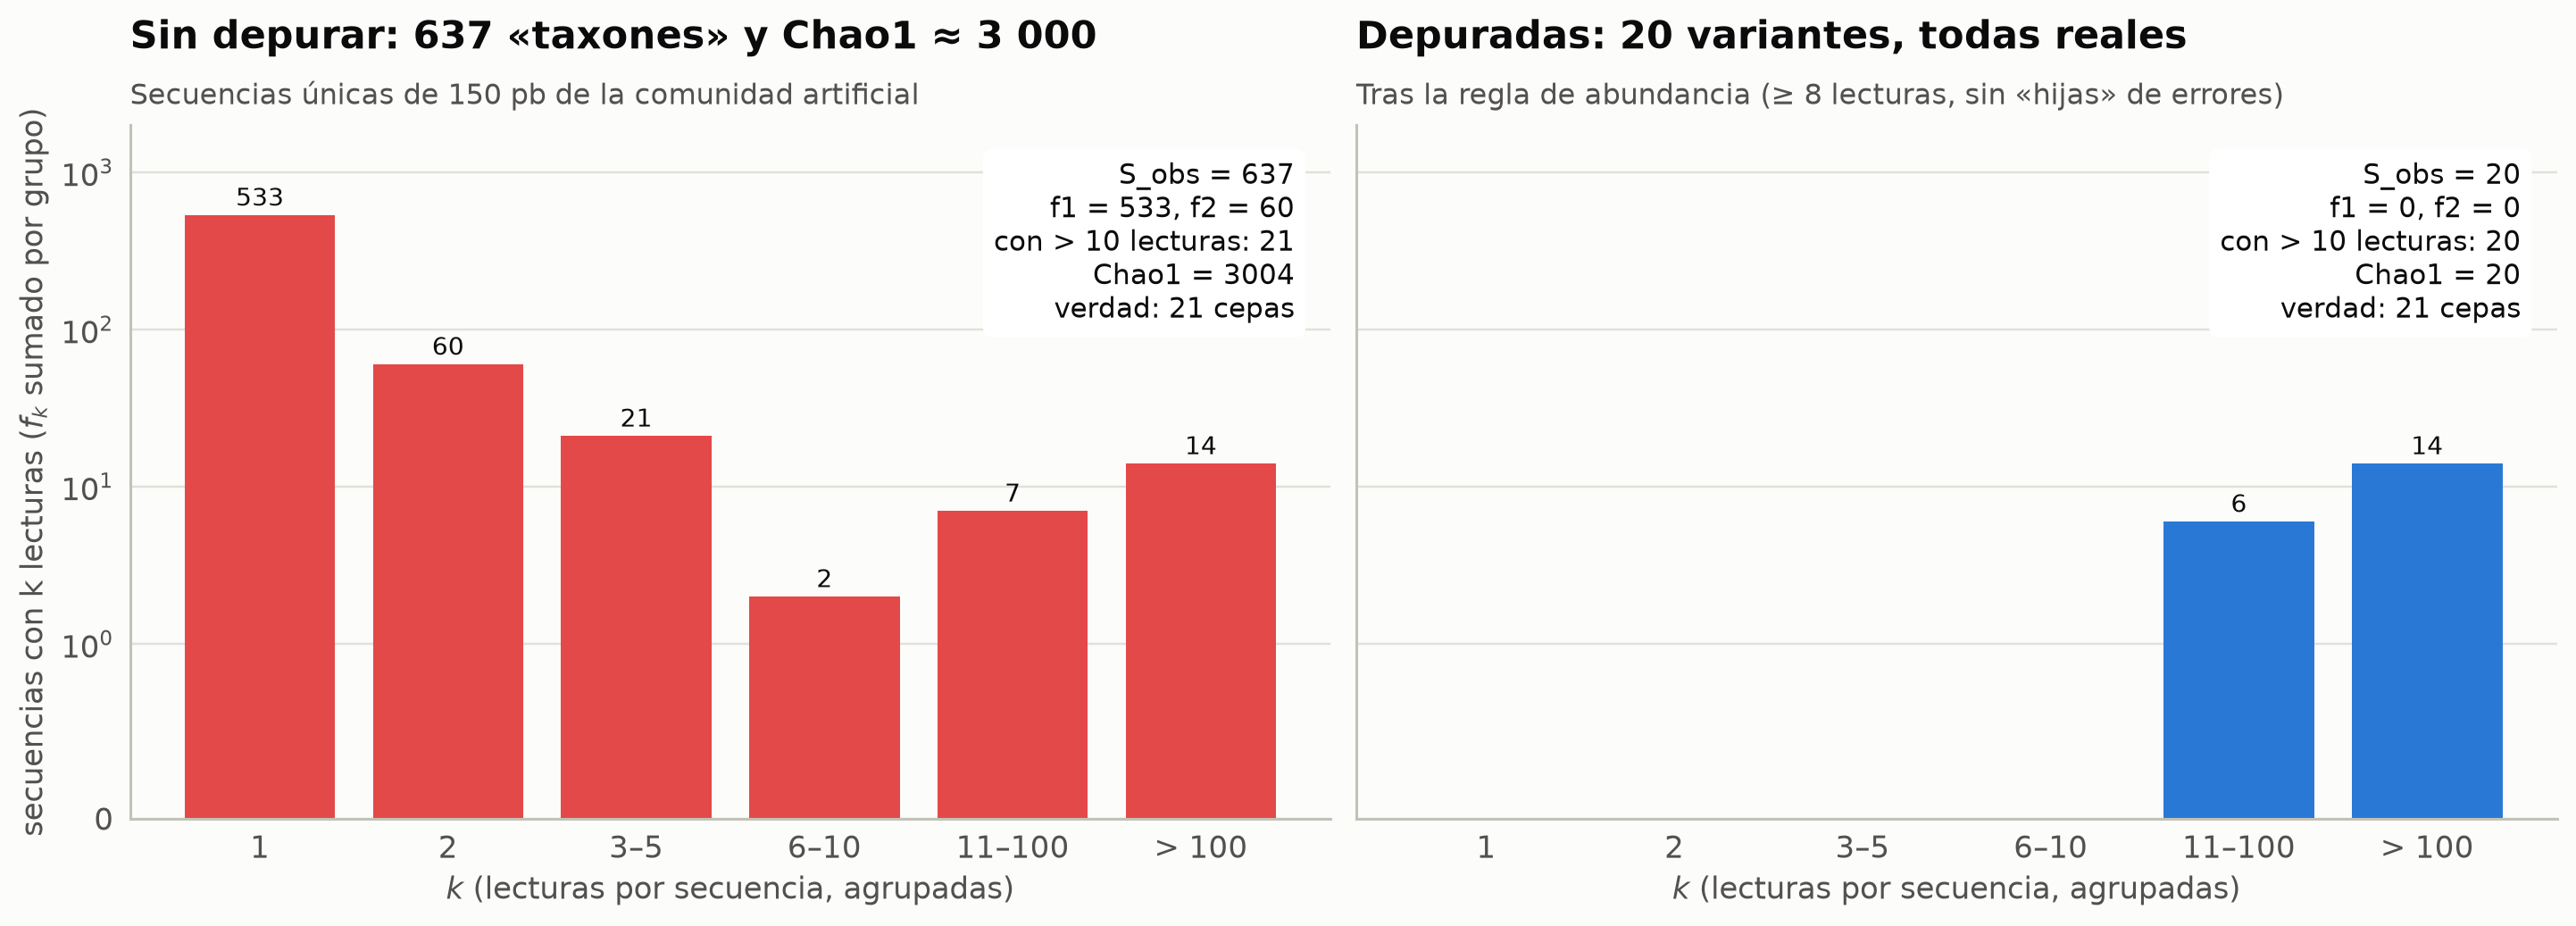

In [11]:
fig, axs = plt.subplots(1, 2, figsize=(13, 4.6), sharey=True)
for ax, x, col, tit, sub in (
        (axs[0], m_raw, ec.RED, "Sin depurar: 637 «taxones» y Chao1 ≈ 3 000",
         "Secuencias únicas de 150 pb de la comunidad artificial"),
        (axs[1], m_den, ec.BLUE, "Depuradas: 20 variantes, todas reales",
         "Tras la regla de abundancia (≥ 8 lecturas, sin «hijas» de errores)")):
    bins = [(1, 1), (2, 2), (3, 5), (6, 10), (11, 100), (101, 10 ** 6)]
    blab = ["1", "2", "3–5", "6–10", "11–100", "> 100"]
    fk = np.array([((x >= a) & (x <= b)).sum() for a, b in bins])
    k = np.arange(len(bins))
    ax.bar(k, fk, color=col)
    for kk, v in zip(k, fk):
        if v:
            ax.text(kk, v * 1.15, str(v), ha="center", fontsize=9)
    ax.set_yscale("symlog", linthresh=1); ax.set_ylim(0, 2000)
    ax.set_xticks(k, blab); ax.set_xlabel("$k$ (lecturas por secuencia, agrupadas)")
    ax.text(0.97, 0.95, f"S_obs = {(x > 0).sum()}\nf1 = {(x == 1).sum()}, f2 = {(x == 2).sum()}\n"
            f"con > 10 lecturas: {(x > 10).sum()}\nChao1 = {chao1(x):.0f}\nverdad: 21 cepas",
            transform=ax.transAxes, ha="right", va="top", fontsize=10,
            bbox=dict(boxstyle="round,pad=0.4", fc="white", ec=ec.GRID))
    ec.title(ax, tit, sub)
axs[0].set_ylabel("secuencias con k lecturas ($f_k$ sumado por grupo)")
plt.show()

> 🔎 **Qué observamos.** Sin depurar, una comunidad de 21 cepas produce **637** secuencias distintas, de las cuales
> 533 aparecen una sola vez: casi todas son copias de cepas reales con uno o dos errores de lectura. Chao1 las toma por
> taxones raros y estima unos **3 000** taxones, ¡140 veces la verdad! Tras la depuración quedan 20 variantes, las
> 20 idénticas a secuencias de referencia; cubren 20 de las 21 cepas (dos estafilococos comparten la misma V4 y una
> cepa, *B. vulgatus*, aporta dos variantes porque sus copias del operón ribosómico difieren; *P. acnes* no aparece).
> Pero ahora $f_1=f_2=0$ y Chao1 es igual a $S_{\text{obs}}$ **por construcción**. En ninguno de los dos casos Chao1
> informa de verdad sobre la riqueza. Moraleja del libro: *los estimadores de riqueza basados en singletons deben
> usarse con mucha cautela en datos de amplicones*.

> ✅ **Compruebe su comprensión.** Una tabla de ASVs de DADA2 tiene $S_{\text{obs}}=180$, $f_1=0$ y $f_2=4$. ¿Qué
> dice Chao1 y por qué no debe concluir que la muestra está completa? *(Chao1 $=180$: sin singletons no hay nada que
> extrapolar, pero es porque DADA2 los eliminó, no porque la comunidad esté saturada.)*

## 4. Rarefacción

### 4.1 ¿Cuántos taxones habría visto con menos lecturas?

Si dos muestras tienen profundidades distintas, su riqueza observada **no es comparable**: la de 16 100 lecturas ha
tenido muchas más oportunidades de «tropezar» con taxones raros que la de 2 567. La **curva de rarefacción** responde a
la pregunta: ¿cuántos taxones distintos esperaríamos ver si hubiéramos secuenciado sólo $n$ de las $N$ lecturas?

Elegir $n$ lecturas al azar **sin reposición** entre las $N$ es un muestreo hipergeométrico. El taxón $i$, con $x_i$
lecturas, **no** aparece en la submuestra si las $n$ lecturas elegidas salen todas de las $N-x_i$ que no son suyas.
El número de maneras de hacerlo, dividido por el total de maneras de elegir $n$ lecturas, es su probabilidad de
ausencia. Sumando la probabilidad de **presencia** sobre los taxones (ecuación 14-rare del libro; Chao et al., 2014):

$$
\mathbb E[S_n] = \sum_{i=1}^{S_{\text{obs}}}\left[1 - \frac{\binom{N - x_i}{n}}{\binom{N}{n}}\right].
$$

| Símbolo | Significado |
|---|---|
| $\mathbb E[S_n]$ | Riqueza esperada en una submuestra aleatoria de $n$ lecturas. |
| $N,\ x_i$ | Profundidad total de la muestra y lecturas del taxón $i$. |
| $\binom{a}{b}$ | Coeficiente binomial; se evalúa en escala logarítmica (con $\ln\Gamma$) para evitar desbordamientos. |

**Un ejemplo a mano.** Una muestra minúscula con $N=5$ lecturas: tres del taxón 1 y una de cada uno de los taxones 2
y 3, $x=(3,1,1)$. Si sólo leemos $n=2$ lecturas, hay $\binom52=10$ pares posibles.

* El taxón 1 falta sólo si las dos lecturas son las de los taxones 2 y 3: $\binom{2}{2}/10 = 0{,}1$. Presencia: 0,9.
* El taxón 2 falta si las dos lecturas salen de las otras cuatro: $\binom42/10=0{,}6$. Presencia: 0,4. Igual el 3.

$\mathbb E[S_2]=0{,}9+0{,}4+0{,}4=1{,}7$ taxones. Comprobémoslo enumerando los 10 pares:

In [12]:
from itertools import combinations

def rarefaction(x, ns):
    """Curva de rarefacción exacta E[S_n] (ecuación 14-rare del libro), con coeficientes binomiales en escala log."""
    x = np.asarray(x, dtype=float); x = x[x > 0]
    N = x.sum()
    out = []
    with np.errstate(all="ignore"):          # (N - x - n + 1) puede ser ≤ 0: esos términos se anulan con np.where
        for n in np.atleast_1d(ns):
            lg = gammaln(N - x + 1) - gammaln(N - x - n + 1) - gammaln(N + 1) + gammaln(N - n + 1)
            term = np.where(N - x >= n, np.exp(lg), 0.0)
            out.append((1 - term).sum())
    return np.array(out)

reads = [1, 1, 1, 2, 3]                            # x = (3, 1, 1): cada lectura etiquetada con su taxón
pairs = list(combinations(reads, 2))
print("Pares posibles:", pairs)
print(f"Riqueza media de los {len(pairs)} pares = {np.mean([len(set(pr)) for pr in pairs]):.2f}")
print(f"Fórmula hipergeométrica: E[S_2] = {rarefaction([3, 1, 1], [2])[0]:.2f}")

Pares posibles: [(1, 1), (1, 1), (1, 2), (1, 3), (1, 1), (1, 2), (1, 3), (1, 2), (1, 3), (2, 3)]
Riqueza media de los 10 pares = 1.70
Fórmula hipergeométrica: E[S_2] = 1.70


### 4.2 Las comunidades A, B y C del libro

El libro ilustra la rarefacción con tres comunidades simuladas: **A**, con 400 taxones y abundancias muy desiguales
(Dirichlet con $\alpha=0{,}15$), secuenciada a 30 000 lecturas; **B**, con 180 taxones ($\alpha=0{,}6$) y 18 000
lecturas; y **C**, con 90 taxones casi equitativos ($\alpha=2$) y 8 000 lecturas. Para obtener **exactamente** la
figura del libro partimos del mismo estado del generador aleatorio que tenía su script
(`numpy.random.default_rng(1977)`, el año de Woese y Fox) al llegar a esta simulación; lo guardamos en el archivo
pequeño `data/142_book_rng_state.json`. Este generador `rng_book` lo usaremos **sólo** para reproducir las figuras del
libro, y en el mismo orden que su script (rarefacción → PCoA → PERMANOVA).

In [13]:
book_state = json.load(open(course_file("142_book_rng_state.json")))
rng_book = np.random.default_rng(); rng_book.bit_generator.state = book_state["rare"]   # mismo estado que el libro

def community(S, alpha):
    """Abundancias relativas Dirichlet(alpha), ordenadas de mayor a menor (código del libro)."""
    p = rng_book.dirichlet(np.full(S, alpha))
    return np.sort(p)[::-1]

com = {"A": (community(400, 0.15), 30000), "B": (community(180, 0.6), 18000), "C": (community(90, 2.0), 8000)}
book_counts = {k: rng_book.multinomial(n, p) for k, (p, n) in com.items()}

rare_curves = {}
for k, x in book_counts.items():
    N = x.sum()
    ns = np.unique(np.concatenate([np.geomspace(1, N, 60).astype(int), [N]]))
    rare_curves[k] = (ns, rarefaction(x, ns))
    xs = x[x > 0]
    H_true = -(com[k][0] * np.log(com[k][0])).sum()
    print(f"[rare] {k}: S_real={len(com[k][0])} N={N} S_obs={len(xs)} f1={(xs == 1).sum()} f2={(xs == 2).sum()} "
          f"Chao1(bc)={chao1(x, bias_corrected=True):.1f}  E[S_8000]={rarefaction(x, [8000])[0]:.1f}  H={H_true:.2f}")

[rare] A: S_real=400 N=30000 S_obs=237 f1=27 f2=12 Chao1(bc)=264.0  E[S_8000]=201.9  H=4.35
[rare] B: S_real=180 N=18000 S_obs=169 f1=3 f2=5 Chao1(bc)=169.5  E[S_8000]=165.1  H=4.59
[rare] C: S_real=90 N=8000 S_obs=90 f1=0 f2=0 Chao1(bc)=90.0  E[S_8000]=90.0  H=4.26


Son, línea por línea, las cifras del libro (`cifras.txt`): A tiene 237 taxones observados de 400, $f_1=27$, $f_2=12$
y Chao1 (forma corregida) 264,0; B tiene 169 de 180 y C los 90. Dibujemos la figura 14.5 del libro (curvas de rarefacción).

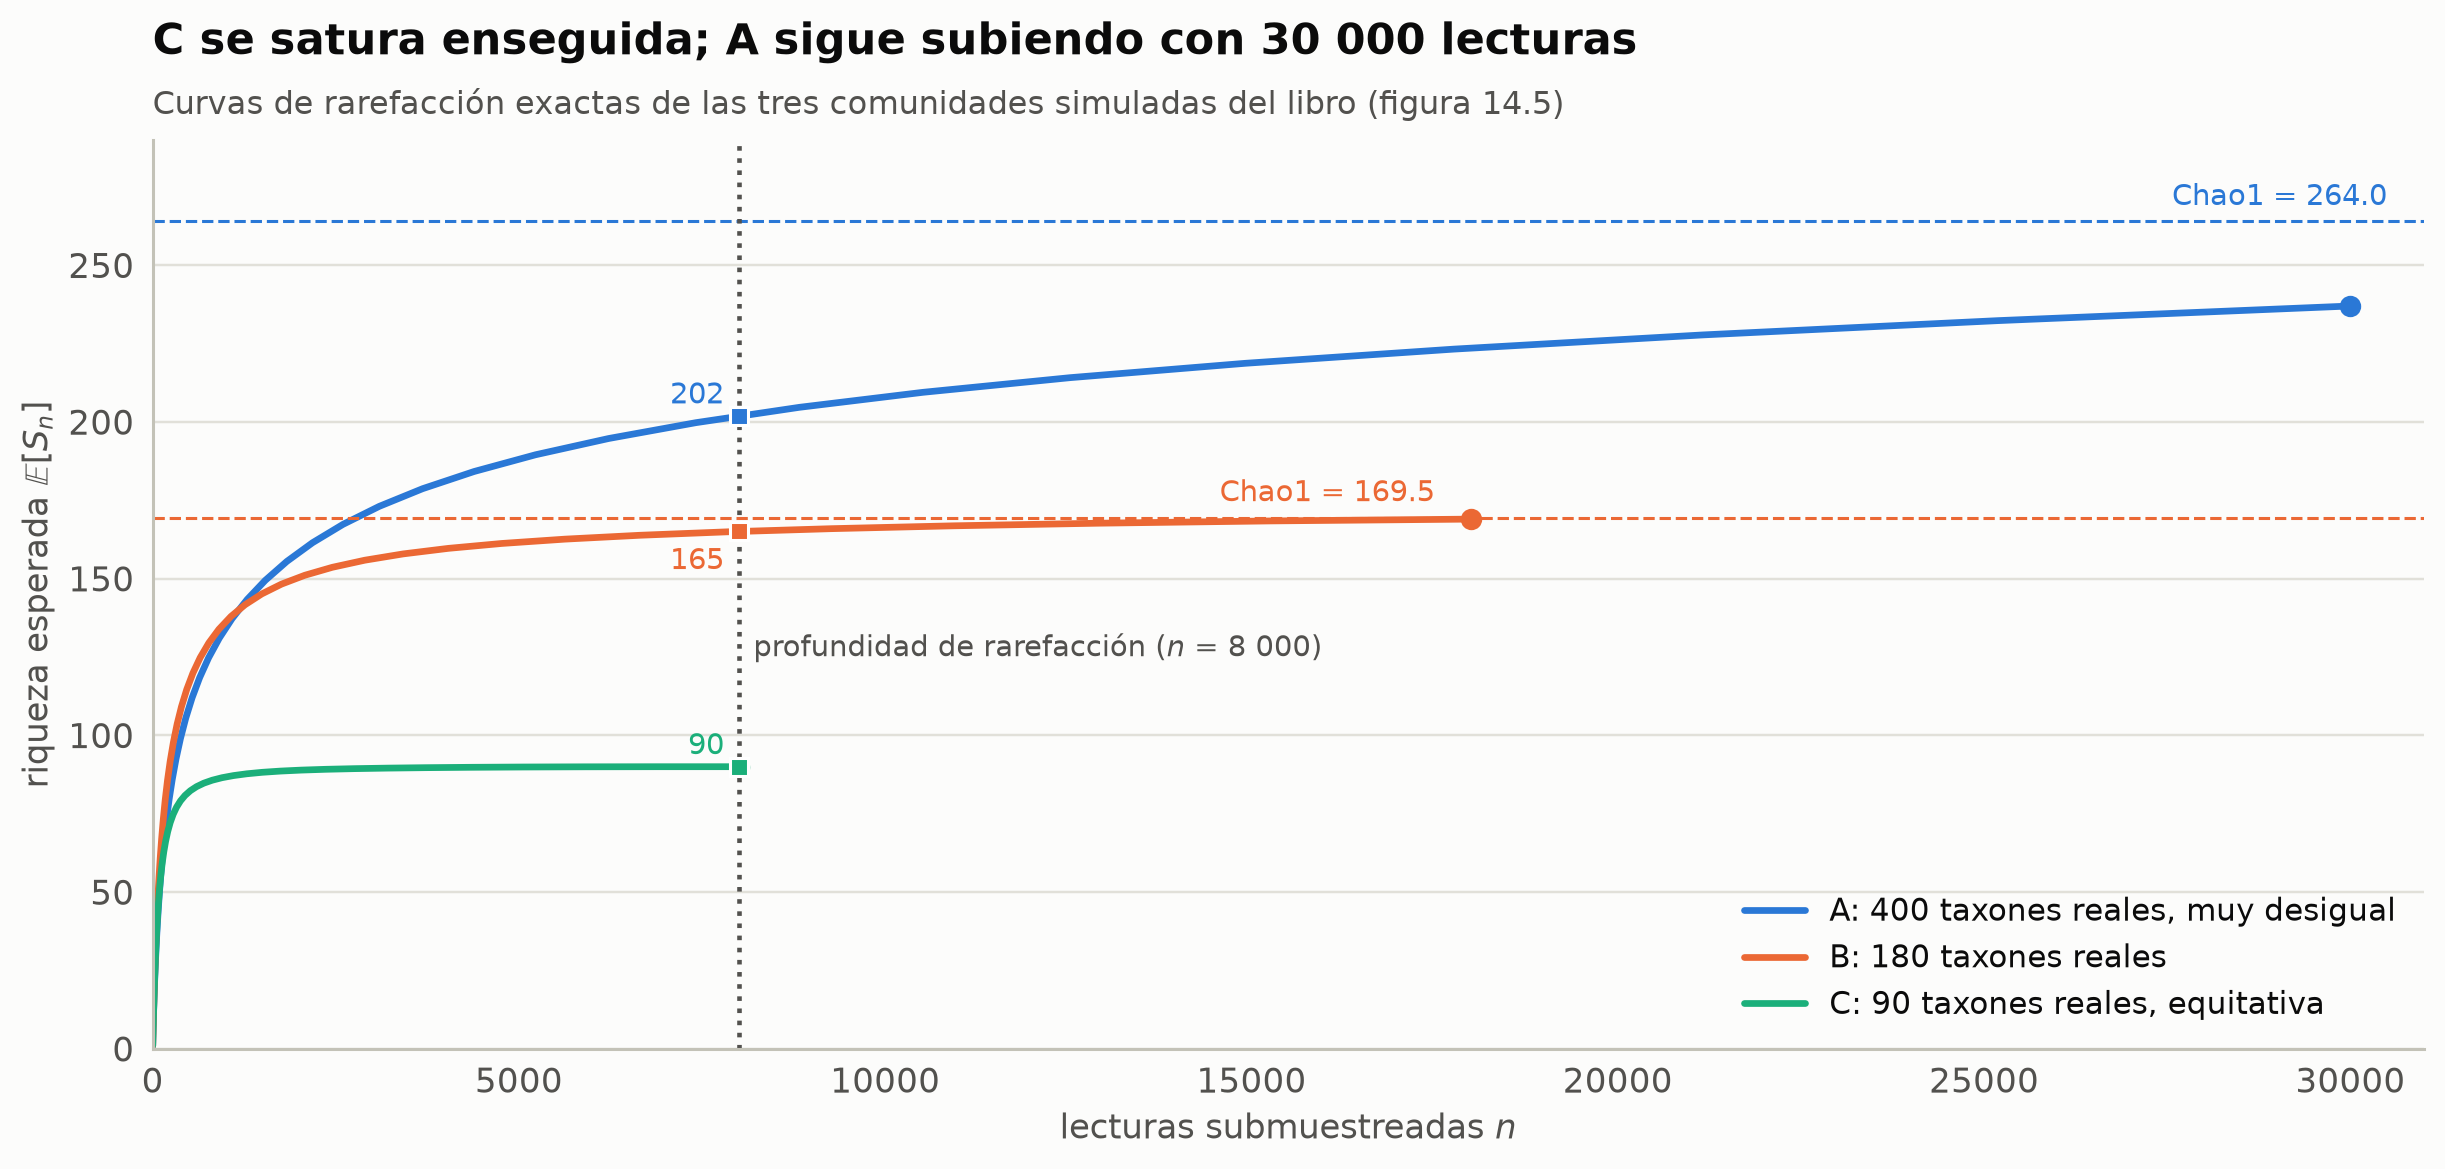

Recortar A a 8 000 lecturas descarta el 73% de sus lecturas.


In [14]:
COLS_ABC = {"A": ec.BLUE, "B": ec.ORANGE, "C": ec.AQUA}
LABELS_ABC = {"A": "A: 400 taxones reales, muy desigual", "B": "B: 180 taxones reales", "C": "C: 90 taxones reales, equitativa"}
fig, ax = plt.subplots(figsize=(11, 5.2))
for k, (ns, s) in rare_curves.items():
    ax.plot(ns, s, color=COLS_ABC[k], lw=2.2, label=LABELS_ABC[k])
    ax.plot(ns[-1], s[-1], "o", color=COLS_ABC[k], ms=6)
for k in ("A", "B"):
    c1 = chao1(book_counts[k], bias_corrected=True)
    ax.axhline(c1, color=COLS_ABC[k], lw=1, ls="--")
    ax.text(30500 if k == "A" else 17500, c1 + 3, f"Chao1 = {c1:.1f}", ha="right", va="bottom", fontsize=9.5,
            color=COLS_ABC[k])
ax.axvline(8000, color=ec.INK_2, ls=":", lw=1.5)
ax.text(8200, 125, "profundidad de rarefacción ($n$ = 8 000)", fontsize=9.5, color=ec.INK_2)
for k in "ABC":
    v = rarefaction(book_counts[k], [8000])[0]
    ax.plot(8000, v, "s", color=COLS_ABC[k], ms=6, mec="white")
    ax.text(7800, v + (4 if k != "B" else -12), f"{v:.0f}", ha="right", fontsize=9.5, color=COLS_ABC[k])
ax.set_xlim(0, 31000); ax.set_ylim(0, 290)
ax.set_xlabel("lecturas submuestreadas $n$"); ax.set_ylabel(r"riqueza esperada $\mathbb{E}[S_n]$")
ax.legend(loc="lower right", frameon=False)
ec.title(ax, "C se satura enseguida; A sigue subiendo con 30 000 lecturas",
         "Curvas de rarefacción exactas de las tres comunidades simuladas del libro (figura 14.5)")
plt.show()
share = 1 - 8000 / book_counts["A"].sum()
print(f"Recortar A a 8 000 lecturas descarta el {share:.0%} de sus lecturas.")

> 🔎 **Qué observamos.** La curva crece rápido al principio, cuando cada lectura nueva tiene alta probabilidad de
> pertenecer a un taxón no visto, y se aplana cuando sólo quedan por descubrir los raros. **C**, pequeña y equitativa,
> se satura enseguida: sus 90 taxones aparecen todos. **B** casi se satura. **A**, con 400 taxones y una larguísima
> cola de raros, sigue subiendo: se observan sólo 237, y Chao1 estima 264, una cota inferior **muy** por debajo del
> valor real, como anticipaba el teorema (abundancias heterogéneas → cota holgada). Recortar las tres muestras a
> 8 000 lecturas hace comparables sus riquezas (202, 165 y 90), a costa de descartar el 73 % de las lecturas de A.

### 4.3 La pendiente final: la cobertura de Good-Turing

La pendiente de la curva al final tiene una interpretación elegante: la probabilidad de que la **siguiente** lectura
pertenezca a un taxón nuevo es aproximadamente $f_1/N$ (la proporción de lecturas que son *singletons*). Su
complemento es la **cobertura de muestra** de Good y Turing (Good, 1953):

$$
\hat C \approx 1 - \frac{f_1}{N},
$$

la fracción de la comunidad, **ponderada por abundancia**, que la muestra ya representa. Chao et al. (2014) proponen
comparar muestras no a igual número de lecturas sino a **igual cobertura**, y extender las curvas por extrapolación
en lugar de recortarlas.

In [15]:
for k, x in book_counts.items():
    N, f1 = x.sum(), (x == 1).sum()
    ns, s = rare_curves[k]
    slope = rarefaction(x, [N])[0] - rarefaction(x, [N - 1])[0]
    missing_mass = com[k][0][x == 0].sum()                    # verdad: abundancia total de los taxones no vistos
    print(f"{k}: f1/N = {f1 / N:.5f}  ·  pendiente final de la curva = {slope:.5f}  ·  "
          f"cobertura Ĉ = {1 - f1 / N:.4f}  ·  masa real no vista = {missing_mass:.5f}")

A: f1/N = 0.00090  ·  pendiente final de la curva = 0.00090  ·  cobertura Ĉ = 0.9991  ·  masa real no vista = 0.00071
B: f1/N = 0.00017  ·  pendiente final de la curva = 0.00017  ·  cobertura Ĉ = 0.9998  ·  masa real no vista = 0.00061
C: f1/N = 0.00000  ·  pendiente final de la curva = 0.00000  ·  cobertura Ĉ = 1.0000  ·  masa real no vista = 0.00000


> 🔎 **Qué observamos.** La pendiente final de la curva coincide con $f_1/N$, y $1-\hat C$ es del mismo orden que la masa
> real de los taxones que no vimos (una milésima o menos). Fíjese en A: le **faltan 163 taxones** y, sin embargo, su cobertura es 0,999. No hay
> contradicción: esos 163 taxones juntos suman menos del 0,1 % de la comunidad. La riqueza cuenta taxones; la
> cobertura pesa lecturas.

### 4.4 Las curvas de rarefacción del ratón (🎛️ interactivo)

Apliquemos la fórmula exacta a las 19 muestras reales. Pase el ratón por una curva: verá la muestra, el día después
del destete, el número de lecturas $n$, la riqueza esperada y la cobertura de la muestra completa.

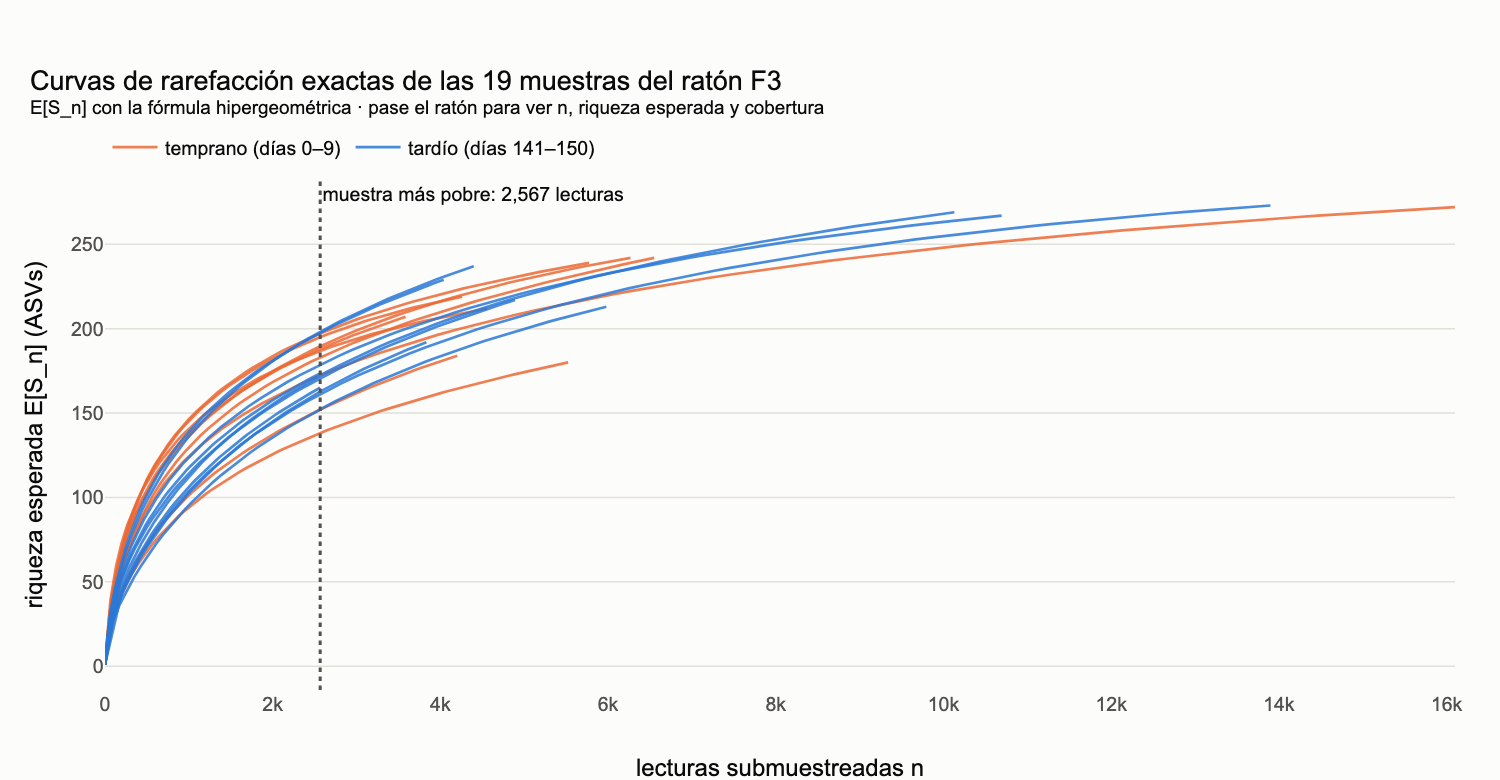

In [16]:
fig = go.Figure()
n_min = N_k.min()
for k, s in enumerate(samples):
    x = X_real[k]
    ns = np.unique(np.concatenate([np.linspace(1, N_k[k], 70).astype(int), [n_min, N_k[k]]]))
    es = rarefaction(x, ns)
    cov = 1 - (x == 1).sum() / N_k[k]
    per = period[k]
    fig.add_trace(go.Scatter(
        x=ns, y=es, mode="lines", line=dict(color=PERIOD_COLORS[per], width=1.8), opacity=0.85,
        name=PERIOD_NAMES[per], legendgroup=per, showlegend=bool(k in (0, 9)),
        customdata=np.column_stack([np.full(len(ns), meta.day_post_weaning.iloc[k])]),
        hovertemplate=(f"<b>{s}</b> · día %{{customdata[0]}} tras el destete<br>"
                       "n = %{x:,} lecturas submuestreadas<br>E[S_n] = %{y:.1f} ASVs esperadas<br>"
                       f"profundidad total N = {N_k[k]:,} · S_obs = {(x > 0).sum()}<br>"
                       f"cobertura de Good-Turing = {cov:.3f} (f1 = {(x == 1).sum()})<extra></extra>")))
fig.add_vline(x=n_min, line=dict(color=ec.INK_2, dash="dot"),
              annotation_text=f"muestra más pobre: {n_min:,} lecturas", annotation_position="top right")
fig.update_layout(
    title="Curvas de rarefacción exactas de las 19 muestras del ratón F3"
          "<br><sup>E[S_n] con la fórmula hipergeométrica · pase el ratón para ver n, riqueza esperada y cobertura</sup>",
    xaxis_title="lecturas submuestreadas n", yaxis_title="riqueza esperada E[S_n] (ASVs)",
    height=520, width=950, margin=dict(t=120, l=70, r=30, b=60),
    legend=dict(orientation="h", yanchor="bottom", y=1.02, x=0))
fig.show()

> 🔎 **Qué observamos.** Ninguna curva está completamente plana: con 2 500–16 000 lecturas todavía aparecen ASVs
> nuevas, aunque despacio (las coberturas de Good-Turing están entre 0,97 y 1,00). A la profundidad de la muestra más pobre, las
> curvas tempranas y tardías se entremezclan: **la diferencia de riqueza entre períodos es pequeña** comparada con la
> variación de un día a otro. Compare con la figura de la sección 2.4, donde la riqueza sin corregir mezclaba biología
> y profundidad.

### 4.5 🎬 La rarefacción, lectura a lectura

La fórmula da el **promedio** sobre todos los submuestreos posibles. En la práctica, rarificar una tabla consiste en
hacer **uno** de ellos. La animación toma la muestra más profunda (día 2, 16 100 lecturas), baraja sus lecturas y las
va «leyendo» en ese orden, tres veces con tres barajas distintas. A la derecha, cada columna es una de sus ASVs
(ordenadas de la más a la menos abundante) y se colorea en el momento en que aparece por primera vez.

![Tres barajas de las 16 100 lecturas del día 2: la riqueza observada sigue a la curva exacta E[S_n] con pequeñas diferencias, y los taxones abundantes aparecen primero, los raros al final](https://raw.githubusercontent.com/juvenalyosa/bioinformatica-practica/main/assets/modulo-14-metagenomica/14.2_rarefaccion_lecturas.gif)

*Tres barajas de las 16 100 lecturas del día 2: la riqueza observada sigue a la curva exacta E[S_n] con pequeñas diferencias, y los taxones abundantes aparecen primero, los raros al final*

In [17]:
k_deep = int(np.argmax(N_k)); x_deep = X_real[k_deep]
taxa_deep = np.where(x_deep > 0)[0]
taxa_deep = taxa_deep[np.argsort(-x_deep[taxa_deep])]            # ASVs presentes, de más a menos abundante
labels_reads = np.repeat(np.arange(len(taxa_deep)), x_deep[taxa_deep])
orders = [rng_nb.permutation(labels_reads) for _ in range(3)]
first_seen = []
for o in orders:
    fs = np.full(len(taxa_deep), np.inf)
    _, idx = np.unique(o, return_index=True)
    fs[np.unique(o)] = idx + 1                                    # lectura en que aparece cada taxón
    first_seen.append(fs)
N_deep = len(labels_reads)
FR = np.unique(np.geomspace(5, N_deep, 52).astype(int))
exact_deep = rarefaction(x_deep, FR)
cols3 = [ec.ORANGE, ec.VIOLET, ec.AQUA]

fig = plt.figure(figsize=(12.5, 5.4))
fig.get_layout_engine().set(rect=(0, 0, 1, 0.86))
gs = fig.add_gridspec(1, 2, width_ratios=[1.1, 1])
ax = fig.add_subplot(gs[0]); axr = fig.add_subplot(gs[1])
ax.plot(FR, exact_deep, color=ec.INK, lw=1.5, ls="--", label=r"curva exacta $\mathbb{E}[S_n]$")
lines = [ax.plot([], [], color=c, lw=1.8, label=f"baraja {j + 1}")[0] for j, c in enumerate(cols3)]
ax.set_xscale("log"); ax.set_xlim(4, N_deep * 1.1); ax.set_ylim(0, len(taxa_deep) * 1.05)
ax.set_xlabel("lecturas leídas $n$ (escala log)"); ax.set_ylabel("ASVs observadas")
ax.legend(loc="upper left", frameon=False, fontsize=9.5)
ntxt = ax.text(0.97, 0.05, "", transform=ax.transAxes, ha="right", fontsize=11, fontweight="bold", color=ec.INK)
ab = x_deep[taxa_deep]
bars = axr.bar(np.arange(len(taxa_deep)), np.log10(ab) + 0.15, width=1.0, color=ec.GRID)
axr.set_xlim(-1, len(taxa_deep)); axr.set_ylim(0, 3.9)
axr.set_xlabel(f"las {len(taxa_deep)} ASVs del día 2, de más a menos abundante")
axr.set_ylabel("log$_{10}$ lecturas en la muestra completa")
stxt = axr.text(0.97, 0.93, "", transform=axr.transAxes, ha="right", fontsize=10.5, color=ec.INK)
fig.text(0.01, 0.985, "Rarificar es sacar lecturas al azar: los taxones abundantes aparecen enseguida, los raros al final",
         fontsize=14.5, fontweight="bold", color=ec.INK, va="top")
fig.text(0.01, 0.935, "Muestra F3D2 (16 100 lecturas). Izquierda: riqueza observada en tres submuestreos. Derecha: "
         "ASVs ya descubiertas en la baraja 1 (color)", fontsize=10.5, color=ec.INK_2, va="top")

def update(f):
    n = FR[f]
    for j, ln in enumerate(lines):
        grid = FR[: f + 1]
        ln.set_data(grid, [(first_seen[j] <= g).sum() for g in grid])
    seen = first_seen[0] <= n
    for b, sflag in zip(bars, seen):
        b.set_color(ec.BLUE if sflag else ec.GRID)
    ntxt.set_text(f"n = {n:,} lecturas")
    stxt.set_text(f"descubiertas: {seen.sum()} de {len(taxa_deep)}")
    return []

fig.canvas.draw()
with plt.rc_context({"savefig.bbox": None}):
    anim_html = ec.animate(fig, update, frames=len(FR), interval=160, name="14.2_rarefaccion_lecturas")
anim_html

▶️ Ejecute esta celda para ver la animación con controles (la vista previa GIF está en la celda de texto de arriba).

> 🔎 **Qué observamos.** Las tres barajas siguen de cerca a la curva exacta, pero no la calcan: cada rarefacción
> concreta tiene su propio ruido. A la derecha, las columnas altas (taxones abundantes) se colorean en las primeras
> cien lecturas; las bajas (vistas 1–3 veces en la muestra completa) aparecen de forma dispersa y tardía. Con 2 567
> lecturas, la profundidad de la muestra más pobre, todavía faltan bastantes.

### 4.6 La controversia: ¿rarificar la tabla?

En microbiología se popularizó **rarificar** la tabla: submuestrear cada muestra hasta la profundidad de la más pobre
y tirar el resto. McMurdie y Holmes (2014) argumentaron que esto es «inadmisible» para el análisis de **abundancia
diferencial**: desechar datos válidos aumenta la varianza, reduce la potencia, añade incertidumbre artificial (**dos
rarefacciones dan resultados distintos**) y obliga a eliminar muestras. Propusieron modelos que tratan explícitamente
la profundidad, como los binomiales negativos de RNA-seq (Módulo 11). Para la **diversidad alfa**, que depende
intrínsecamente del esfuerzo, alguna estandarización (rarefacción, cobertura o extrapolación) sigue siendo necesaria:
la curva de rarefacción como diagnóstico es siempre útil; la tabla rarificada para abundancia diferencial, no.

Veamos la «incertidumbre artificial» con nuestros datos: rarificamos 20 veces la tabla real a 2 567 lecturas y
comparamos con el valor esperado exacto.

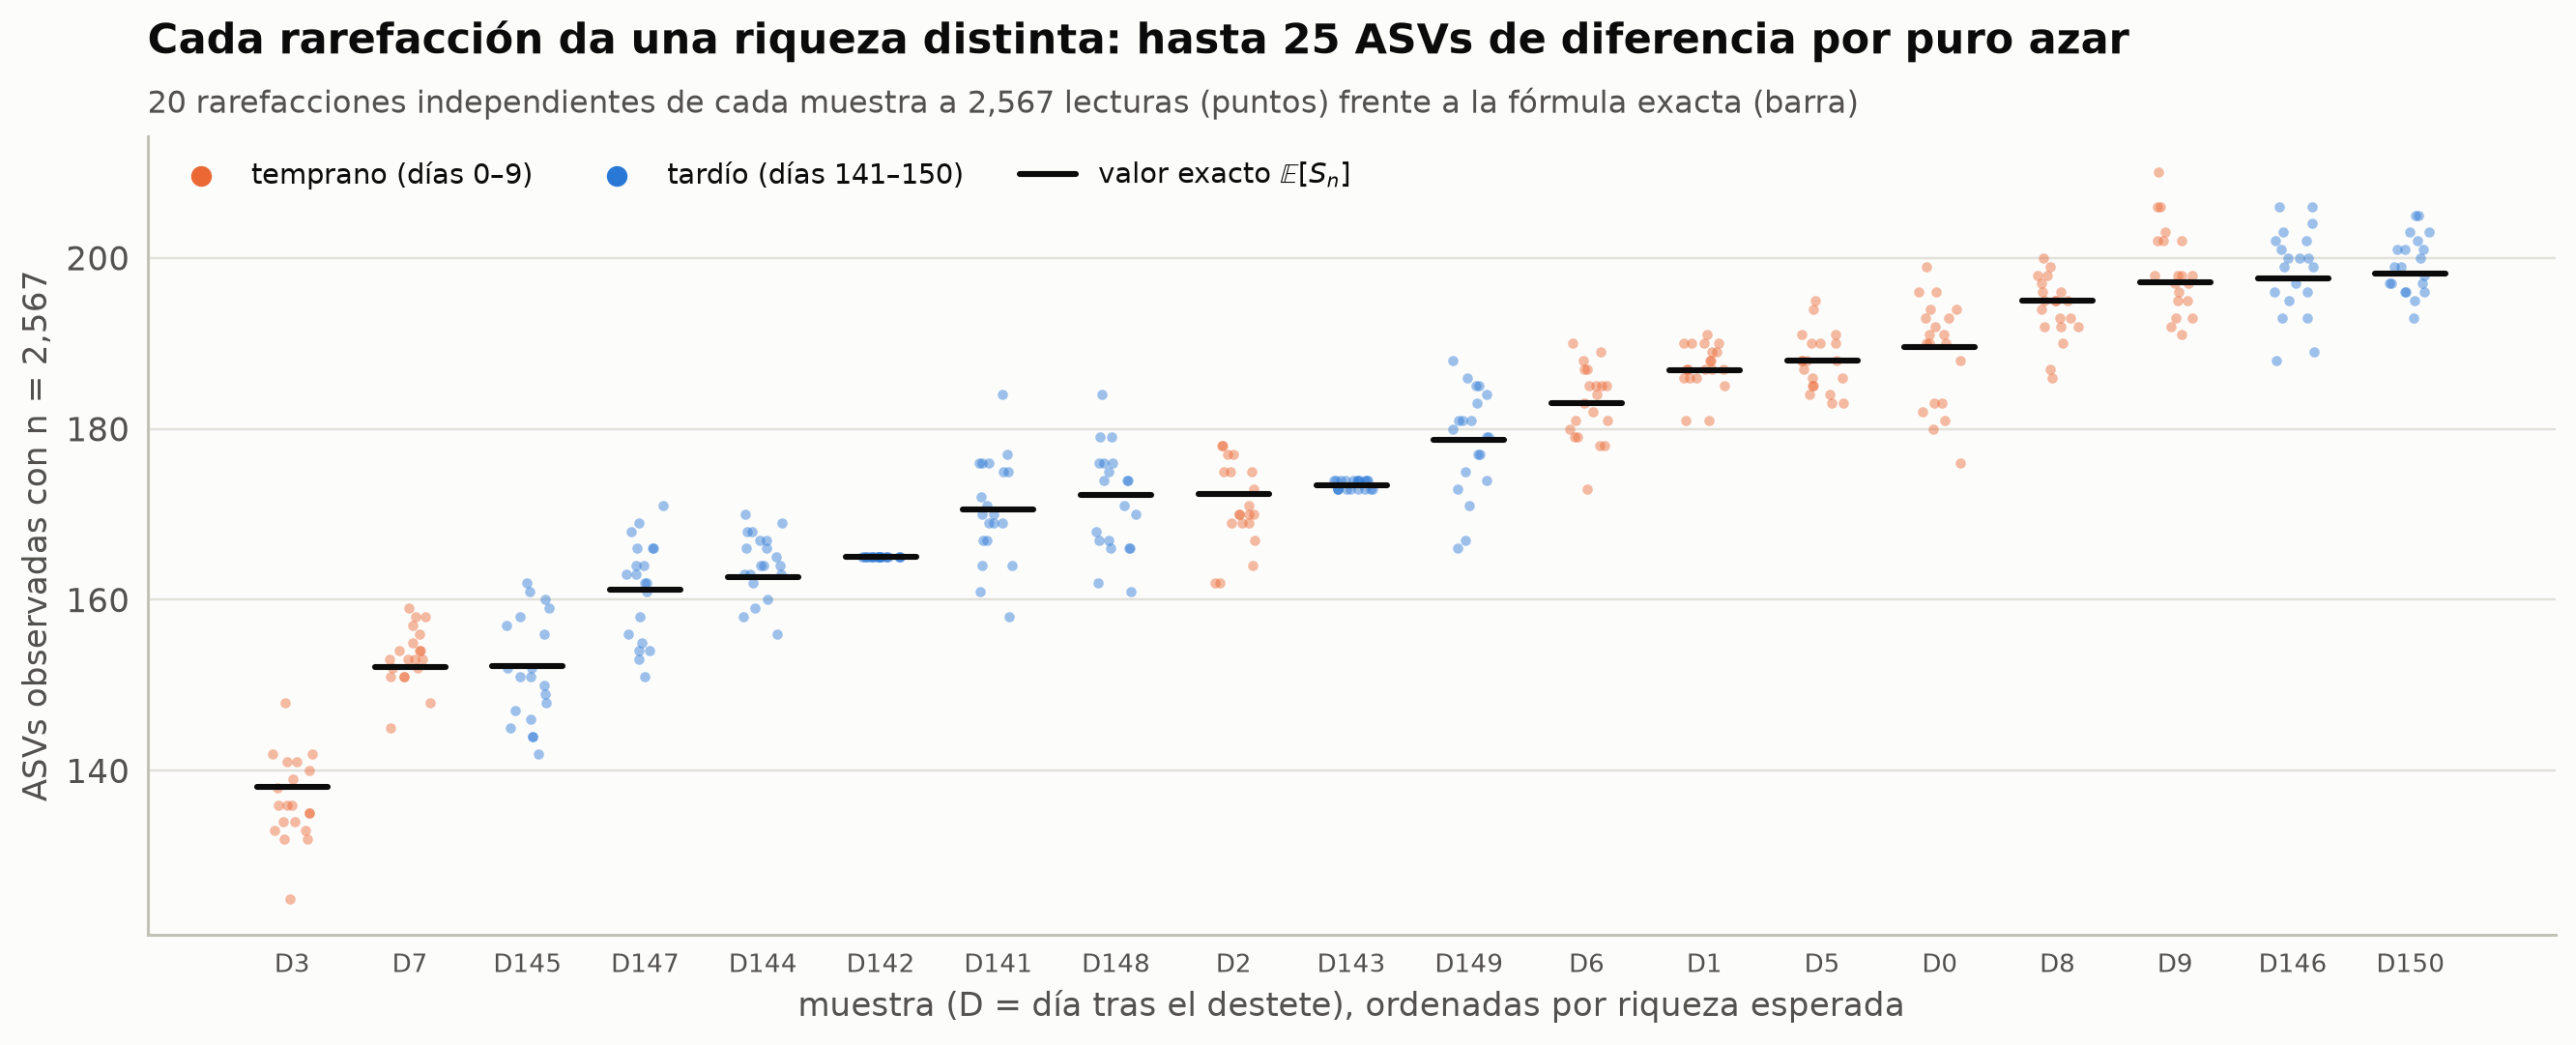

Amplitud (máx − mín) de la riqueza entre rarefacciones: mediana 17 ASVs, máximo 26
Lecturas descartadas al rarificar toda la tabla: 59%
E[S_2567] medio, temprano (días 0–9): 178.0
E[S_2567] medio, tardío (días 141–150): 173.2


In [18]:
def rarefy(x, n, rng):
    """Una rarefacción concreta: n lecturas sin reposición (hipergeométrica multivariada)."""
    return rng.multivariate_hypergeometric(np.asarray(x, dtype=np.int64), n)

n_rar = int(N_k.min())
S_rar = np.array([[(rarefy(x, n_rar, rng_nb) > 0).sum() for x in X_real] for _ in range(20)])   # 20 × 19
S_exp = np.array([rarefaction(x, [n_rar])[0] for x in X_real])
ordr = np.argsort(S_exp)
fig, ax = plt.subplots(figsize=(12, 4.8))
for j, k in enumerate(ordr):
    ax.scatter(np.full(20, j) + rng_nb.uniform(-0.18, 0.18, 20), S_rar[:, k], s=12, color=PERIOD_COLORS[period[k]],
               alpha=0.45, lw=0)
    ax.plot([j - 0.3, j + 0.3], [S_exp[k]] * 2, color=ec.INK, lw=2)
ax.set_xticks(range(len(samples)), [samples[k].replace("F3", "") for k in ordr], rotation=0, fontsize=8.5)
ax.set_xlabel("muestra (D = día tras el destete), ordenadas por riqueza esperada")
ax.set_ylabel(f"ASVs observadas con n = {n_rar:,}")
for per in ("early", "late"):
    ax.scatter([], [], color=PERIOD_COLORS[per], label=PERIOD_NAMES[per])
ax.plot([], [], color=ec.INK, lw=2, label=r"valor exacto $\mathbb{E}[S_n]$")
ax.legend(frameon=False, ncol=3, loc="upper left", fontsize=9.5)
ec.title(ax, "Cada rarefacción da una riqueza distinta: hasta 25 ASVs de diferencia por puro azar",
         f"20 rarefacciones independientes de cada muestra a {n_rar:,} lecturas (puntos) frente a la fórmula exacta (barra)")
plt.show()
rng_span = S_rar.max(0) - S_rar.min(0)
print(f"Amplitud (máx − mín) de la riqueza entre rarefacciones: mediana {np.median(rng_span):.0f} ASVs, máximo {rng_span.max()}")
print(f"Lecturas descartadas al rarificar toda la tabla: {1 - n_rar * len(N_k) / N_k.sum():.0%}")
for per in ("early", "late"):
    print(f"E[S_{n_rar}] medio, {PERIOD_NAMES[per]}: {S_exp[period == per].mean():.1f}")

> 🔎 **Qué observamos.** Una misma muestra, rarificada dos veces, puede diferir en más de una decena de ASVs
> (la amplitud mediana entre 20 rarefacciones es de unas 17): eso es ruido
> que **nosotros** añadimos. La fórmula exacta (barra negra) no tiene ese problema, porque promedia todos los
> submuestreos posibles. Y para lograr la comparabilidad hemos tirado más de la mitad de las lecturas del
> experimento. A igual profundidad, la riqueza esperada de los dos períodos es muy parecida.

> ✅ **Compruebe su comprensión.** ¿Por qué la rarefacción es razonable para comparar **riquezas** pero no para hacer
> una prueba de abundancia diferencial de un taxón? *(La riqueza depende del esfuerzo por definición y hay que
> estandarizarlo; una abundancia diferencial se modela mejor con la profundidad como variable conocida del modelo,
> sin tirar datos ni añadir ruido.)*

## 5. Números de Hill: una familia que unifica

### 5.1 Una sola fórmula con un «dial»

La sección 2 dejó una incomodidad: la riqueza, Shannon y Simpson miden cosas distintas en escalas distintas. Hill
(1973) mostró que son, en realidad, miembros de una única familia, con un parámetro $q$ que funciona como el dial de
sensibilidad de un micrófono: con $q=0$ se oye a todos por igual, incluidos los que susurran (los raros); al subir $q$
sólo se oye a los que gritan (los dominantes).

$$
{}^{q}D = \left(\sum_{i=1}^{S} p_i^{\,q}\right)^{1/(1-q)}, \qquad q \ne 1, \qquad\qquad {}^{1}D = \lim_{q\to1} {}^{q}D .
$$

| Símbolo | Significado |
|---|---|
| ${}^{q}D$ | Diversidad de orden $q$, medida en «número efectivo de taxones». |
| $q$ | Orden: controla cuánto peso reciben los taxones abundantes frente a los raros. |
| $p_i$ | Abundancia relativa del taxón $i$. |

### 5.2 Los casos notables

* $q=0$: cada $p_i^0=1$, así que ${}^0D=S$, **la riqueza**.
* $q=2$: ${}^2D=1/\sum p_i^2=1/D$, **el Simpson inverso**.
* $q\to\infty$: domina el término mayor y ${}^{\infty}D = 1/\max_i p_i$ (Berger-Parker inverso).
* $q=1$ requiere un límite. Tomando logaritmos, $\ln {}^qD = \ln\bigl(\sum_i p_i^q\bigr)/(1-q)$, que en $q=1$ es de la
  forma $0/0$ (porque $\sum_i p_i=1$ y $\ln 1=0$). Por la regla de L'Hôpital, derivando numerador y denominador
  respecto de $q$ (y recordando que $\tfrac{d}{dq}p_i^q=p_i^q\ln p_i$):

$$
\lim_{q\to1}\ln {}^qD = \lim_{q\to1}\frac{\sum_i p_i^q \ln p_i \,/\, \sum_i p_i^q}{-1} = -\sum_i p_i \ln p_i = H,
\qquad\text{es decir,}\qquad {}^1D = e^{H}.
$$

La exponencial de Shannon es el número de Hill de orden 1. Para la comunidad de nueve taxones: ${}^0D=9$,
${}^1D=e^{1{,}495}=4{,}46$, ${}^2D=3{,}19$ y ${}^\infty D=1/0{,}5=2$. **Ahora sí** los tres índices hablan el mismo
idioma: «la muestra es tan diversa como una comunidad de 9, 4,5 o 3,2 taxones igual de abundantes, según cuánto
pesemos a los raros».

In [19]:
def hill(p, q):
    """Número de Hill de orden q (función del libro); acepta conteos o proporciones."""
    p = np.asarray(p, dtype=float); p = p[p > 0] / p.sum()
    if np.isinf(q):
        return 1 / p.max()
    if np.isclose(q, 1):
        return np.exp(-(p * np.log(p)).sum())
    return (p ** q).sum() ** (1 / (1 - q))

for q in (0, 0.5, 0.99, 0.999, 1, 1.001, 2, np.inf):
    print(f"q = {q:>6}:  ^qD = {hill(toy, q):.4f}")
print(f"Comprobación: e^H = {np.exp(H):.4f} · 1/D = {1 / D:.4f} · 1/max p = {1 / p.max():.1f}")

q =      0:  ^qD = 9.0000
q =    0.5:  ^qD = 6.0113
q =   0.99:  ^qD = 4.4819
q =  0.999:  ^qD = 4.4622
q =      1:  ^qD = 4.4601
q =  1.001:  ^qD = 4.4579
q =      2:  ^qD = 3.1928
q =    inf:  ^qD = 2.0000
Comprobación: e^H = 4.4601 · 1/D = 3.1928 · 1/max p = 2.0


La función es continua en $q=1$: con $q=0{,}999$ y $q=1{,}001$ obtenemos prácticamente $e^H=4{,}460$.

### 5.3 El principio de replicación: por qué transformar

¿Por qué molestarse en transformar índices que ya conocíamos? Jost (2006) dio el argumento decisivo: la entropía de
Shannon y el índice de Gini-Simpson **no son diversidades**, sino funciones de ellas, y tratarlas como tales produce
conclusiones absurdas.

> **Teorema (principio de replicación).** Si se combinan $m$ comunidades igual de grandes, cada una con número de Hill
> ${}^qD$ y sin ningún taxón en común, la comunidad combinada tiene número de Hill $m\cdot{}^qD$, para todo $q$.

*Demostración.* En la comunidad combinada cada proporción se divide por $m$ y hay $m$ copias de cada término, de modo
que $\sum p_i^q$ se multiplica por $m\cdot m^{-q}=m^{1-q}$ y, al elevar a $1/(1-q)$, ${}^qD$ se multiplica por $m$.
$\square$

En cambio, la entropía de Shannon sólo **suma** $\ln m$. Dos comunidades de ocho especies equiprobables tienen cada
una $H=\ln 8=2{,}08$; su unión, con 16 especies, tiene $H=2{,}77$: apenas un 33 % más, aunque intuitivamente es el
**doble** de diversa. Un tratamiento que reduce la entropía de Shannon «sólo un 10 %» puede estar eliminando la mitad
del número efectivo de taxones.

In [20]:
one = np.ones(8) / 8
two = np.ones(16) / 16                      # unión de dos comunidades de 8 sin taxones en común
for name, f_idx in (("Shannon H", lambda v: -(v * np.log(v)).sum()), ("Gini-Simpson 1-D", lambda v: 1 - (v ** 2).sum()),
                    ("Hill q=1 (e^H)", lambda v: hill(v, 1)), ("Hill q=2 (1/D)", lambda v: hill(v, 2))):
    a, b = f_idx(one), f_idx(two)
    print(f"{name:<18}: una comunidad = {a:6.3f} · las dos juntas = {b:6.3f} · razón = {b / a:.2f}")

# Un antibiótico que elimina la mitad de los taxones de una comunidad equitativa de 200:
before, after = np.ones(200) / 200, np.ones(100) / 100
Hb, Ha = -(before * np.log(before)).sum(), -(after * np.log(after)).sum()
print(f"\nAntibiótico que elimina 100 de 200 taxones: Shannon baja {1 - Ha / Hb:.0%} "
      f"({Hb:.2f} → {Ha:.2f} nats); el número efectivo de taxones baja {1 - np.exp(Ha) / np.exp(Hb):.0%}")

Shannon H         : una comunidad =  2.079 · las dos juntas =  2.773 · razón = 1.33
Gini-Simpson 1-D  : una comunidad =  0.875 · las dos juntas =  0.938 · razón = 1.07
Hill q=1 (e^H)    : una comunidad =  8.000 · las dos juntas = 16.000 · razón = 2.00
Hill q=2 (1/D)    : una comunidad =  8.000 · las dos juntas = 16.000 · razón = 2.00

Antibiótico que elimina 100 de 200 taxones: Shannon baja 13% (5.30 → 4.61 nats); el número efectivo de taxones baja 50%


> 🔎 **Qué observamos.** Sólo los números de Hill se duplican al duplicar la comunidad; Shannon crece un 33 % y
> Gini-Simpson un 7 %. Y un antibiótico que elimina **la mitad** de los taxones reduce la entropía de Shannon en sólo
> un 13 %. Un artículo que dijera «el tratamiento redujo la diversidad de Shannon un 13 %» describiría una catástrofe
> ecológica con un número que suena modesto.

### 5.4 Perfiles de diversidad (figura 14.6 del libro)

Dibujar ${}^qD$ en función de $q$ da el **perfil de diversidad** de una comunidad. El libro compara tres comunidades:
**A**, 60 taxones, uno con el 40 % y 59 raros que se reparten el 60 % restante; **B**, 20 taxones equitativos; y
**C**, 40 taxones con abundancias de Zipf, $p_i\propto i^{-1{,}2}$.

[hill] q=0: A=60.00 B=20.00 C=40.00
[hill] q=1: A=22.64 B=20.00 C=15.31
[hill] q=2: A=6.02 B=20.00 C=7.45
[hill] q=inf: A=2.50 B=20.00 C=3.21


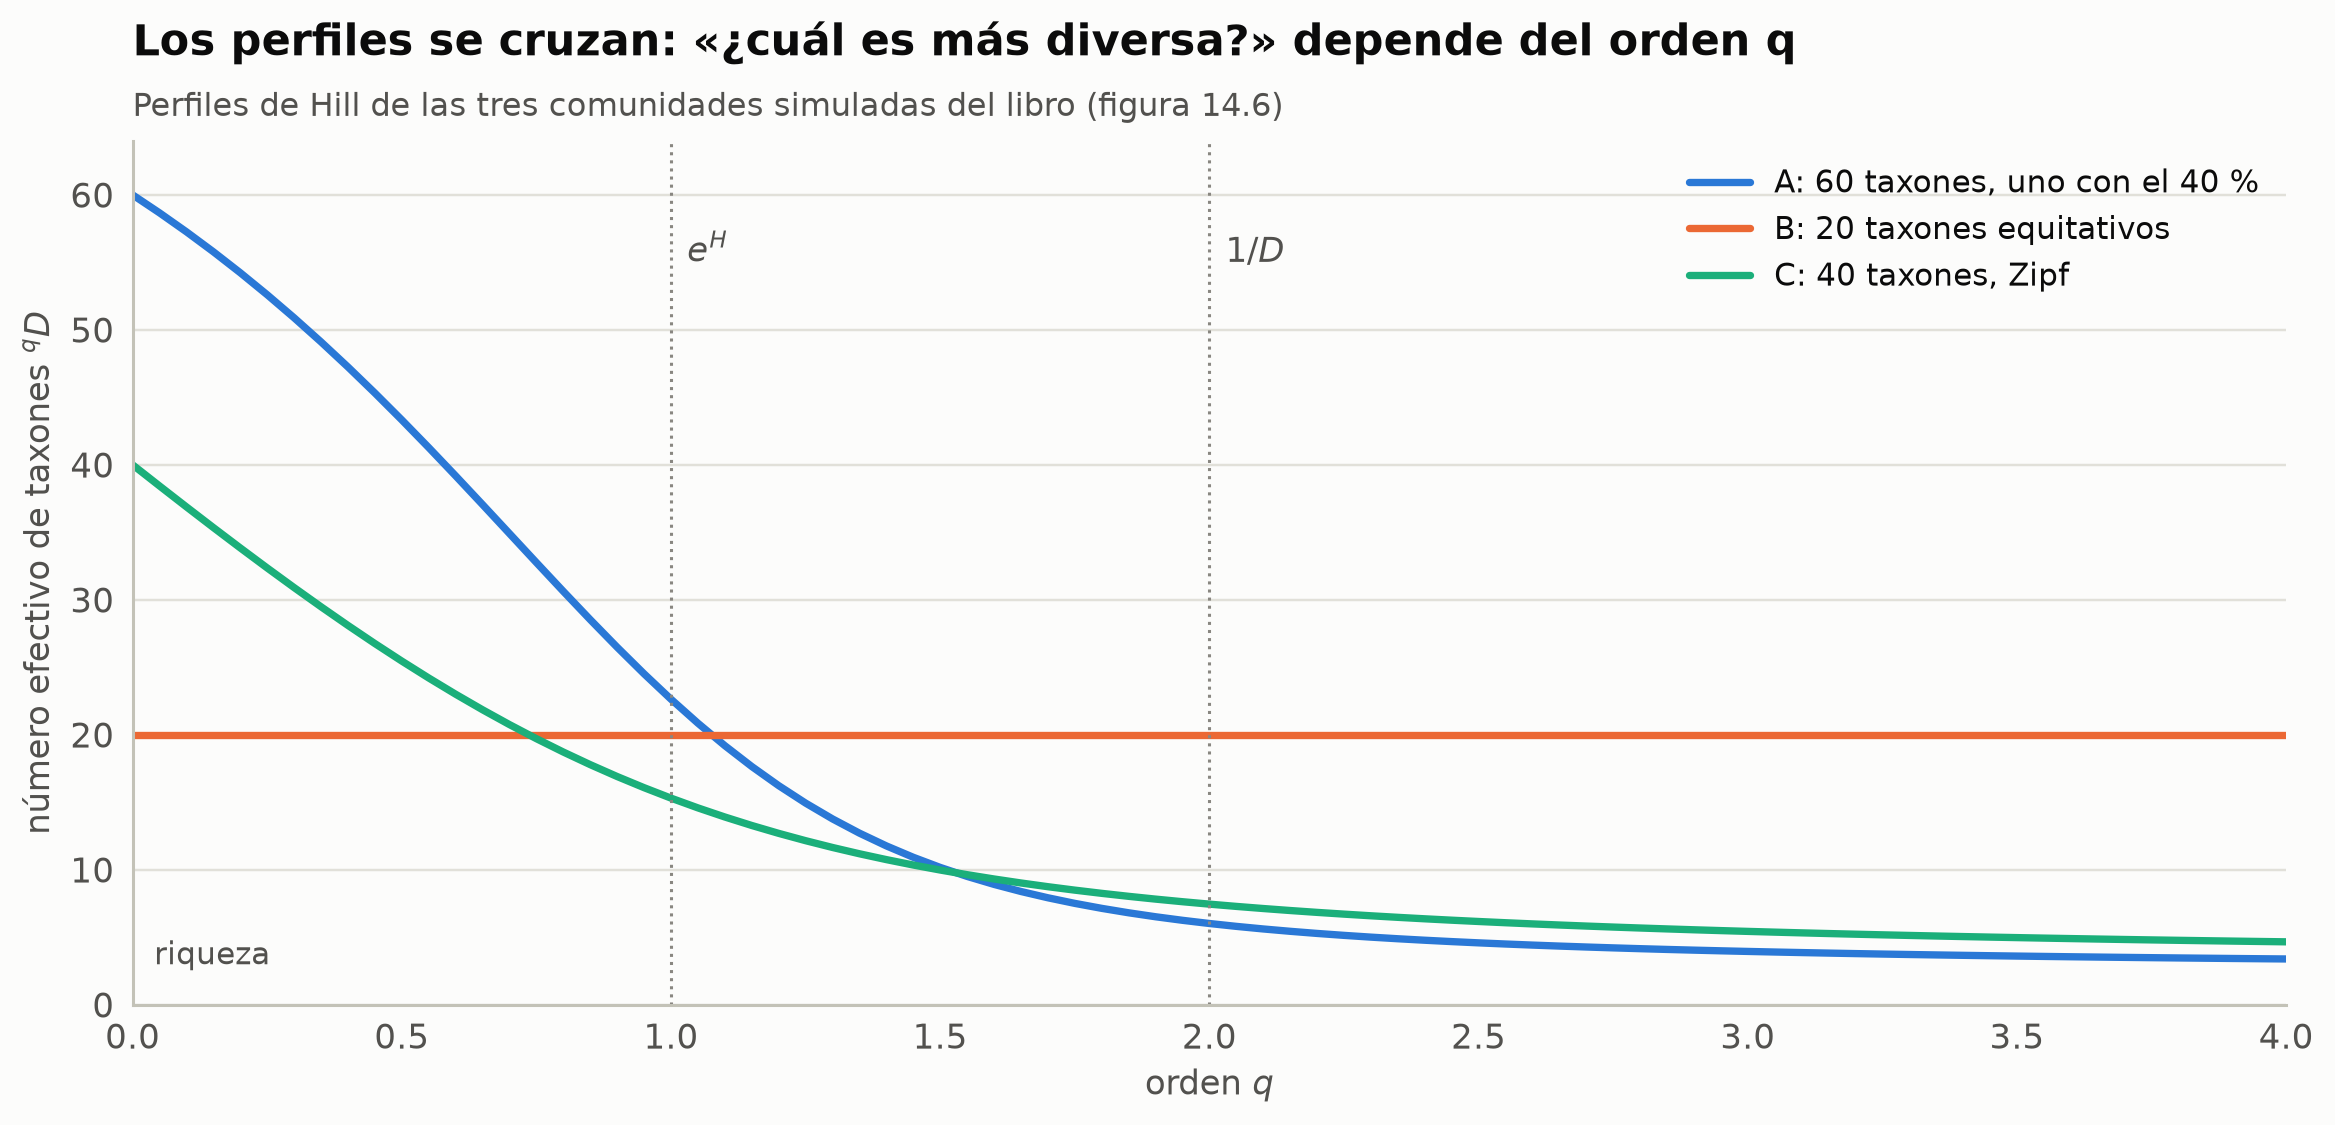

In [21]:
pA = np.array([0.40] + list(0.60 * np.ones(59) / 59))       # 1 dominante + 59 raras
pB = np.ones(20) / 20                                         # 20 equitativas
xz = np.arange(1, 41); pC = xz ** -1.2; pC = pC / pC.sum()    # 40, Zipf
qs = np.round(np.linspace(0, 4, 81), 3)
prof = {k: np.array([hill(pp, q) for q in qs]) for k, pp in (("A", pA), ("B", pB), ("C", pC))}
for q in (0, 1, 2, np.inf):
    print(f"[hill] q={q}: " + " ".join(f"{k}={hill(pp, q):.2f}" for k, pp in (("A", pA), ("B", pB), ("C", pC))))

fig, ax = plt.subplots(figsize=(10.5, 5))
lab = {"A": "A: 60 taxones, uno con el 40 %", "B": "B: 20 taxones equitativos", "C": "C: 40 taxones, Zipf"}
for k in "ABC":
    ax.plot(qs, prof[k], color=COLS_ABC[k], lw=2.4, label=lab[k])
for q, t in ((1, "$e^{H}$"), (2, "$1/D$")):
    ax.axvline(q, color=ec.MUTED, ls=":", lw=1)
    ax.text(q + 0.03, 55, t, fontsize=11, color=ec.INK_2)
ax.text(0.04, 3, "riqueza", fontsize=10, color=ec.INK_2)
ax.set_xlim(0, 4); ax.set_ylim(0, 64); ax.set_xlabel("orden $q$"); ax.set_ylabel("número efectivo de taxones ${}^qD$")
ax.legend(frameon=False, loc="upper right")
ec.title(ax, "Los perfiles se cruzan: «¿cuál es más diversa?» depende del orden q",
         "Perfiles de Hill de las tres comunidades simuladas del libro (figura 14.6)")
plt.show()

> 🔎 **Qué observamos.** El perfil de la comunidad perfectamente equitativa (B) es **plano**: con 20 taxones igual de
> abundantes, cualquier orden da 20. Las desiguales decrecen con $q$ y su ordenamiento **cambia**: A es la más rica
> ($q=0$: 60) y, gracias a sus 59 taxones raros, también la más diversa en $q=1$ ($e^H=22{,}6$), pero en $q=2$ es la
> menos diversa ($1/D=6{,}0$), porque un solo taxón domina. Si dos perfiles no se cruzan, una comunidad es
> inequívocamente más diversa que la otra; si se cruzan, la respuesta depende de si importan más los raros (órdenes
> bajos) o los dominantes (órdenes altos). En datos de amplicones, los órdenes $q=1$ y $q=2$ son mucho más robustos
> que la riqueza.

> ✅ **Compruebe su comprensión.** ¿Cuánto vale ${}^qD$ para cualquier $q$ en una muestra con un único taxón? ¿Y el
> perfil de B si le añadimos 20 taxones equitativos nuevos, sin compartir ninguno? *(1 para todo $q$; 40 para todo
> $q$, por el principio de replicación.)*

### 5.5 Los perfiles del ratón

Calculamos el perfil de las 19 muestras reales. Para que la comparación no dependa de la profundidad en el orden 0,
usamos la tabla completa pero marcamos también el valor esperado de la riqueza a igual profundidad.

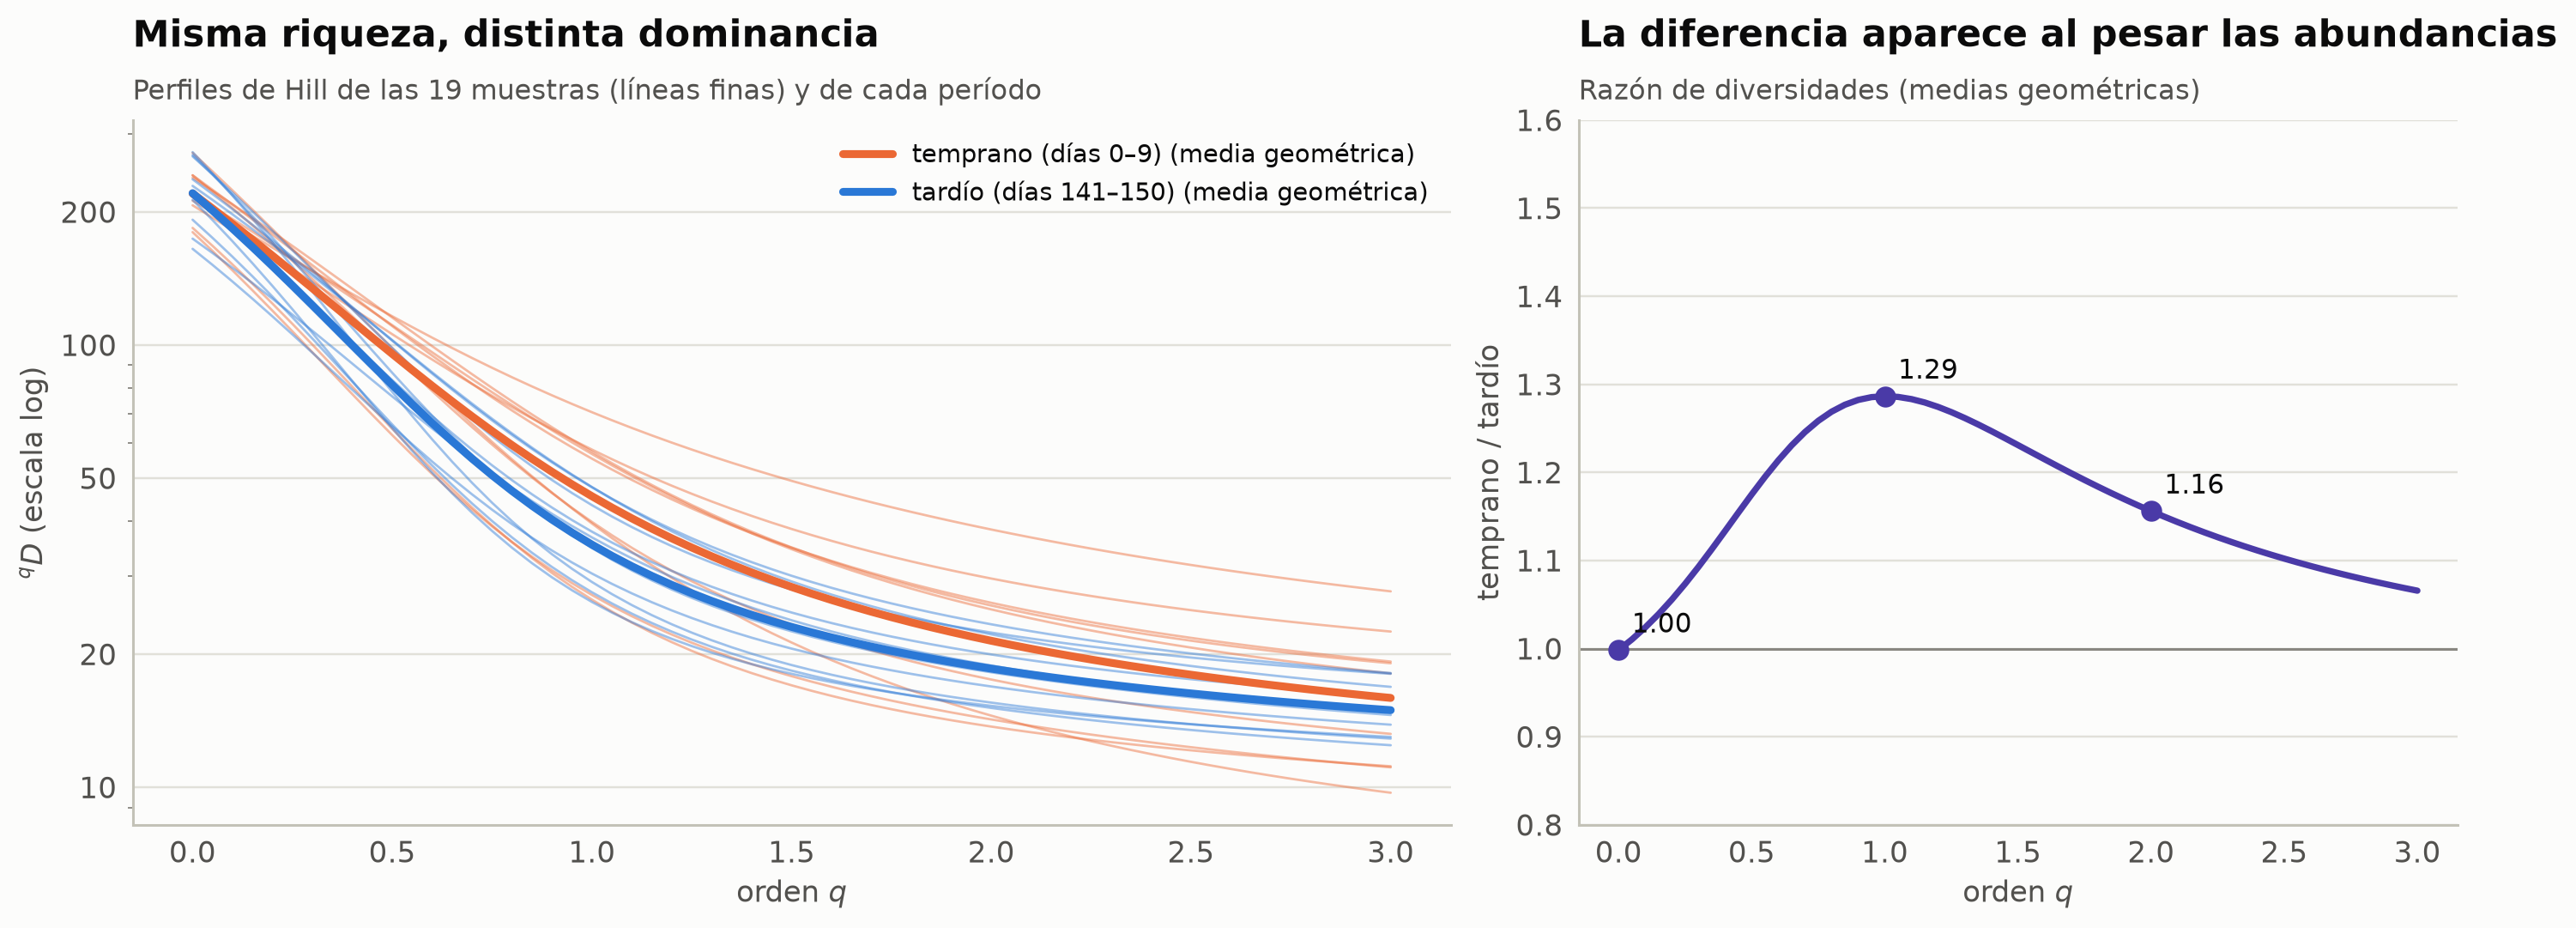

In [22]:
qs_r = np.linspace(0, 3, 61)
prof_real = np.array([[hill(x, q) for q in qs_r] for x in X_real])
fig, (ax, ax2) = plt.subplots(1, 2, figsize=(13, 4.8), gridspec_kw=dict(width_ratios=[1.5, 1]))
for k in range(len(samples)):
    ax.plot(qs_r, prof_real[k], color=PERIOD_COLORS[period[k]], lw=0.9, alpha=0.45)
for per in ("early", "late"):
    m = np.exp(np.log(prof_real[period == per]).mean(0))     # media geométrica del grupo
    ax.plot(qs_r, m, color=PERIOD_COLORS[per], lw=3, label=f"{PERIOD_NAMES[per]} (media geométrica)")
ax.set_yscale("log"); ax.set_yticks([10, 20, 50, 100, 200], ["10", "20", "50", "100", "200"])
ax.set_xlabel("orden $q$"); ax.set_ylabel("${}^qD$ (escala log)")
ax.legend(frameon=False, loc="upper right", fontsize=9.5)
ec.title(ax, "Misma riqueza, distinta dominancia", "Perfiles de Hill de las 19 muestras (líneas finas) y de cada período")
ratio = np.exp(np.log(prof_real[period == "early"]).mean(0) - np.log(prof_real[period == "late"]).mean(0))
ax2.plot(qs_r, ratio, color=ec.VIOLET, lw=2.4)
ax2.axhline(1, color=ec.MUTED, lw=1)
for q in (0, 1, 2):
    j = np.argmin(abs(qs_r - q))
    ax2.plot(q, ratio[j], "o", color=ec.VIOLET); ax2.text(q + 0.05, ratio[j] + 0.02, f"{ratio[j]:.2f}", fontsize=10)
ax2.set_xlabel("orden $q$"); ax2.set_ylabel("temprano / tardío"); ax2.set_ylim(0.8, 1.6)
ec.title(ax2, "La diferencia aparece al pesar las abundancias", "Razón de diversidades (medias geométricas)")
plt.show()

> 🔎 **Qué observamos.** En $q=0$ los dos períodos son prácticamente iguales (razón ≈ 1): tienen la misma riqueza. En
> cuanto $q$ pesa las abundancias, las muestras tempranas resultan más diversas: alrededor de un 29 % más de taxones
> efectivos en $q=1$ y un 16 % más en $q=2$. Es decir: el ratón adulto no ha **perdido** taxones, sino que su comunidad está **más dominada**
> por unos pocos. Un solo índice no habría contado esta historia; el perfil sí.

## 6. Los datos de microbioma son composicionales

### 6.1 Proporciones, no cantidades

Hasta aquí hemos trabajado con proporciones $p_i$ sin preguntar si representan algo absoluto. **No lo hacen.** El
secuenciador produce un número de lecturas por muestra que depende de la carga del equipo, no de la cantidad de
bacterias en el intestino. Un aumento de $x_{ki}$ puede significar que el taxón $i$ creció, que otros taxones
disminuyeron o simplemente que esa muestra recibió más lecturas. Gloor et al. (2017) insistieron en que estos datos
son **composicionales**: sólo contienen información sobre las **razones** entre componentes.

Piense en una encuesta de intención de voto: si un partido pasa del 10 % al 40 %, los demás **tienen** que bajar,
aunque ni un solo votante suyo haya cambiado de opinión. Formalmente, un vector de abundancias absolutas
$\mathbf a$ sólo se observa a través de su **cierre** $\mathbf a/\sum_i a_i$, un punto del símplex; dos vectores
proporcionales, $\mathbf a$ y $c\,\mathbf a$, tienen la misma composición.

### 6.2 El efecto del cierre (figura 14.7 del libro)

Cuatro taxones; entre dos momentos, sólo el taxón 4 se multiplica por diez (por ejemplo, un patobionte que florece
tras un antibiótico). Los otros tres no cambian **en absoluto**.

[compos] rel antes=[0.357 0.286 0.214 0.143] después=[0.156 0.125 0.094 0.625]
[compos] clr antes=[ 0.413  0.189 -0.098 -0.504] después=[-0.163 -0.386 -0.674  1.223]
[compos] log-razón t1/t2 antes=0.223 después=0.223


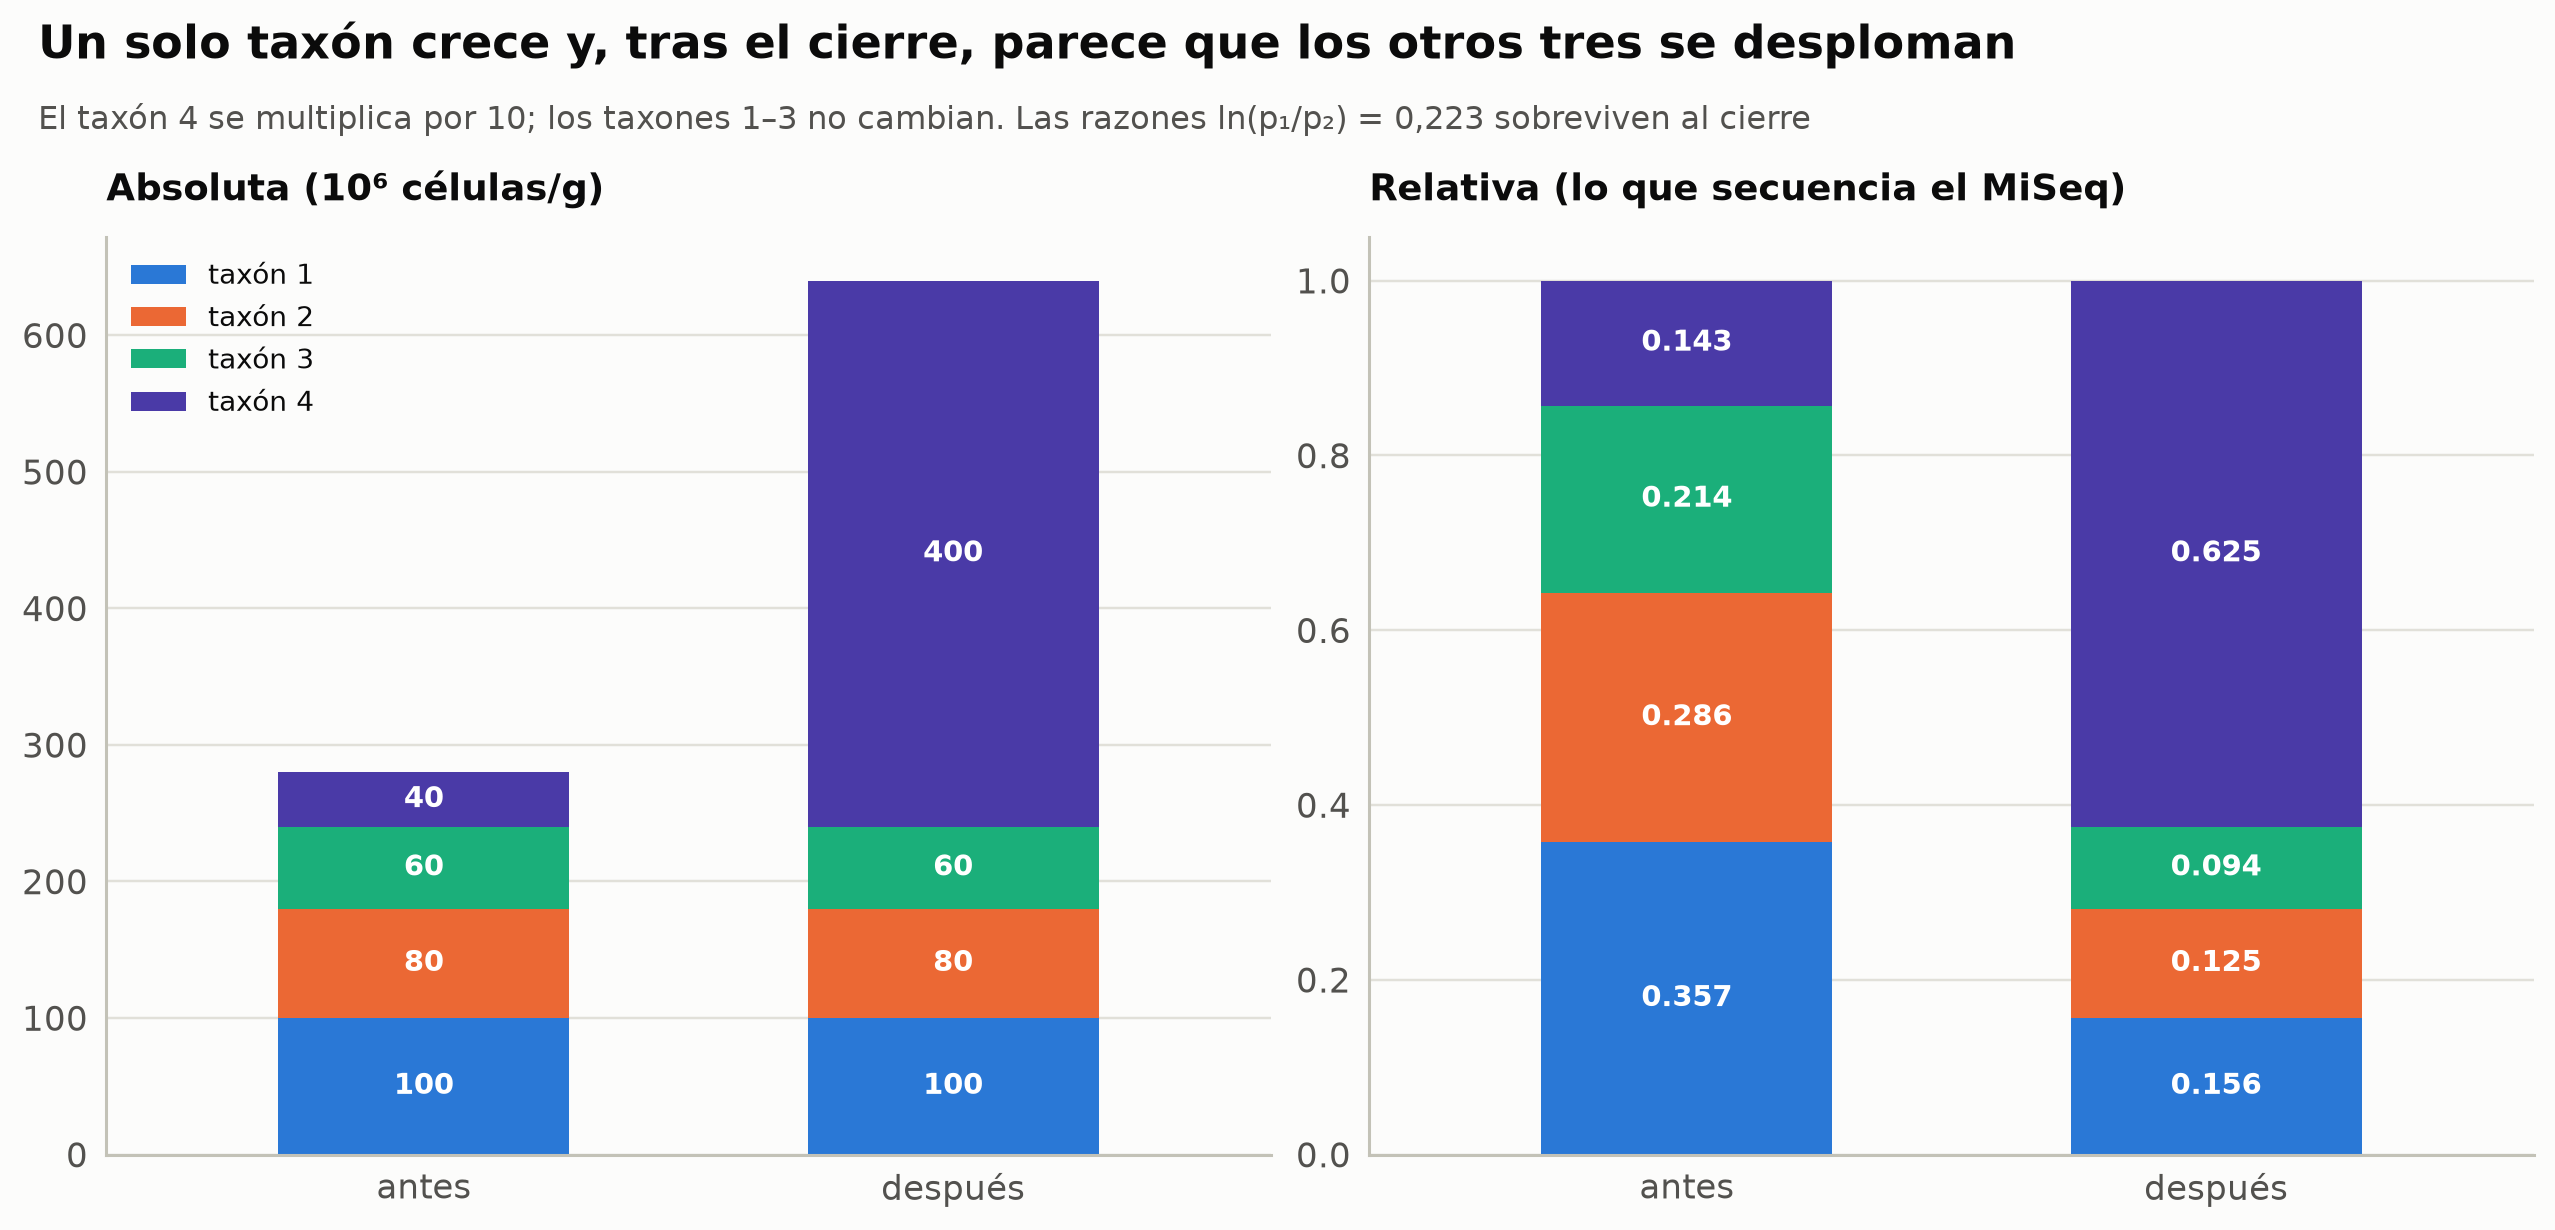

In [23]:
absA = np.array([100, 80, 60, 40])       # antes (10^6 células/g)
absB = np.array([100, 80, 60, 400])      # después: sólo el taxón 4 crece
relA, relB = absA / absA.sum(), absB / absB.sum()
gmean = lambda v: np.exp(np.log(v).mean())
clrA, clrB = np.log(relA / gmean(relA)), np.log(relB / gmean(relB))
print(f"[compos] rel antes={np.round(relA, 3)} después={np.round(relB, 3)}")
print(f"[compos] clr antes={np.round(clrA, 3)} después={np.round(clrB, 3)}")
print(f"[compos] log-razón t1/t2 antes={np.log(relA[0] / relA[1]):.3f} después={np.log(relB[0] / relB[1]):.3f}")

fig, axs = plt.subplots(1, 2, figsize=(11.5, 4.8))
cols4 = [ec.BLUE, ec.ORANGE, ec.AQUA, ec.VIOLET]
for ax, (a, b), ttl, fmt in ((axs[0], (absA, absB), "Absoluta (10⁶ células/g)", "{:.0f}"),
                             (axs[1], (relA, relB), "Relativa (lo que secuencia el MiSeq)", "{:.3f}")):
    for j, v in enumerate((a, b)):
        bottom = 0
        for t in range(4):
            ax.bar(j, v[t], bottom=bottom, color=cols4[t], edgecolor="white", width=0.55,
                   label=f"taxón {t + 1}" if j == 0 else None)
            if v[t] > 0.05 * v.sum():
                ax.text(j, bottom + v[t] / 2, fmt.format(v[t]), ha="center", va="center", color="white", fontsize=9.5,
                        fontweight="bold")
            bottom += v[t]
    ax.set_xticks([0, 1], ["antes", "después"]); ax.set_xlim(-0.6, 1.6)
    ax.set_title(ttl, loc="left", fontsize=12)
axs[0].legend(frameon=False, loc="upper left", fontsize=9)
ec.fig_title(fig, "Un solo taxón crece y, tras el cierre, parece que los otros tres se desploman",
             "El taxón 4 se multiplica por 10; los taxones 1–3 no cambian. Las razones ln(p₁/p₂) = 0,223 sobreviven al cierre")
plt.show()

> 🔎 **Qué observamos.** Tras el cierre, los taxones 1, 2 y 3 **parecen** haber disminuido a menos de la mitad (el
> taxón 1 pasa de 0,357 a 0,156). Un análisis de abundancia diferencial ingenuo declararía que cambiaron cuatro
> taxones. En cambio, la razón logarítmica entre los taxones 1 y 2, $\ln(p_1/p_2)=0{,}223$, es idéntica antes y
> después: **las razones entre componentes sobreviven al cierre; las proporciones no.**

### 6.3 La razón logarítmica centrada (clr) y la distancia de Aitchison

La solución de la estadística composicional, iniciada por Aitchison, consiste en trabajar con **logaritmos de
razones**, que son invariantes al cierre. La transformación más usada es la razón logarítmica centrada:

$$
\operatorname{clr}(\mathbf{p})_i = \ln\frac{p_i}{g(\mathbf{p})}, \qquad g(\mathbf{p}) = \Bigl(\prod_{j=1}^{D} p_j\Bigr)^{1/D}.
$$

| Símbolo | Significado |
|---|---|
| $\operatorname{clr}(\mathbf{p})_i$ | Coordenada del taxón $i$ tras la transformación de razón logarítmica centrada. |
| $g(\mathbf{p})$ | Media geométrica de las proporciones de la muestra. |
| $D$ | Número de componentes (taxones) de la composición (¡no confundir con el índice de Simpson!). |

La distancia euclidiana entre vectores clr se llama **distancia de Aitchison** y es la distancia natural entre
composiciones. Como $\ln\bigl(c\,a_i / g(c\,\mathbf{a})\bigr) = \ln\bigl(a_i/g(\mathbf{a})\bigr)$, la transformación da
el mismo resultado con abundancias absolutas o relativas, y **la profundidad de secuenciación desaparece**. El precio es
que el logaritmo de cero no existe: los ceros deben reemplazarse por un pequeño **pseudoconteo** o tratarse con
modelos específicos, y esa decisión influye en los resultados.

> 🤔 **Antes de ejecutar, prediga.** Si multiplicamos todas las abundancias absolutas de «antes» por 1 000 (otra
> unidad, o una biblioteca mil veces más profunda), ¿cambia su vector clr?

In [24]:
def clr(x, pseudocount=0.0):
    """Razón logarítmica centrada de cada fila (x: conteos o proporciones)."""
    lx = np.log(np.asarray(x, dtype=float) + pseudocount)
    return lx - lx.mean(axis=-1, keepdims=True)

print("clr(abs antes)        :", np.round(clr(absA), 3))
print("clr(1000 × abs antes) :", np.round(clr(1000 * absA), 3))
print("clr(rel antes)        :", np.round(clr(relA), 3))
print(f"Distancia de Aitchison antes-después: {np.linalg.norm(clr(absA) - clr(absB)):.3f}")

# Con datos reales: la elección del pseudoconteo cambia las distancias
C_half, C_one = clr(X_real, 0.5), clr(X_real, 1.0)
dA_half, dA_one = pdist(C_half), pdist(C_one)
print(f"\nDatos reales: correlación entre distancias de Aitchison con pseudoconteo 0,5 y 1: "
      f"{np.corrcoef(dA_half, dA_one)[0, 1]:.4f}; la distancia media cambia de {dA_half.mean():.1f} a {dA_one.mean():.1f}")

clr(abs antes)        : [ 0.413  0.189 -0.098 -0.504]
clr(1000 × abs antes) : [ 0.413  0.189 -0.098 -0.504]
clr(rel antes)        : [ 0.413  0.189 -0.098 -0.504]
Distancia de Aitchison antes-después: 1.994

Datos reales: correlación entre distancias de Aitchison con pseudoconteo 0,5 y 1: 0.9954; la distancia media cambia de 23.9 a 19.3


> 🔎 **Qué observamos.** El vector clr es idéntico para abundancias absolutas, absolutas × 1 000 o relativas: la
> transformación «no ve» la profundidad. En los datos reales, cambiar el pseudoconteo de 0,5 a 1 no altera el orden de
> las distancias (correlación ≈ 1) pero sí su escala: los ceros **pesan** en la distancia de Aitchison, porque en
> escala logarítmica un cero con pseudoconteo 0,5 está muy lejos de un conteo de 50.

> 💡 **Idea clave del libro.** La secuenciación mide proporciones, no cantidades. Cualquier conclusión del tipo «el
> taxón $X$ aumentó» es, sin información externa (carga bacteriana total, estándares añadidos), una afirmación sobre
> razones: aumentó **respecto de los demás**.

## 7. Diversidad beta: distancias entre comunidades

### 7.1 ¿Cuánto se parecen dos intestinos?

Para comparar muestras necesitamos una **disimilitud** $d(u,v)$ entre dos vectores de abundancia: 0 si son idénticas,
1 (o un valor máximo) si no comparten nada. No existe una única elección correcta; cada índice responde una pregunta
biológica distinta. Piense en comparar las compras de dos familias en el supermercado: puede fijarse en **cuánto** de
cada producto compraron (Bray-Curtis), sólo en **qué** productos compraron (Jaccard), o también en que la leche
entera y la desnatada son productos casi iguales (UniFrac).

$$
d_{\text{BC}}(u,v) = \frac{\sum_i |u_i - v_i|}{\sum_i (u_i + v_i)} = 1 - \frac{2\sum_i \min(u_i, v_i)}{\sum_i (u_i+v_i)},
\qquad
d_{\text{J}}(u,v) = 1 - \frac{|A \cap B|}{|A \cup B|},
$$

donde $A=\{i: u_i>0\}$ y $B=\{i: v_i>0\}$ son los conjuntos de taxones presentes.

| Símbolo | Significado |
|---|---|
| $u_i,\ v_i$ | Abundancia del taxón $i$ en cada muestra (conteos o proporciones). |
| $A,\ B$ | Conjuntos de taxones presentes en cada muestra. |
| $d_{\text{BC}},\ d_{\text{J}}$ | Disimilitudes entre 0 (idénticas) y 1 (sin nada en común). |

Bray-Curtis **pondera por abundancia**: dos muestras dominadas por los mismos taxones son parecidas aunque difieran
en muchos raros. Jaccard sólo mira **presencia y ausencia**: es sensible a los raros y, por lo tanto, a la
profundidad y a los errores.

**Ejemplo del libro, a mano.** Con $u=(10,0,5,3,2)$ y $v=(4,6,5,0,5)$:
$\sum|u_i-v_i| = 6+6+0+3+3 = 18$ y $\sum(u_i+v_i)=40$, así que $d_{\text{BC}} = 0{,}45$ (equivalentemente,
$\sum\min(u_i,v_i)=4+0+5+0+2=11$ y $1-22/40=0{,}45$). Los taxones presentes son $A=\{1,3,4,5\}$ y $B=\{1,2,3,5\}$, con 3
en común de 5 en total: $d_{\text{J}} = 1 - 3/5 = 0{,}40$.

In [25]:
def bray_curtis(u, v):
    u, v = np.asarray(u, float), np.asarray(v, float)
    return np.abs(u - v).sum() / (u + v).sum()

def jaccard(u, v):
    A, B = np.asarray(u) > 0, np.asarray(v) > 0
    return 1 - (A & B).sum() / (A | B).sum()

u = np.array([10, 0, 5, 3, 2]); v = np.array([4, 6, 5, 0, 5])
print(f"[beta] ejemplo u={u} v={v}: sum|u-v|={np.abs(u - v).sum()} sum={(u + v).sum()} "
      f"BC={bray_curtis(u, v):.4f}  sum min={np.minimum(u, v).sum()}  Jaccard={jaccard(u, v):.3f}")
print(f"scipy: braycurtis = {pdist([u, v], 'braycurtis')[0]:.4f} · jaccard = {pdist([u > 0, v > 0], 'jaccard')[0]:.3f}")

# Bray-Curtis no es una métrica: no siempre cumple la desigualdad triangular
a, b, c = [1, 0], [1, 1], [0, 1]
print(f"\nd(a,c) = {bray_curtis(a, c):.3f}  >  d(a,b) + d(b,c) = {bray_curtis(a, b):.3f} + {bray_curtis(b, c):.3f} "
      f"= {bray_curtis(a, b) + bray_curtis(b, c):.3f}   → viola la desigualdad triangular")

[beta] ejemplo u=[10  0  5  3  2] v=[4 6 5 0 5]: sum|u-v|=18 sum=40 BC=0.4500  sum min=11  Jaccard=0.400
scipy: braycurtis = 0.4500 · jaccard = 0.400

d(a,c) = 1.000  >  d(a,b) + d(b,c) = 0.333 + 0.333 = 0.667   → viola la desigualdad triangular


Bray-Curtis no es una métrica: con tres muestras mínimas, ir «de $a$ a $c$ pasando por $b$» resulta **más corto** que
ir directamente. Este detalle tendrá consecuencias en la ordenación (sección 8): aparecerán autovalores negativos.

### 7.2 La idea de UniFrac: poner la filogenia en la distancia

Ninguno de los dos índices sabe que dos ASVs pueden ser **casi idénticas**. Para una muestra vaginal dominada por
*Lactobacillus crispatus* y otra dominada por *L. iners*, Jaccard y Bray-Curtis dan la distancia **máxima**, igual que
si la segunda estuviera dominada por una arquea metanógena. Lozupone y Knight (2005) resolvieron esta ceguera
incorporando la filogenia (Módulo 5). Dado un árbol con todas las secuencias de ambas muestras, la distancia
**UniFrac no ponderada** es la fracción de la longitud de ramas del árbol que conduce a secuencias de **una sola** de
las dos muestras:

$$
d_{\text{U}}(u,v) = \frac{\sum_{r} b_r\, \bigl|\mathbb{1}[r \in u] - \mathbb{1}[r \in v]\bigr|}{\sum_{r} b_r},
$$

| Símbolo | Significado |
|---|---|
| $r$ | Una rama del árbol filogenético que contiene todas las secuencias de las dos muestras. |
| $b_r$ | Longitud de la rama $r$. |
| $\mathbb{1}[r \in u]$ | Vale 1 si alguna secuencia de la muestra $u$ desciende de la rama $r$. |

**Un ejemplo a mano.** Árbol de cuatro taxones: *L. crispatus* y *L. iners* cuelgan de un ancestro común por ramas
de 0,02 y 0,03, y ese ancestro se une a la raíz por una rama de 0,30; una metanógena y un segundo linaje arqueano
cuelgan por ramas de 0,40 y 0,35 de otro nodo, unido a la raíz por 0,30. Longitud total: 1,40.

* Muestra $u$ = {*crispatus*}, $v$ = {*iners*}: el árbol que contiene sus secuencias tiene las ramas 0,02, 0,03 y 0,30
  (total 0,35); las exclusivas son 0,02 y 0,03, así que $d_{\text U}=0{,}05/0{,}35=0{,}14$. ¡Jaccard diría 1!
* $u$ = {*crispatus*}, $v$ = {metanógena}: ramas 0,02 + 0,30 y 0,40 + 0,30, todas exclusivas: $d_{\text U}=1$.

Si las dos comunidades comparten linajes cercanos, las ramas exclusivas serán cortas y la distancia pequeña, aunque
no compartan ni una ASV. La variante **ponderada**, propuesta después por los mismos autores, pondera cada rama por la
diferencia de abundancias relativas en lugar de la presencia, y responde a cambios en los linajes dominantes.

### 7.3 UniFrac con las ASVs del ratón

Programamos UniFrac desde cero. Como árbol usamos un UPGMA (Módulo 5) de las 351 secuencias de 150 pb, con la
proporción de bases distintas como distancia: es un árbol aproximado, suficiente para ilustrar la idea (en un
análisis real se usa un alineamiento y un árbol de máxima verosimilitud, por ejemplo con QIIME 2).

In [26]:
S_arr = np.array([list(s) for s in seqs])
Hd = (S_arr[:, None, :] != S_arr[None, :, :]).mean(axis=2)          # p-distancia entre ASVs
Z_tree = linkage(squareform(Hd, checks=False), method="average")    # UPGMA
root = to_tree(Z_tree)

def branches(tree, n_leaves):
    """Lista de ramas (longitud b_r, conjunto de hojas que cuelgan de ella) de un árbol UPGMA de scipy."""
    out = []
    def walk(node):
        if node.is_leaf():
            return np.array([node.id])
        lv = np.concatenate([walk(node.left), walk(node.right)])
        for ch in (node.left, node.right):
            out.append(((node.dist - ch.dist) / 2, ch.pre_order()))    # alturas UPGMA = dist/2
        return lv
    walk(tree)
    return out

BR = branches(root, len(seqs))
b_len = np.array([b for b, _ in BR])
below = np.zeros((len(BR), len(seqs)), bool)                         # rama r × hoja i: ¿cuelga i de r?
for r, (_, leaves) in enumerate(BR):
    below[r, leaves] = True

def unifrac(u, v):
    """UniFrac no ponderada (ecuación 14-unifrac del libro) sobre el árbol UPGMA global."""
    iu = (below[:, np.asarray(u) > 0]).any(axis=1)
    iv = (below[:, np.asarray(v) > 0]).any(axis=1)
    used = iu | iv                                                   # árbol de las secuencias de ambas muestras
    return (b_len * (iu != iv)).sum() / (b_len * used).sum()

print(f"Árbol: {len(seqs)} hojas, {len(BR)} ramas, longitud total {b_len.sum():.3f}")
n = len(samples)
DM = {"Bray-Curtis": squareform(pdist(P_real, "braycurtis")),
      "Jaccard": squareform(pdist(X_real > 0, "jaccard")),
      "UniFrac": np.array([[unifrac(X_real[i], X_real[j]) if i != j else 0 for j in range(n)] for i in range(n)]),
      "Aitchison": squareform(pdist(clr(X_real, 0.5)))}
same = period[:, None] == period[None, :]
off = ~np.eye(n, dtype=bool)
for name, Dm_ in DM.items():
    w_, b_ = Dm_[same & off].mean(), Dm_[~same].mean()
    print(f"{name:<11}: media dentro de período = {w_:.3f} · entre períodos = {b_:.3f} · razón = {b_ / w_:.2f}")

Árbol: 351 hojas, 700 ramas, longitud total 14.257


Bray-Curtis: media dentro de período = 0.258 · entre períodos = 0.417 · razón = 1.61
Jaccard    : media dentro de período = 0.382 · entre períodos = 0.477 · razón = 1.25
UniFrac    : media dentro de período = 0.256 · entre períodos = 0.353 · razón = 1.38
Aitchison  : media dentro de período = 19.759 · entre períodos = 27.549 · razón = 1.39


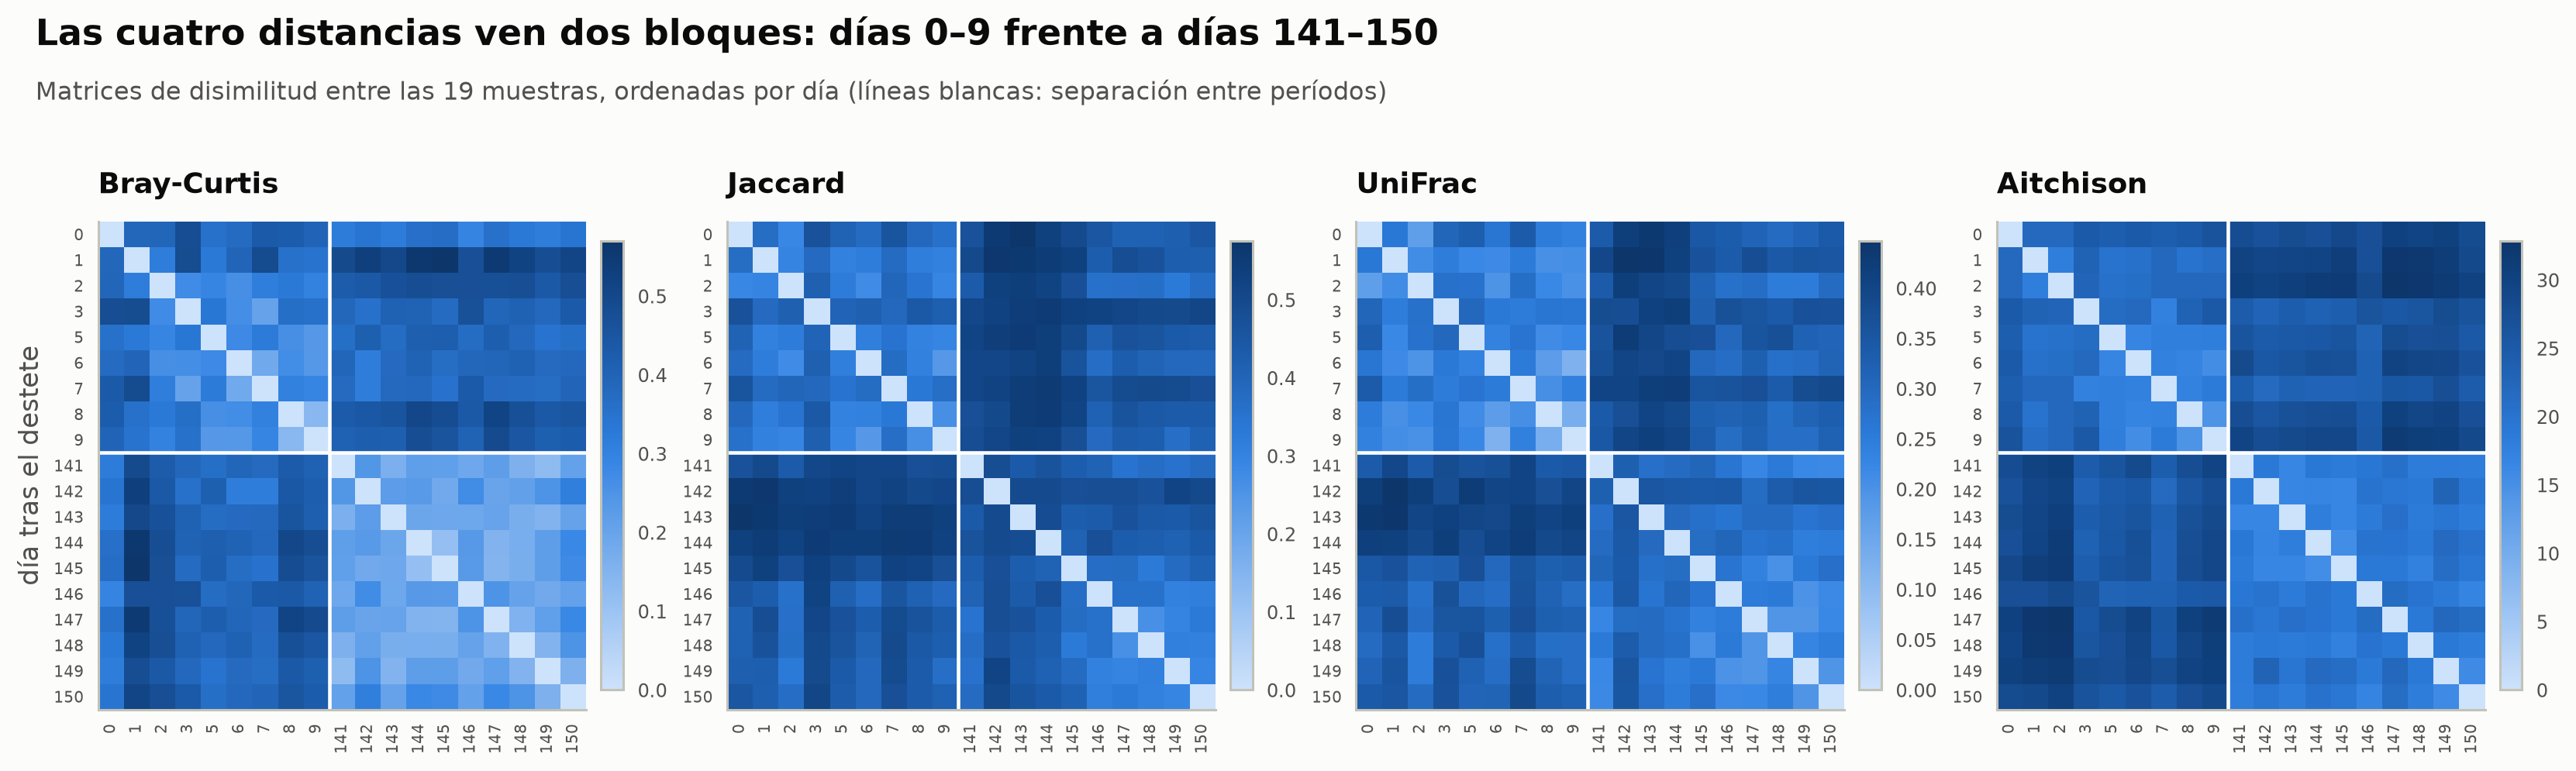

In [27]:
fig, axs = plt.subplots(1, 4, figsize=(15, 4.0))
ticks = [f"{d}" for d in meta.day_post_weaning]
for ax, (name, Dm_) in zip(axs, DM.items()):
    im = ax.imshow(Dm_, cmap=ec.CMAP_SEQ, interpolation="nearest"); ax.grid(False)
    ax.axhline(8.5, color="white", lw=1.5); ax.axvline(8.5, color="white", lw=1.5)
    ax.set_xticks(range(n), ticks, fontsize=6.5, rotation=90); ax.set_yticks(range(n), ticks, fontsize=6.5)
    ax.set_title(name, loc="left", fontsize=12, fontweight="bold")
    cb = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.03); cb.ax.tick_params(labelsize=8)
axs[0].set_ylabel("día tras el destete")
ec.fig_title(fig, "Las cuatro distancias ven dos bloques: días 0–9 frente a días 141–150",
             "Matrices de disimilitud entre las 19 muestras, ordenadas por día (líneas blancas: separación entre períodos)")
plt.show()

> 🔎 **Qué observamos.** En las cuatro matrices, el bloque inferior derecho (muestras tardías entre sí) es más claro:
> la comunidad adulta es **estable** de un día a otro, como describieron Schloss et al. (2012). El bloque superior
> izquierdo (días 0–9) es más heterogéneo: la comunidad temprana cambia día a día. Los valores absolutos difieren entre
> índices (Jaccard es alto porque cuenta cada ASV rara; UniFrac es menor porque las ASVs que no se comparten suelen
> tener parientes cercanos en la otra muestra), pero la **estructura** es la misma.

> ✅ **Compruebe su comprensión.** Dos muestras comparten todas sus ASVs, pero una está dominada por la ASV 1 y la otra
> por la ASV 2. ¿Qué valen, aproximadamente, Jaccard y Bray-Curtis? *(Jaccard = 0: los mismos taxones presentes;
> Bray-Curtis alto: las abundancias son muy distintas.)*

## 8. Ordenación por coordenadas principales (PCoA)

### 8.1 De una tabla de distancias a un mapa

Con $n$ muestras obtenemos una matriz $n\times n$ de distancias. Para **verla**, buscamos puntos en un plano cuyas
distancias euclidianas se parezcan lo más posible a las originales. Es el problema inverso de medir un mapa: si le dan
la tabla de kilómetros por carretera entre ciudades que aparece al final de una guía de viaje, ¿puede dibujar el mapa?
El análisis de coordenadas principales (PCoA, o escalamiento multidimensional clásico; Gower, 1966) lo hace mediante
una descomposición espectral.

> **Teorema (coordenadas principales).** Sea $\mathbf{D}$ la matriz de disimilitudes, $\mathbf{A} = -\tfrac12 [d_{kl}^2]$ y
> $\mathbf{J} = \mathbf{I} - \tfrac1n \mathbf{1}\mathbf{1}^{\top}$ la matriz de centrado. Sea
> $$\mathbf{B} = \mathbf{J}\mathbf{A}\mathbf{J} = \mathbf{V}\boldsymbol{\Lambda}\mathbf{V}^{\top}$$
> su descomposición espectral, con autovalores $\lambda_1 \ge \lambda_2 \ge \cdots$. Si $\mathbf{D}$ es euclidiana, las
> coordenadas $\mathbf{Y} = \mathbf{V}\boldsymbol{\Lambda}^{1/2}$ reproducen exactamente las distancias, y sus primeras
> $m$ columnas dan la mejor representación en $m$ dimensiones (mínimos cuadrados sobre $\mathbf{B}$). La fracción de
> variación representada por el eje $k$ es $\lambda_k / \sum_{j:\lambda_j>0}\lambda_j$.

| Símbolo | Significado |
|---|---|
| $d_{kl}$ | Disimilitud entre las muestras $k$ y $l$. |
| $\mathbf{J}$ | Matriz de centrado: resta la media de filas y columnas. |
| $\mathbf{B}$ | Matriz de productos escalares centrada («doble centrado» de Gower). |
| $\mathbf{V},\ \boldsymbol{\Lambda}$ | Autovectores y matriz diagonal de autovalores de $\mathbf{B}$. |
| $\mathbf{Y}$ | Coordenadas de las muestras en los ejes principales (PCo1, PCo2, …). |

**Por qué funciona.** Si las muestras fueran puntos $\mathbf{y}_k$ centrados en el origen,
$d_{kl}^2 = \|\mathbf{y}_k\|^2 + \|\mathbf{y}_l\|^2 - 2\,\mathbf{y}_k^{\top}\mathbf{y}_l$. El doble centrado elimina los
términos de norma y deja sólo los productos escalares $\mathbf{y}_k^{\top}\mathbf{y}_l$, es decir, $\mathbf B=\mathbf Y\mathbf Y^\top$. De
una matriz de productos escalares se recuperan las coordenadas por descomposición espectral, exactamente como en el
PCA (Lección 10.2). Cuando la disimilitud **no** es euclidiana, como Bray-Curtis, aparecen **autovalores negativos**:
no existe ninguna configuración de puntos que reproduzca las distancias. Si son pequeños, se ignoran; si son grandes,
conviene aplicar una corrección o usar otra distancia.

**Un ejemplo a mano.** Cuatro pueblos en las esquinas de un rectángulo de 3 × 4 km. Sólo conocemos sus distancias: 3
y 4 km por los lados y 5 km por las diagonales. ¿Recupera PCoA el rectángulo?

In [28]:
def pcoa(Dm):
    """PCoA desde cero (teorema de Gower). Devuelve coordenadas Y, autovalores y fracción explicada."""
    Dm = np.asarray(Dm, float); n = len(Dm)
    J = np.eye(n) - np.ones((n, n)) / n
    with np.errstate(all="ignore"):                  # evita avisos espurios de BLAS en algunas plataformas
        B = -0.5 * J @ (Dm ** 2) @ J
    ev, V = np.linalg.eigh(B)
    idx = np.argsort(ev)[::-1]; ev, V = ev[idx], V[:, idx]
    pos = ev > 1e-10
    Y = V[:, pos] * np.sqrt(ev[pos])
    return Y, ev, ev[pos] / ev[pos].sum()

towns = np.array([[0, 0], [4, 0], [4, 3], [0, 3]], float)
D_towns = squareform(pdist(towns))
print("Distancias conocidas (km):\n", D_towns)
Y_t, ev_t, prop_t = pcoa(D_towns)
print("Autovalores:", np.round(ev_t, 3), "· fracción explicada:", np.round(prop_t, 3))
print("Coordenadas PCoA:\n", np.round(Y_t, 3))
print("¿Reproducen las distancias?", np.allclose(squareform(pdist(Y_t)), D_towns))

Distancias conocidas (km):
 [[0. 4. 5. 3.]
 [4. 0. 3. 5.]
 [5. 3. 0. 4.]
 [3. 5. 4. 0.]]
Autovalores: [16.  9.  0. -0.] · fracción explicada: [0.64 0.36]
Coordenadas PCoA:
 [[-2.   1.5]
 [ 2.   1.5]
 [ 2.  -1.5]
 [-2.  -1.5]]
¿Reproducen las distancias? True


PCoA devuelve el rectángulo centrado en el origen (± 2 km en un eje, ± 1,5 km en el otro), con dos autovalores
positivos (16 y 9: el eje largo explica el 64 %) y el resto cero. Puede venir girado o reflejado: las distancias no
tienen «norte», así que el **signo de cada eje es arbitrario**.

### 8.2 La simulación del libro: sano, cambio de dieta y antibiótico

El libro simula 45 muestras de 60 taxones con 10 000 lecturas cada una: un perfil **sano** de referencia, un grupo con
**cambio de dieta** (abundancias perturbadas alrededor del perfil sano) y un grupo tratado con **antibiótico**, que
pierde sus ocho taxones más abundantes (se reducen al 8 %). Seguimos con el generador del libro exactamente donde lo
dejamos tras la rarefacción.

In [29]:
T = 60
base = rng_book.dirichlet(np.full(T, 0.4))
groups_book = {"sano": base, "dieta": rng_book.dirichlet(80 * base + 0.05), "antibiotico": None}
ab = base.copy(); ab[np.argsort(base)[-8:]] *= 0.08; ab = ab / ab.sum()
groups_book["antibiotico"] = ab
Xb, lab_b = [], []
for gname, pb in groups_book.items():
    for _ in range(15):
        pi = rng_book.dirichlet(60 * pb + 0.01)
        Xb.append(rng_book.multinomial(10000, pi) / 10000)
        lab_b.append(gname)
Xb = np.array(Xb); lab_b = np.array(lab_b)
D_book = squareform(pdist(Xb, "braycurtis"))
Y_b, ev_b, prop_b = pcoa(D_book)
# orientación como en la figura del libro: antibiótico a la izquierda en PCo1, dieta arriba en PCo2
if Y_b[lab_b == "antibiotico", 0].mean() > 0: Y_b[:, 0] *= -1
if Y_b[lab_b == "dieta", 1].mean() < Y_b[lab_b == "sano", 1].mean(): Y_b[:, 1] *= -1
neg = ev_b[ev_b < -1e-10]
print(f"[pcoa] var ejes: {prop_b[0]:.3f} {prop_b[1]:.3f}  autovalores negativos: {len(neg)} (mín {neg.min():.4f})")
for gname in groups_book:
    s = lab_b == gname
    print(f"[beta] BC medio dentro de {gname}: {D_book[np.ix_(s, s)][np.triu_indices(s.sum(), 1)].mean():.3f}")
print(f"[beta] BC medio sano-antibiótico: {D_book[np.ix_(lab_b == 'sano', lab_b == 'antibiotico')].mean():.3f}")

[pcoa] var ejes: 0.379 0.108  autovalores negativos: 13 (mín -0.0630)
[beta] BC medio dentro de sano: 0.363
[beta] BC medio dentro de dieta: 0.306
[beta] BC medio dentro de antibiotico: 0.395
[beta] BC medio sano-antibiótico: 0.580


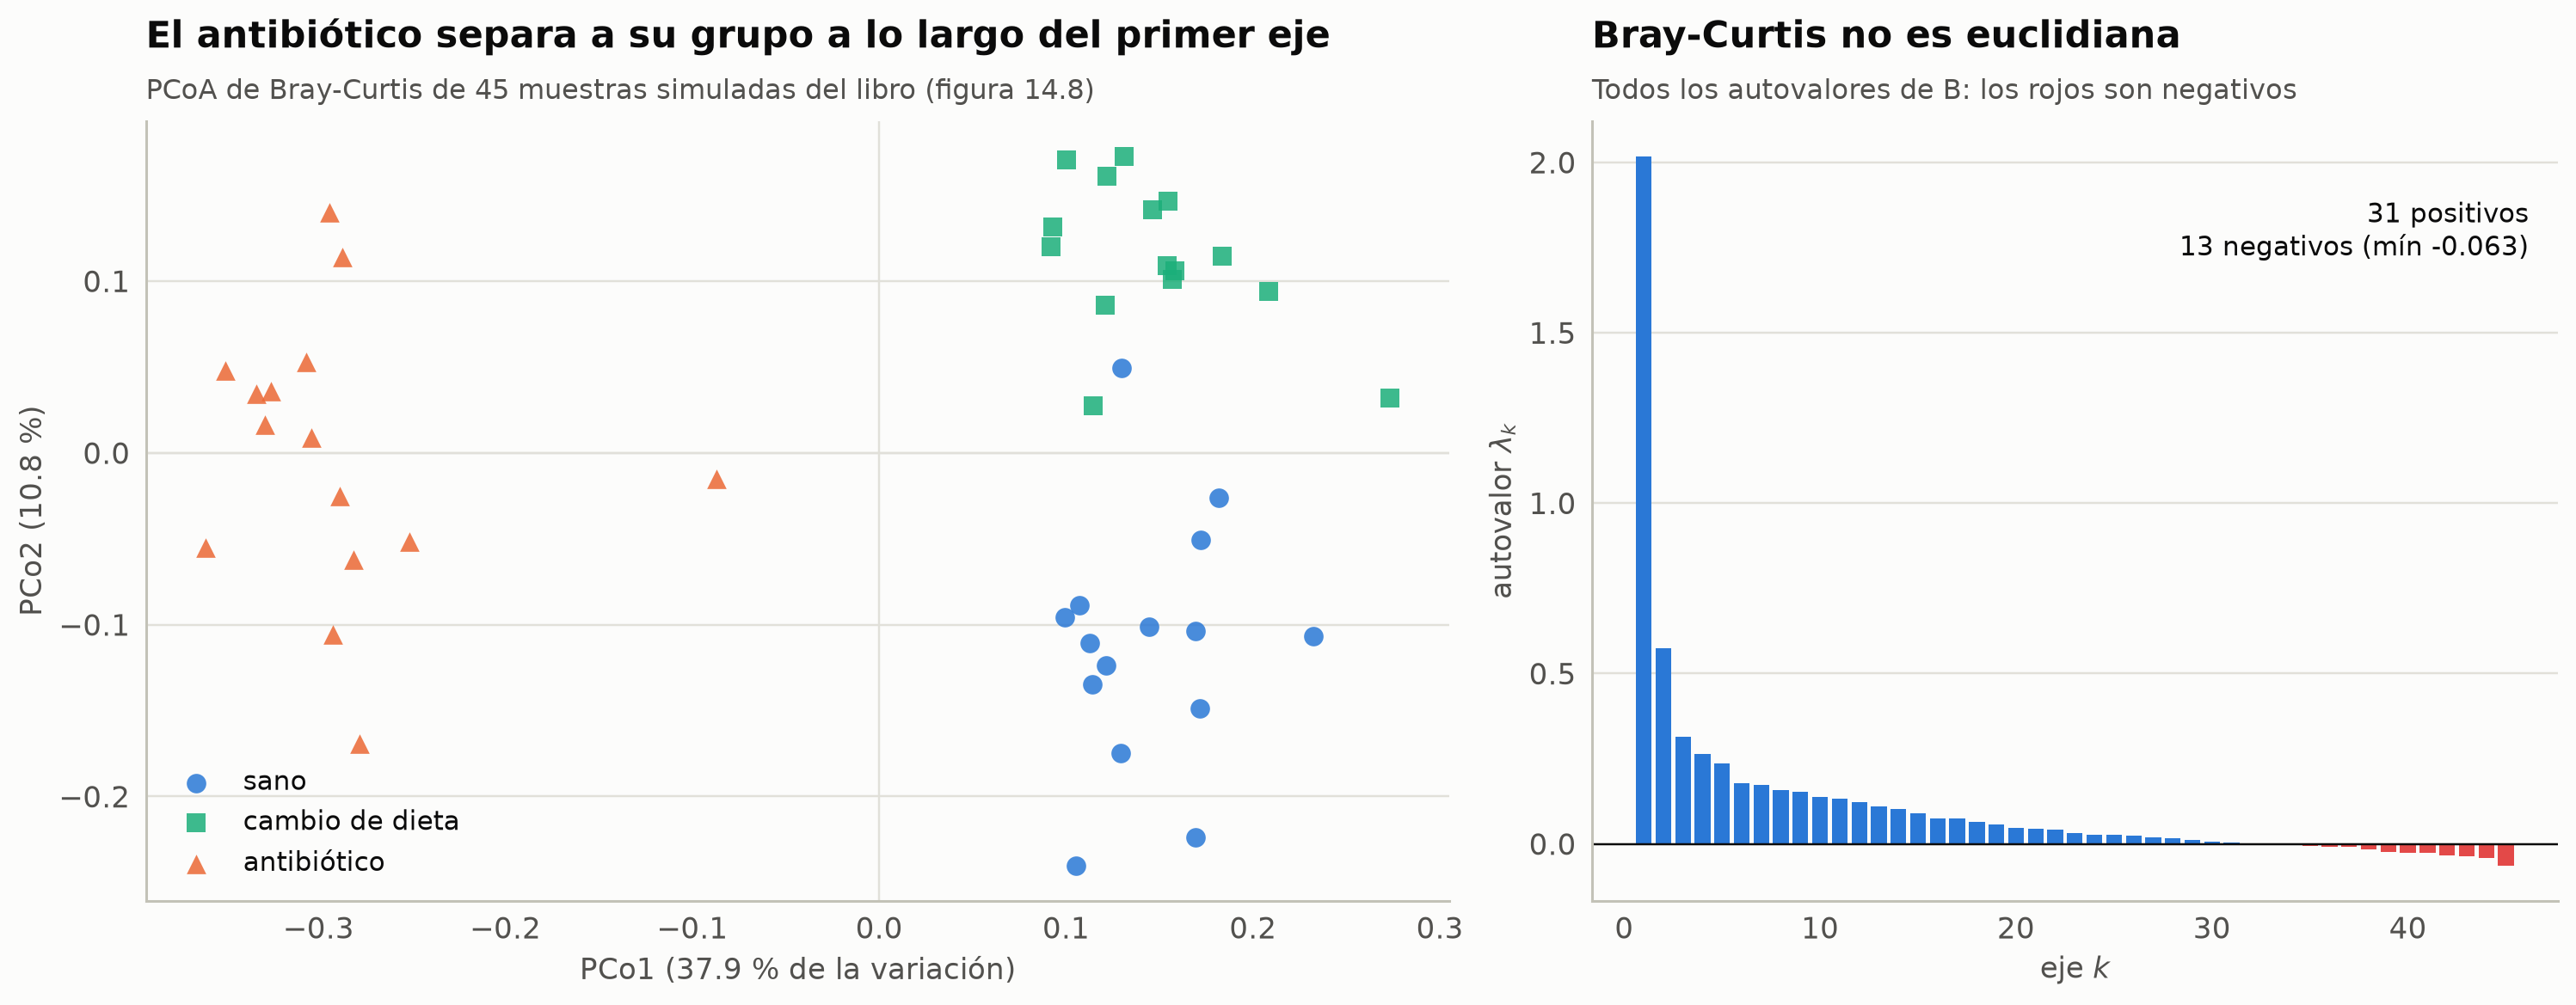

In [30]:
GCOL = {"sano": ec.BLUE, "dieta": ec.AQUA, "antibiotico": ec.ORANGE}
GNAME = {"sano": "sano", "dieta": "cambio de dieta", "antibiotico": "antibiótico"}
GMARK = {"sano": "o", "dieta": "s", "antibiotico": "^"}
fig, (ax, ax2) = plt.subplots(1, 2, figsize=(13.5, 5.2), gridspec_kw=dict(width_ratios=[1.35, 1]))
for gname in groups_book:
    s = lab_b == gname
    ax.scatter(Y_b[s, 0], Y_b[s, 1], s=55, marker=GMARK[gname], color=GCOL[gname], alpha=0.85, edgecolor="white",
               label=GNAME[gname])
ax.set_xlabel(f"PCo1 ({100 * prop_b[0]:.1f} % de la variación)"); ax.set_ylabel(f"PCo2 ({100 * prop_b[1]:.1f} %)")
ax.legend(frameon=False, loc="lower left")
ax.axhline(0, color=ec.GRID, lw=0.8, zorder=0); ax.axvline(0, color=ec.GRID, lw=0.8, zorder=0)
ec.title(ax, "El antibiótico separa a su grupo a lo largo del primer eje",
         "PCoA de Bray-Curtis de 45 muestras simuladas del libro (figura 14.8)")
kk = np.arange(1, len(ev_b) + 1)
ax2.bar(kk, ev_b, color=[ec.BLUE if e > 0 else ec.RED for e in ev_b], width=0.8)
ax2.axhline(0, color=ec.INK, lw=0.8)
ax2.set_xlabel("eje $k$"); ax2.set_ylabel(r"autovalor $\lambda_k$")
ax2.text(0.97, 0.9, f"{(ev_b > 1e-10).sum()} positivos\n{len(neg)} negativos (mín {neg.min():.3f})",
         transform=ax2.transAxes, ha="right", va="top", fontsize=10)
ec.title(ax2, "Bray-Curtis no es euclidiana", "Todos los autovalores de B: los rojos son negativos")
plt.show()

> 🔎 **Qué observamos.** Las cifras del libro: PCo1 explica el 37,9 % y PCo2 el 10,8 %, y hay **13 autovalores
> negativos** (el menor, −0,063). El grupo «antibiótico» se separa a lo largo del primer eje; «cambio de dieta» se
> solapa parcialmente con «sano» y se distingue sobre todo en PCo2. Los dos ejes juntos representan menos de la mitad
> de la variación, y los autovalores negativos recuerdan que ningún conjunto de puntos reproduce exactamente las
> distancias de Bray-Curtis: **el plano es una sombra de la estructura, no la estructura completa**.

### 8.3 🎛️ PCoA interactivo de la microbiota del ratón

Ahora con los datos reales, y con las cuatro distancias de la sección 7. Elija la distancia en el menú; pase el ratón
por un punto para ver la muestra, el día después del destete, su profundidad y su diversidad efectiva ${}^1D=e^H$.
Las líneas unen días consecutivos: son la **trayectoria** de la comunidad en el tiempo.

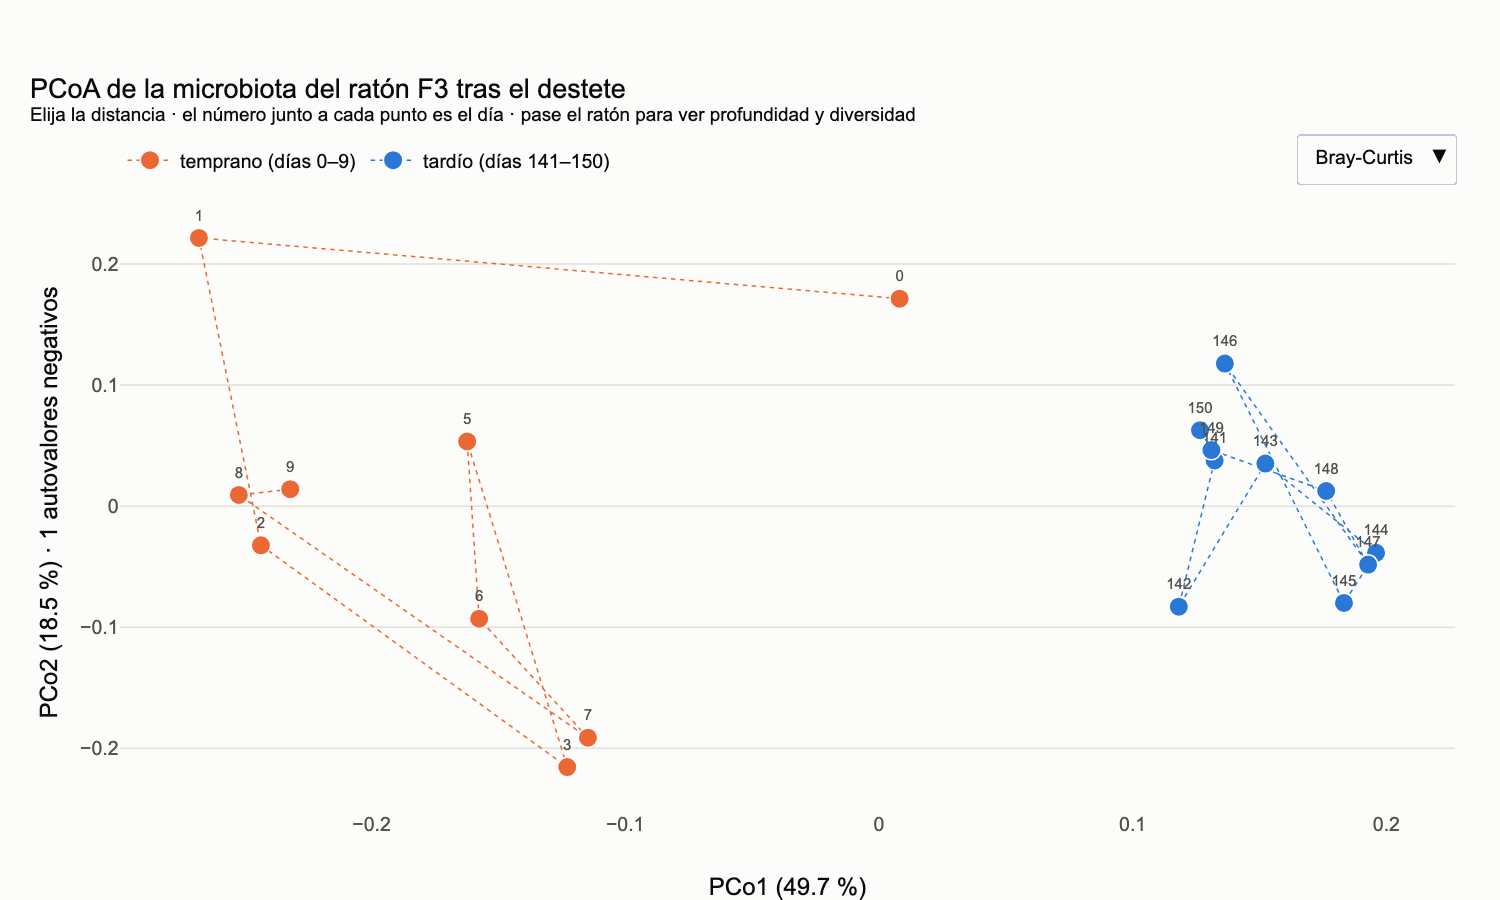

Bray-Curtis: PCo1 = 49.7% · PCo2 = 18.5% · autovalores negativos = 1
Jaccard    : PCo1 = 28.3% · PCo2 = 13.1% · autovalores negativos = 0
UniFrac    : PCo1 = 37.7% · PCo2 = 12.5% · autovalores negativos = 1
Aitchison  : PCo1 = 38.5% · PCo2 = 9.6% · autovalores negativos = 0


In [31]:
def oriented_pcoa(Dm):
    Y, ev, prop = pcoa(Dm)
    Y = Y[:, :2].copy()
    if Y[period == "early", 0].mean() > 0: Y[:, 0] *= -1        # temprano a la izquierda
    if Y[:, 1][np.argmin(meta.day_post_weaning.values)] < 0: Y[:, 1] *= -1   # día 0 arriba
    return Y, prop, (ev < -1e-10).sum()

PC_real = {name: oriented_pcoa(Dm_) for name, Dm_ in DM.items()}
e1 = np.exp(alpha.H.values)
fig = go.Figure()
names = list(DM)
for m, name in enumerate(names):
    Y, prop, nneg = PC_real[name]
    for per in ("early", "late"):
        s = np.where(period == per)[0]
        fig.add_trace(go.Scatter(
            x=Y[s, 0], y=Y[s, 1], mode="lines+markers+text", visible=(m == 0),
            name=PERIOD_NAMES[per], text=[str(d) for d in meta.day_post_weaning.values[s]], textposition="top center",
            textfont=dict(size=10, color=ec.INK_2),
            line=dict(color=PERIOD_COLORS[per], width=1, dash="dot"),
            marker=dict(size=13, color=PERIOD_COLORS[per], line=dict(color="white", width=1)),
            customdata=np.column_stack([np.array(samples)[s], meta.day_post_weaning.values[s], N_k[s], e1[s],
                                        alpha.S.values[s]]),
            hovertemplate=("<b>%{customdata[0]}</b> · día %{customdata[1]} tras el destete<br>"
                           f"{name}: PCo1 = %{{x:.3f}}, PCo2 = %{{y:.3f}}<br>"
                           "profundidad N_k = %{customdata[2]:,} lecturas<br>"
                           "riqueza S = %{customdata[4]} · diversidad efectiva e^H = %{customdata[3]:.1f} ASVs"
                           "<extra>" + PERIOD_NAMES[per] + "</extra>")))
buttons = []
for m, name in enumerate(names):
    Y, prop, nneg = PC_real[name]
    buttons.append(dict(label=name, method="update",
                        args=[{"visible": [i // 2 == m for i in range(2 * len(names))]},
                              {"xaxis.title.text": f"PCo1 ({100 * prop[0]:.1f} %)",
                               "yaxis.title.text": f"PCo2 ({100 * prop[1]:.1f} %) · {nneg} autovalores negativos"}]))
Y0, prop0, nneg0 = PC_real[names[0]]
fig.update_layout(
    updatemenus=[dict(buttons=buttons, direction="down", x=1.0, xanchor="right", y=1.02, yanchor="bottom")],
    title="PCoA de la microbiota del ratón F3 tras el destete"
          "<br><sup>Elija la distancia · el número junto a cada punto es el día · pase el ratón para ver profundidad y diversidad</sup>",
    xaxis_title=f"PCo1 ({100 * prop0[0]:.1f} %)", yaxis_title=f"PCo2 ({100 * prop0[1]:.1f} %) · {nneg0} autovalores negativos",
    height=600, width=900, margin=dict(t=130, l=80, r=30, b=60),
    legend=dict(orientation="h", yanchor="bottom", y=1.02, x=0))
fig.show()
for name in names:
    Y, prop, nneg = PC_real[name]
    print(f"{name:<11}: PCo1 = {prop[0]:.1%} · PCo2 = {prop[1]:.1%} · autovalores negativos = {nneg}")

> 🔎 **Qué observamos.** Con cualquiera de las cuatro distancias, las muestras tempranas y tardías ocupan regiones
> distintas del plano, separadas sobre todo por PCo1. Las tardías forman un grupo **compacto** (la comunidad adulta es
> estable), mientras que las tempranas se esparcen y su trayectoria recorre el plano día a día: la comunidad se
> reorganiza tras el destete. Bray-Curtis y UniFrac producen algún autovalor negativo (no son euclidianas; aquí son
> pocos y pequeños); Aitchison, que es una distancia euclidiana entre vectores clr, no produce ninguno, y Jaccard
> tampoco en estos datos.

> ✅ **Compruebe su comprensión.** ¿Por qué la distancia de Aitchison nunca da autovalores negativos en PCoA?
> *(Porque es la distancia euclidiana entre los vectores clr: existe una configuración de puntos —los propios vectores
> clr— que la reproduce exactamente, y entonces $\mathbf B$ es semidefinida positiva.)*

## 9. PERMANOVA: ¿difieren los grupos?

### 9.1 Un ANOVA que funciona con cualquier distancia

Una ordenación **sugiere**, pero no prueba. Para contrastar si la composición difiere entre grupos (sanos frente a
enfermos, dietas, tratamientos, días tempranos frente a tardíos) necesitamos un análisis de la varianza que funcione
con **cualquier** disimilitud. Anderson (2001) lo formuló a partir de una identidad clásica: la suma de cuadrados de
las distancias de los puntos a su centroide puede calcularse **sin conocer el centroide**, sólo con las distancias
entre pares:

$$
\sum_{k=1}^{n}\|\mathbf y_k-\bar{\mathbf y}\|^2=\frac1n\sum_{k<l}\|\mathbf y_k-\mathbf y_l\|^2 .
$$

Esto es crucial, porque con Bray-Curtis no sabemos qué sería un «centroide», pero sí sabemos calcular $d_{kl}$.

> **Teorema (pseudo-$F$ de PERMANOVA).** Sean $N$ muestras repartidas en $a$ grupos de tamaño $n$, y sea
> $\varepsilon_{kl}=1$ si $k$ y $l$ pertenecen al mismo grupo (0 en otro caso). Con
> $$SS_T = \frac{1}{N}\sum_{k<l} d_{kl}^2, \qquad SS_W = \frac{1}{n}\sum_{k<l} d_{kl}^2\,\varepsilon_{kl}, \qquad SS_A = SS_T - SS_W,$$
> el estadístico
> $$F = \frac{SS_A/(a-1)}{SS_W/(N-a)}$$
> se compara con su distribución bajo la hipótesis nula de «grupos intercambiables», obtenida **permutando las
> etiquetas** de grupo. El valor $p$ es $(\#\{F^{*} \ge F\} + 1)/(P+1)$ para $P$ permutaciones.

| Símbolo | Significado |
|---|---|
| $SS_T,\ SS_W,\ SS_A$ | Sumas de cuadrados total, dentro de los grupos y entre grupos. |
| $\varepsilon_{kl}$ | Indicador de que las muestras $k$ y $l$ pertenecen al mismo grupo. |
| $F^{*}$ | Valor del estadístico en un conjunto de datos con etiquetas permutadas. |
| $P$ | Número de permutaciones (típicamente 999). |
| $R^2=SS_A/SS_T$ | Fracción de la variación total explicada por los grupos. |

Con grupos de tamaños distintos, cada grupo usa su propio tamaño: $SS_W=\sum_g \frac1{n_g}\sum_{k<l\in g}d_{kl}^2$ (es
lo que programamos). Con la distancia euclidiana, este $F$ coincide con el del ANOVA clásico; con cualquier otra
disimilitud conserva la lógica pero pierde la distribución $F$ de Fisher, y por eso se recurre a permutaciones. El
«$+1$» del valor $p$ cuenta los datos observados como una permutación más: con 999 permutaciones, el menor $p$ posible
es $1/1000=0{,}001$.

Comprobemos primero la identidad y la equivalencia con el ANOVA clásico en una dimensión:

In [32]:
from scipy import stats

def permanova(Dm, g, perms=999, rng=None, return_null=False):
    """PERMANOVA de Anderson (2001) desde cero: pseudo-F, p por permutaciones y R²."""
    Dm = np.asarray(Dm, float); g = np.asarray(g)
    N = len(g); levels = np.unique(g); a = len(levels)
    D2 = Dm ** 2
    SST = D2[np.triu_indices(N, 1)].sum() / N

    def ssw(gg):
        G = (gg[:, None] == levels[None, :]).astype(float)          # indicadora muestra × grupo
        within = np.einsum("kg,kl,lg->g", G, D2, G) / 2               # Σ_{k<l} d² dentro de cada grupo
        return (within / G.sum(0)).sum()

    W = ssw(g)
    F = ((SST - W) / (a - 1)) / (W / (N - a))
    Fs, perm_labels = np.empty(perms), []
    for t in range(perms):
        gp = rng.permutation(g)
        Wp = ssw(gp)
        Fs[t] = ((SST - Wp) / (a - 1)) / (Wp / (N - a))
        if return_null:
            perm_labels.append(gp)
    p = ((Fs >= F).sum() + 1) / (perms + 1)
    out = dict(F=F, p=p, R2=1 - W / SST, SST=SST, SSW=W)
    if return_null:
        out.update(null=Fs, perm_labels=perm_labels)
    return out

# Identidad: suma de cuadrados al centroide = (1/n) Σ_{k<l} d²
pts = rng_nb.normal(size=(12, 3))
lhs = ((pts - pts.mean(0)) ** 2).sum(); rhs = (pdist(pts) ** 2).sum() / len(pts)
print(f"Σ‖y_k − ȳ‖² = {lhs:.4f}   ·   (1/n)Σ_(k<l) d²_kl = {rhs:.4f}")
# Equivalencia con el ANOVA de una vía (distancia euclidiana en 1-D)
yv = np.concatenate([rng_nb.normal(0, 1, 10), rng_nb.normal(1, 1, 10), rng_nb.normal(0.5, 1, 10)])
gv = np.repeat(["a", "b", "c"], 10)
res = permanova(squareform(pdist(yv[:, None])), gv, perms=199, rng=rng_nb)
print(f"PERMANOVA euclidiana: F = {res['F']:.4f}   ·   ANOVA clásico: F = {stats.f_oneway(yv[:10], yv[10:20], yv[20:]).statistic:.4f}")

Σ‖y_k − ȳ‖² = 28.4207   ·   (1/n)Σ_(k<l) d²_kl = 28.4207
PERMANOVA euclidiana: F = 2.4324   ·   ANOVA clásico: F = 2.4324


Ambas identidades se cumplen al pie de la letra. Ahora, el contraste de la simulación del libro (sano, dieta,
antibiótico). Las permutaciones consumen el generador del libro en el mismo orden que su script:

In [33]:
res_book = permanova(D_book, lab_b, perms=999, rng=rng_book)
print(f"[permanova] SST={res_book['SST']:.4f} SSW={res_book['SSW']:.4f} F={res_book['F']:.2f} "
      f"R2={res_book['R2']:.3f} p={res_book['p']:.3f}")

[permanova] SST=5.0365 SSW=2.7158 F=17.94 R2=0.461 p=0.001


> 🔎 **Qué observamos.** Las cifras del libro: pseudo-$F=17{,}9$, $R^2=0{,}46$ y $p=0{,}001$, el mínimo posible con
> 999 permutaciones: ninguna de las 999 reasignaciones aleatorias de etiquetas produjo un $F^*$ tan grande. Los tres
> grupos explican el 46 % de la variación de Bray-Curtis.

### 9.2 El ratón: ¿difieren los días tempranos de los tardíos?

> 🤔 **Antes de ejecutar, prediga.** Mirando el PCoA interactivo, ¿cree que PERMANOVA será significativo con las
> cuatro distancias? ¿Con cuál espera el $R^2$ más alto?

In [34]:
rows = []
for name, Dm_ in DM.items():
    r = permanova(Dm_, period, perms=999, rng=rng_nb, return_null=(name == "Bray-Curtis"))
    if name == "Bray-Curtis":
        res_bc = r
    rows.append(dict(distancia=name, pseudo_F=round(r["F"], 2), R2=round(r["R2"], 3), p=r["p"]))
perm_table = pd.DataFrame(rows).set_index("distancia")
perm_table

,pseudo_F,R2,p
distancia,,,
Bray-Curtis,13.39,0.441,0.001
Jaccard,6.23,0.268,0.001
UniFrac,9.41,0.356,0.001
Aitchison,9.67,0.363,0.001


> 🔎 **Qué observamos.** Con las cuatro distancias, $p=0{,}001$: ninguna permutación de las etiquetas temprano/tardío
> se acerca a la separación observada. El período explica alrededor del 44 % de la variación de Bray-Curtis y bastante
> menos con Jaccard (27 %), que da tanto peso a las ASVs raras (más ruidosas) como a las dominantes. El resultado coincide con
> el del tutorial original de mothur, que encontró la misma diferencia con otra prueba basada en distancias (AMOVA).

### 9.3 🎬 Qué hace una permutación

La animación muestra el procedimiento: en cada cuadro barajamos las etiquetas «temprano/tardío» entre las 19
muestras (los puntos no se mueven, sólo cambia su color), recalculamos el pseudo-$F$ y lo añadimos al histograma de la
distribución nula. La línea vertical es el $F$ observado.

![Cada cuadro baraja las etiquetas temprano/tardío de las 19 muestras y añade el pseudo-F resultante al histograma: ninguna de las 999 permutaciones alcanza al F observado](https://raw.githubusercontent.com/juvenalyosa/bioinformatica-practica/main/assets/modulo-14-metagenomica/14.2_permanova_permutaciones.gif)

*Cada cuadro baraja las etiquetas temprano/tardío de las 19 muestras y añade el pseudo-F resultante al histograma: ninguna de las 999 permutaciones alcanza al F observado*

In [35]:
Ybc = PC_real["Bray-Curtis"][0]
null = res_bc["null"]; F_obs = res_bc["F"]
FR_p = np.unique(np.concatenate([np.arange(1, 31), np.geomspace(31, 999, 26).astype(int)]))   # ≤ 60 cuadros
bins = np.linspace(0, max(null.max(), F_obs) * 1.08, 45)

fig = plt.figure(figsize=(12.5, 5.2))
fig.get_layout_engine().set(rect=(0, 0, 1, 0.86))
gs = fig.add_gridspec(1, 2, width_ratios=[1, 1.25])
ax = fig.add_subplot(gs[0]); axh = fig.add_subplot(gs[1])
sc = ax.scatter(Ybc[:, 0], Ybc[:, 1], s=90, c=[PERIOD_COLORS[p_] for p_ in period], edgecolor="white", lw=1)
ax.set_xlabel("PCo1 (Bray-Curtis)"); ax.set_ylabel("PCo2")
ax.set_ylim(Ybc[:, 1].min() - 0.03, Ybc[:, 1].max() + 0.12)          # espacio para el texto
ltxt = ax.text(0.02, 0.97, "", transform=ax.transAxes, va="top", fontsize=10.5, color=ec.INK)
for per in ("early", "late"):
    ax.scatter([], [], color=PERIOD_COLORS[per], label=PERIOD_NAMES[per])
ax.legend(frameon=False, loc="lower right", fontsize=9)
axh.axvline(F_obs, color=ec.RED, lw=2)
axh.text(F_obs, 0.03, f"F observado = {F_obs:.1f} ", color=ec.RED, fontsize=10.5, va="bottom", ha="right",
         rotation=90, transform=axh.get_xaxis_transform())
axh.set_xlim(bins[0], bins[-1]); axh.set_xlabel("pseudo-$F^*$ con etiquetas permutadas"); axh.set_ylabel("permutaciones")
ymax = np.histogram(null, bins)[0].max() * 1.1
axh.set_ylim(0, ymax)
htxt = axh.text(0.86, 0.95, "", transform=axh.transAxes, ha="right", va="top", fontsize=10.5, color=ec.INK)
bars_h = axh.bar(bins[:-1], np.zeros(len(bins) - 1), width=np.diff(bins), align="edge", color=ec.VIOLET, alpha=0.8)
fig.text(0.01, 0.985, "PERMANOVA: si las etiquetas no importaran, F sería tan pequeño como en las permutaciones",
         fontsize=14.5, fontweight="bold", color=ec.INK, va="top")
fig.text(0.01, 0.935, "Izquierda: PCoA de Bray-Curtis con las etiquetas barajadas (los puntos no se mueven). "
         "Derecha: distribución nula de F* acumulada", fontsize=10.5, color=ec.INK_2, va="top")

def update(f):
    t = FR_p[f]
    lab_now = res_bc["perm_labels"][t - 1]                        # etiquetas de la permutación t
    sc.set_color([PERIOD_COLORS[p_] for p_ in lab_now])
    sc.set_edgecolor("white")
    h = np.histogram(null[:t], bins)[0]
    for b, v in zip(bars_h, h):
        b.set_height(v)
    ltxt.set_text(f"permutación {t}\nF* = {null[t - 1]:.2f}")
    htxt.set_text(f"{t} permutaciones\nF* ≥ F observado: {(null[:t] >= F_obs).sum()}\n"
                  f"p = ({(null[:t] >= F_obs).sum()} + 1)/({t} + 1) = {((null[:t] >= F_obs).sum() + 1) / (t + 1):.3f}")
    return []

fig.canvas.draw()
with plt.rc_context({"savefig.bbox": None}):
    anim_html = ec.animate(fig, update, frames=len(FR_p), interval=180, name="14.2_permanova_permutaciones")
anim_html

▶️ Ejecute esta celda para ver la animación con controles (la vista previa GIF está en la celda de texto de arriba).

> 🔎 **Qué observamos.** Con las etiquetas barajadas, los colores quedan mezclados por todo el plano y el pseudo-$F^*$
> rara vez supera 3–4; la distribución nula se acumula lejos del $F$ observado. El valor $p$ baja a medida que
> acumulamos permutaciones hasta el mínimo posible, $1/1000$. Fíjese en que las permutaciones **no suponen ninguna
> distribución**: la nula se construye con los propios datos.

### 9.4 El punto débil: dispersión frente a posición (PERMDISP)

PERMANOVA es sensible tanto a diferencias de **posición** (centroides) como de **dispersión**. Si un grupo es mucho
más variable que otro, puede dar significativo aunque los centroides coincidan, sobre todo con grupos de tamaño
desigual. Lo comprobamos por simulación: dos grupos con **el mismo centroide**, uno compacto (40 muestras, desviación
1) y otro disperso (10 muestras, desviación 4). Bajo la hipótesis nula «mismo centroide», una prueba honesta debería
rechazar el 5 % de las veces.

In [36]:
def permdisp(Dm, g, perms=999, rng=None):
    """PERMDISP (Anderson, 2006), versión simplificada: distancias al centroide de cada grupo en el espacio PCoA
    (ejes con autovalor positivo) y ANOVA de esas distancias con p por permutaciones."""
    Y, _, _ = pcoa(Dm); g = np.asarray(g)
    z = np.empty(len(g))
    for lv in np.unique(g):
        s = g == lv
        z[s] = np.linalg.norm(Y[s] - Y[s].mean(0), axis=1)
    groups_z = lambda gg: [z[gg == lv] for lv in np.unique(g)]
    F = stats.f_oneway(*groups_z(g)).statistic
    Fs = np.array([stats.f_oneway(*groups_z(rng.permutation(g))).statistic for _ in range(perms)])
    return dict(F=F, p=((Fs >= F).sum() + 1) / (perms + 1), mean_dist={lv: z[g == lv].mean() for lv in np.unique(g)})

designs = {"40 compactas + 10 dispersas": (40, 10), "10 compactas + 40 dispersas": (10, 40), "25 + 25": (25, 25)}
sim_rows = []
for name, (n1, n2) in designs.items():
    rej = []
    for r in range(100):
        Xs = np.vstack([rng_nb.normal(0, 1, (n1, 5)), rng_nb.normal(0, 4, (n2, 5))])
        gs_ = np.array(["compacto"] * n1 + ["disperso"] * n2)
        rej.append(permanova(squareform(pdist(Xs)), gs_, perms=199, rng=rng_nb)["p"] < 0.05)
    sim_rows.append(dict(diseño=name, rechazo_PERMANOVA=np.mean(rej)))
sim_table = pd.DataFrame(sim_rows).set_index("diseño")
print("Mismo centroide, distinta dispersión: fracción de simulaciones con p < 0,05 (debería ser ≈ 0,05)")
print(sim_table)

Mismo centroide, distinta dispersión: fracción de simulaciones con p < 0,05 (debería ser ≈ 0,05)
                             rechazo_PERMANOVA
diseño                                        
40 compactas + 10 dispersas               0.59
10 compactas + 40 dispersas               0.00
25 + 25                                   0.08


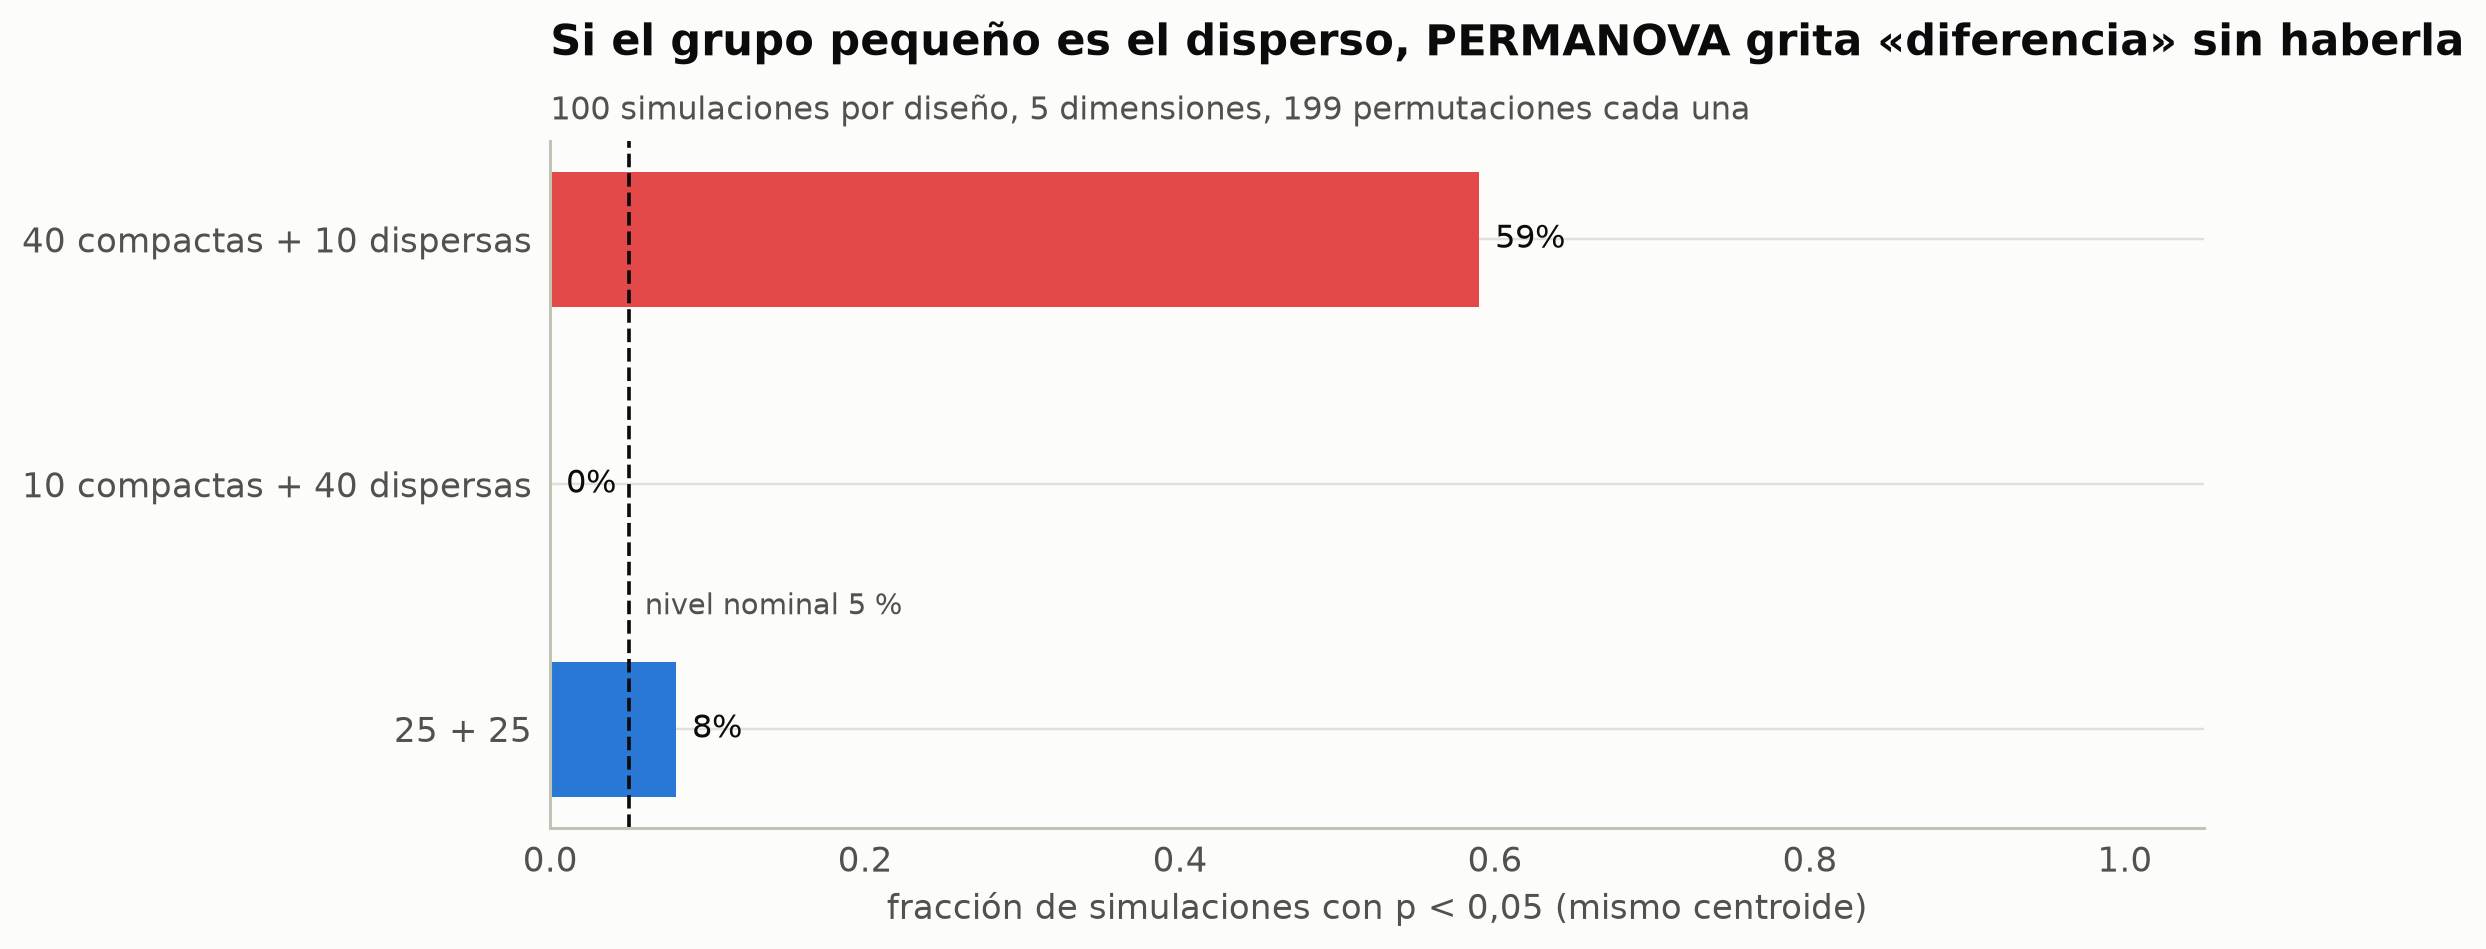

PERMDISP en el ratón (Bray-Curtis): F = 16.55, p = 0.001; distancia media al centroide: temprano (días 0–9) = 0.218, tardío (días 141–150) = 0.137


In [37]:
fig, ax = plt.subplots(figsize=(10, 4.2))
yy = np.arange(len(sim_table))
ax.barh(yy, sim_table.rechazo_PERMANOVA, color=[ec.RED if v > 0.1 else ec.BLUE for v in sim_table.rechazo_PERMANOVA],
        height=0.55)
ax.axvline(0.05, color=ec.INK, ls="--", lw=1.2); ax.text(0.06, 1.5, "nivel nominal 5 %", fontsize=9.5, va="center", color=ec.INK_2)
for y_, v in zip(yy, sim_table.rechazo_PERMANOVA):
    ax.text(v + 0.01, y_, f"{v:.0%}", va="center", fontsize=10.5)
ax.set_yticks(yy, sim_table.index); ax.set_xlim(0, 1.05); ax.invert_yaxis()
ax.set_xlabel("fracción de simulaciones con p < 0,05 (mismo centroide)")
ec.title(ax, "Si el grupo pequeño es el disperso, PERMANOVA grita «diferencia» sin haberla",
         "100 simulaciones por diseño, 5 dimensiones, 199 permutaciones cada una")
plt.show()

rd = permdisp(DM["Bray-Curtis"], period, perms=999, rng=rng_nb)
print(f"PERMDISP en el ratón (Bray-Curtis): F = {rd['F']:.2f}, p = {rd['p']:.3f}; distancia media al centroide: "
      + ", ".join(f"{PERIOD_NAMES[k]} = {v:.3f}" for k, v in rd["mean_dist"].items()))

> 🔎 **Qué observamos.** Con grupos equilibrados, PERMANOVA rechaza cerca del 5 % nominal (con 100 simulaciones, el
> 8 % observado es compatible con ese valor); cuando el grupo grande es el disperso, es conservadora (casi nunca
> rechaza). Pero con 40 muestras compactas y 10 dispersas, rechaza la hipótesis nula en más de la mitad de las
> simulaciones **aunque los centroides sean idénticos**. Por eso el libro recomienda acompañar PERMANOVA de una prueba
> de homogeneidad de dispersiones (**PERMDISP**, Anderson 2006) y de la inspección visual de la ordenación.

> En el ratón, PERMDISP **es** significativo: las muestras tempranas están, en promedio, a 0,22 de su centroide y las
> tardías a 0,14 (lo que ya sugería el PCoA). Parte del $F$ de PERMANOVA puede deberse a la dispersión; aun así, en el PCoA los
> centroides están claramente separados a lo largo de PCo1, y los grupos tienen tamaños parecidos (9 y 10), el
> escenario en que PERMANOVA es más robusto. Ambas cosas son biológicamente reales: la comunidad **cambia de lugar** y,
> además, se vuelve **más estable**.

> ✅ **Compruebe su comprensión.** Un estudio compara 60 controles sanos (comunidades parecidas entre sí) con 12
> pacientes tras antibióticos (comunidades muy distintas entre sí). PERMANOVA da $p=0{,}001$. ¿Qué análisis añadiría
> antes de concluir que «los antibióticos desplazan la comunidad hacia un estado concreto»? *(PERMDISP y el PCoA: con
> el grupo pequeño disperso, PERMANOVA puede ser significativo sólo por dispersión. Quizá cada paciente se desplaza en
> una dirección distinta: la «hipótesis de Anna Karenina» de las comunidades alteradas.)*

## 10. Caso real completo: ¿cambia la microbiota del ratón después del destete?

Reunimos las piezas en un solo análisis, como lo haríamos en un informe:

1. **Profundidad.** Las muestras tienen entre 2 567 y 16 100 lecturas; la riqueza sin corregir se correlaciona con la
   profundidad, así que para la riqueza usamos la rarefacción exacta.
2. **Diversidad alfa.** A igual profundidad, la riqueza de ambos períodos es parecida; los órdenes $q=1$ y $q=2$
   muestran una comunidad temprana más equitativa.
3. **Diversidad beta.** Cuatro distancias, PCoA y PERMANOVA coinciden: la composición cambia entre períodos.
4. **Estabilización.** ¿Se acerca la comunidad temprana, día a día, a la adulta? Medimos la disimilitud de
   Bray-Curtis media de cada muestra a las muestras tardías.

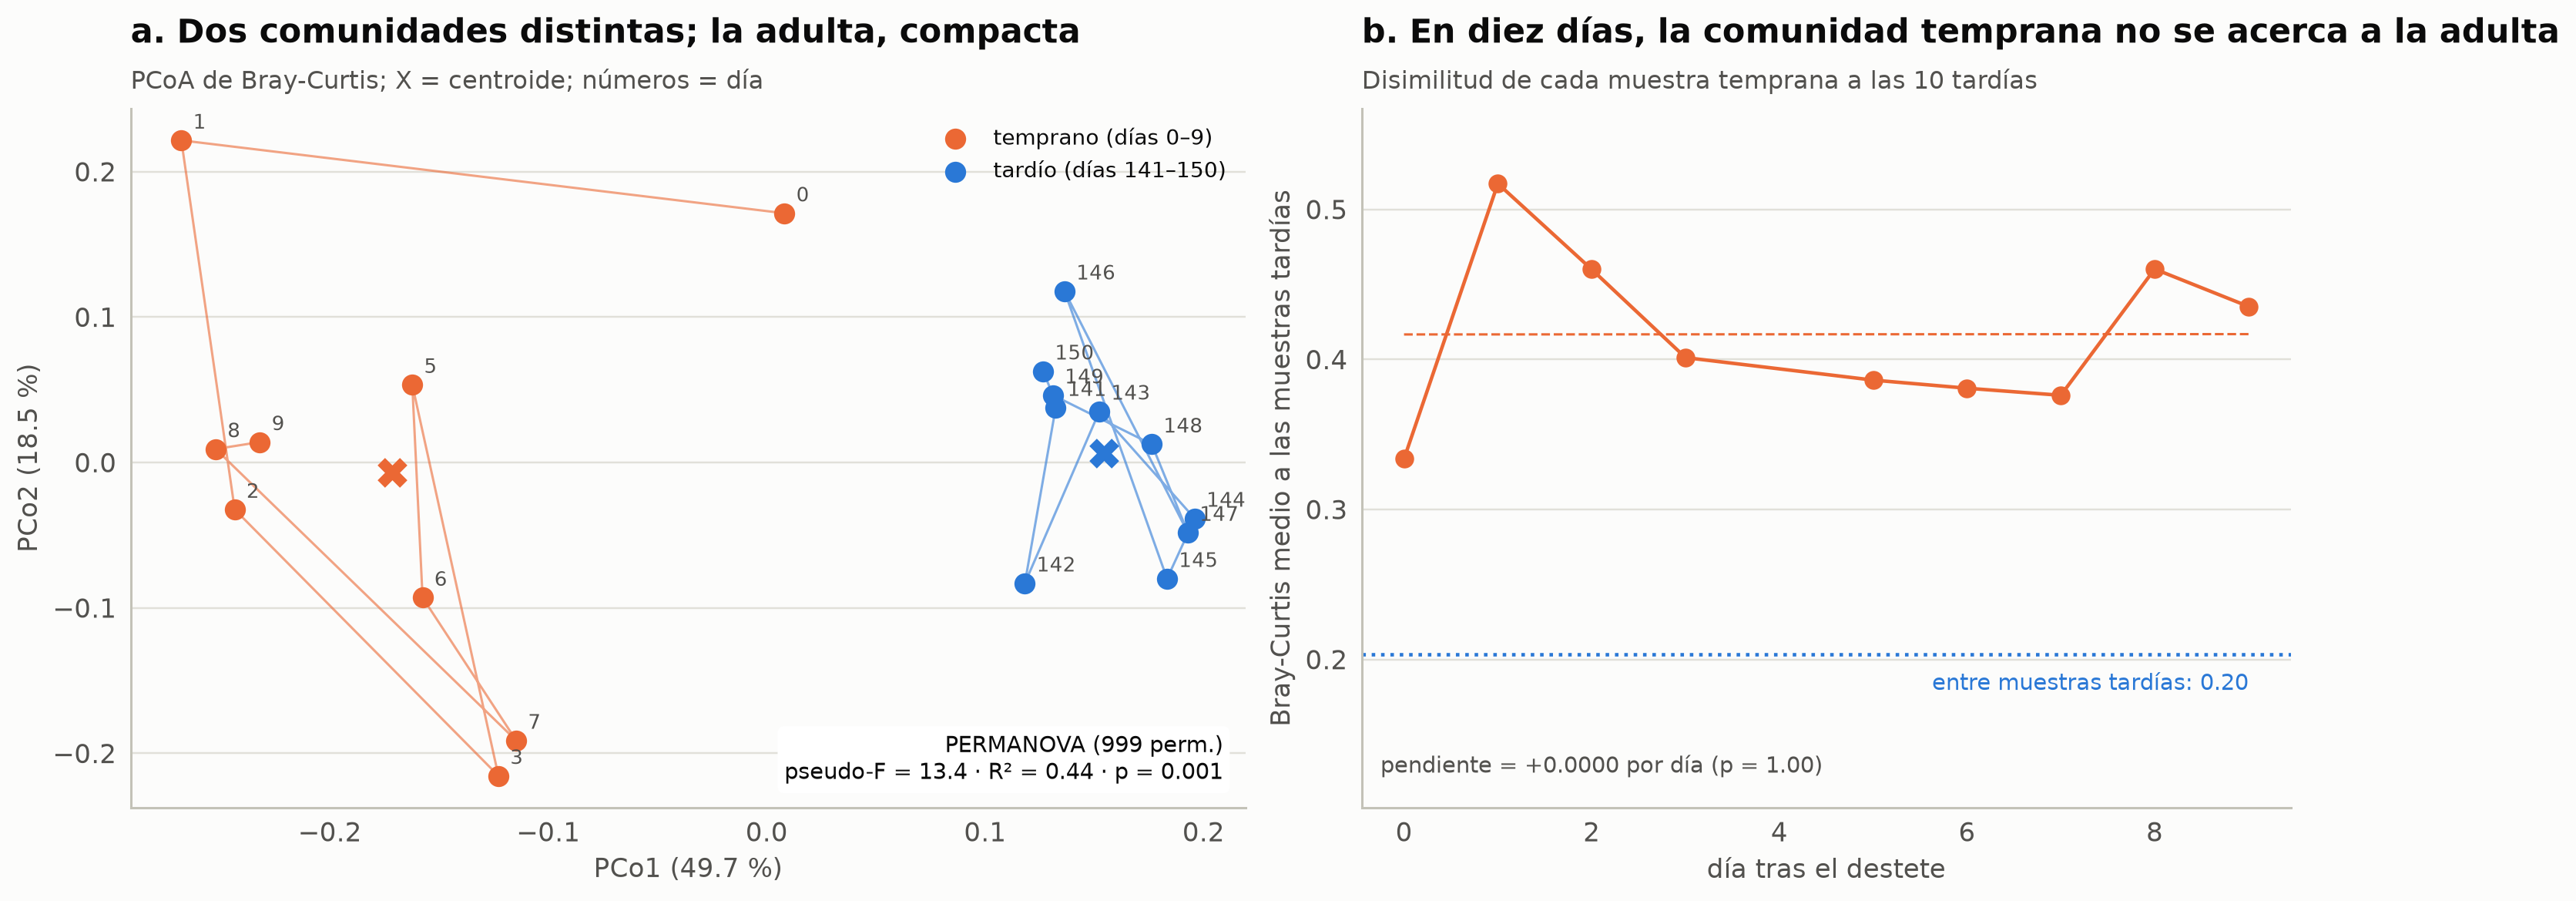

In [38]:
late_idx = np.where(period == "late")[0]
D_bc = DM["Bray-Curtis"]
to_late = np.array([np.mean([D_bc[k, j] for j in late_idx if j != k]) for k in range(len(samples))])
days = meta.day_post_weaning.values
Ybc = PC_real["Bray-Curtis"][0]; prop_bc = PC_real["Bray-Curtis"][1]

fig, (ax, ax2) = plt.subplots(1, 2, figsize=(13.5, 5.2), gridspec_kw=dict(width_ratios=[1.2, 1]))
for per in ("early", "late"):
    s = np.where(period == per)[0]
    s = s[np.argsort(days[s])]
    ax.plot(Ybc[s, 0], Ybc[s, 1], color=PERIOD_COLORS[per], lw=1, alpha=0.6, zorder=1)
    ax.scatter(Ybc[s, 0], Ybc[s, 1], s=80, color=PERIOD_COLORS[per], edgecolor="white", zorder=2, label=PERIOD_NAMES[per])
    for k in s:
        ax.annotate(str(days[k]), (Ybc[k, 0], Ybc[k, 1]), xytext=(5, 5), textcoords="offset points", fontsize=8.5,
                    color=ec.INK_2)
    c = Ybc[s].mean(0)
    ax.scatter(*c, marker="X", s=160, color=PERIOD_COLORS[per], edgecolor=ec.INK, zorder=3)
ax.set_xlabel(f"PCo1 ({100 * prop_bc[0]:.1f} %)"); ax.set_ylabel(f"PCo2 ({100 * prop_bc[1]:.1f} %)")
r = perm_table.loc["Bray-Curtis"]
ax.text(0.98, 0.03, f"PERMANOVA (999 perm.)\npseudo-F = {r.pseudo_F:.1f} · R² = {r.R2:.2f} · p = {r.p:.3f}",
        transform=ax.transAxes, ha="right", va="bottom", fontsize=9.5, bbox=dict(boxstyle="round", fc="white", ec=ec.GRID))
ax.legend(frameon=False, loc="upper right", fontsize=9)
ec.title(ax, "a. Dos comunidades distintas; la adulta, compacta", "PCoA de Bray-Curtis; X = centroide; números = día")
early_idx = np.where(period == "early")[0]
ax2.plot(days[early_idx], to_late[early_idx], "o-", color=ec.ORANGE, lw=1.5, ms=7, label="días 0–9")
sl = stats.linregress(days[early_idx], to_late[early_idx])
xx = np.array([0, 9]); ax2.plot(xx, sl.intercept + sl.slope * xx, color=ec.ORANGE, ls="--", lw=1)
wl = to_late[late_idx].mean()
ax2.axhline(wl, color=ec.BLUE, lw=1.5, ls=":")
ax2.text(9, wl - 0.012, f"entre muestras tardías: {wl:.2f}", ha="right", va="top", fontsize=9.5, color=ec.BLUE)
ax2.set_xlabel("día tras el destete"); ax2.set_ylabel("Bray-Curtis medio a las muestras tardías")
ax2.set_ylim(min(to_late.min(), wl) - 0.08, to_late.max() + 0.05)
ax2.text(0.02, 0.05, f"pendiente = {sl.slope:+.4f} por día (p = {sl.pvalue:.2f})", transform=ax2.transAxes, fontsize=9.5,
         color=ec.INK_2)
ec.title(ax2, "b. En diez días, la comunidad temprana no se acerca a la adulta", "Disimilitud de cada muestra temprana a las 10 tardías")
plt.show()

> 🔎 **Qué observamos.** (a) La comunidad adulta ocupa una región pequeña del plano: de un día a otro apenas cambia.
> La temprana se mueve mucho y está lejos de la adulta. (b) La disimilitud de las muestras tempranas a las tardías (≈ 0,33–0,52)
> es el doble que la que hay entre dos muestras tardías (≈ 0,20), y **no disminuye** a lo largo de los días 0–9
> (pendiente prácticamente nula): la comunidad temprana fluctúa, pero todavía no converge hacia la adulta. Curiosamente,
> el día 0, recién destetado, es el más parecido a la comunidad adulta; el día 1 ya es muy distinto. El estudio completo
> de Schloss et al. (2012), con muchos más días y ratones, describió una fase inicial dinámica seguida de una comunidad
> estable: nuestro subconjunto de un solo ratón muestra sus dos extremos, no la transición.

**Conclusión del informe.** En la hembra F3, la microbiota intestinal de los días 0–9 tras el destete difiere de la de
los días 141–150 (PERMANOVA, $p=0{,}001$ con cuatro distancias; $R^2\approx0{,}44$ con Bray-Curtis). La diferencia
no es de riqueza (a igual profundidad, ambas tienen unas 175 ASVs) sino de **composición** y de **equidad**: la
comunidad adulta está más dominada por pocos taxones y es mucho más estable. Limitaciones: un solo animal
(pseudorreplicación: las muestras de un mismo ratón no son independientes), tabla construida con una depuración
sencilla y árbol UPGMA aproximado.

### 10.1 (Opcional) Reconstruir la tabla desde los FASTQ

La celda siguiente repite, desde los FASTQ originales del MiSeq SOP (≈ 37 MB), la construcción de la tabla que
cargamos al principio. Está desactivada por defecto; cambie `RUN_FROM_RAW = True` para ejecutarla (≈ 1 min).

In [39]:
RUN_FROM_RAW = False          # ← cámbielo a True para reconstruir la tabla desde las lecturas

def build_table_from_raw(L=150, max_ee=1.0, min_total=8):
    import zipfile, glob
    if not os.path.exists("MiSeq_SOP"):
        urllib.request.urlretrieve("https://mothur.s3.us-east-2.amazonaws.com/wiki/miseqsopdata.zip", "miseqsop.zip")
        zipfile.ZipFile("miseqsop.zip").extractall(".")
    tab = {}
    for fn in sorted(glob.glob("MiSeq_SOP/F3D*_R1_001.fastq"), key=lambda f: os.path.basename(f).split("_")[0]):
        smp = os.path.basename(fn).split("_")[0]
        c = collections.Counter()
        with open(fn) as fh:
            for i, line in enumerate(fh):
                if i % 4 == 1: s = line.strip()[1:L + 1]
                elif i % 4 == 3:
                    q = line.strip()[1:L + 1]
                    if len(s) == L and "N" not in s and sum(10 ** (-(ord(ch) - 33) / 10) for ch in q) <= max_ee:
                        c[s] += 1
        tab[smp] = c
    tot = collections.Counter()
    for c in tab.values(): tot.update(c)
    keep = []
    for s, a in tot.most_common():
        if a < min_total: break
        # regla de abundancia tipo UNOISE: descartar «hijas» a 1–2 bases de una madre mucho más abundante
        if not any((d := sum(x != y for x, y in zip(s, t))) <= 2 and a < tot[t] / 2 ** (2 * d + 1) for t in keep):
            keep.append(s)
    return pd.DataFrame({smp: [tab[smp][s] for s in keep] for smp in tab}, index=keep)

if RUN_FROM_RAW:
    t0 = time.time()
    raw_tab = build_table_from_raw()
    same_seqs = set(raw_tab.index) == set(seqs.values)
    print(f"Tabla reconstruida: {raw_tab.shape[0]} ASVs × {raw_tab.shape[1]} muestras en {time.time() - t0:.0f} s · "
          f"¿mismas secuencias que la tabla del repositorio? {same_seqs}")
else:
    print("Reconstrucción desde los FASTQ desactivada (RUN_FROM_RAW = False).")

Reconstrucción desde los FASTQ desactivada (RUN_FROM_RAW = False).


### 10.2 (Opcional) Comparación con la tabla de ASVs de la Lección 14.1

En la Lección 14.1 se construye, con un denoising de tipo DADA2 sobre lecturas pareadas, otra tabla de las mismas
muestras. Las dos tablas no coinciden en tamaño por diseño: la 14.1 submuestrea 1500 pares por muestra, une los
pares en amplicones de 253 nt, aplica $\mathrm{EE}\le 2$ y un denoising tipo DADA2 (154 ASVs × 20 muestras, *mock*
incluida); aquí usamos el corrido completo (unas 2 500–16 000 lecturas por muestra), sólo la lectura 1 recortada a
150 pb, $\mathrm{EE}\le 1$, al menos 8 lecturas y la regla de abundancia tipo UNOISE (351 ASVs × 19 muestras). En la
*mock*, la 14.1 recupera 19 variantes y esta lección 20: *B. vulgatus* aporta aquí dos variantes, probablemente porque
la mayor profundidad deja ver una segunda copia de su 16S. Si el archivo de la 14.1 está disponible, comparamos la
diversidad de Shannon calculada con ambas tablas: dos tuberías razonables deberían ordenar las muestras de forma parecida.

In [40]:
try:
    t141 = pd.read_csv(course_file("141_miseqsop_asv_counts.tsv"), sep="\t", index_col=0)
    t141 = t141.select_dtypes("number")
    if not set(samples) & set(t141.columns):
        t141 = t141.T                                              # orientación muestras en filas
    common = [s for s in samples if s in t141.columns]
    H141 = pd.Series({s: alpha_indices(t141[s].values)["H"] for s in common})
    H142 = alpha.H.loc[common]
    rho = stats.spearmanr(H141, H142).statistic
    print(f"Muestras en común: {len(common)} · Spearman entre Shannon (14.1) y Shannon (14.2): {rho:.2f}")
except Exception as err:
    print("Tabla de la Lección 14.1 no disponible; se omite la comparación.", type(err).__name__)

Muestras en común: 19 · Spearman entre Shannon (14.1) y Shannon (14.2): 0.96


## 🏋️ Ejercicios

**Ejercicio 1 · Perfiles que no se cruzan.** Calcule ${}^0D$, ${}^1D$, ${}^2D$ y ${}^\infty D$ para las muestras
$u=(25,25,25,25)$ y $v=(70,10,10,10)$. ¿Se cruzan sus perfiles? ¿Qué significa eso para la pregunta «cuál es más
diversa»? Demuestre que, para cualquier comunidad, ${}^qD$ es no creciente en $q$ (pista: puede comprobarlo
numéricamente con varias comunidades Dirichlet).

**Ejercicio 2 · Chao1 en la tabla real.** Calcule Chao1 (clásico) para las 19 muestras reales y compárelo con la
riqueza observada y con la riqueza esperada a 2 567 lecturas. ¿Por qué la tabla tiene *singletons* por muestra si
filtramos las secuencias con menos de 8 lecturas? ¿Se correlaciona Chao1 con la profundidad?

**Ejercicio 3 · UniFrac ponderada.** Programe una versión sencilla de UniFrac ponderada normalizada:
$d_{\text W}=\sum_r b_r\,|\pi_r^u-\pi_r^v| \,/\, \sum_r b_r\,(\pi_r^u+\pi_r^v)$, donde $\pi_r^u$ es la fracción de
lecturas de $u$ que descienden de la rama $r$. Calcule PERMANOVA temprano/tardío con ella y compare el $R^2$ con el de
la versión no ponderada.

**Ejercicio 4 · PERMANOVA a mano.** Cuatro muestras, grupos $\{1,2\}$ y $\{3,4\}$, con $d_{12}=0{,}2$, $d_{34}=0{,}3$ y
todas las distancias entre grupos iguales a $0{,}8$. Calcule $SS_T$, $SS_W$, $F$ y $R^2$. Con cuatro muestras en dos
grupos de dos sólo hay **tres** particiones distintas: enumérelas y calcule el valor $p$ exacto. ¿Qué enseña esto sobre
PERMANOVA con muy pocas muestras?

**Ejercicio 5 · Correlaciones espurias por el cierre.** Simule 500 muestras con tres taxones cuyas abundancias
absolutas son **independientes** (log-normales; el tercero mucho más variable). Calcule la correlación de Pearson
entre las proporciones de los taxones 1 y 2 y entre sus clr. ¿Cuál refleja la independencia real?

In [41]:
#@title 🔑 Solución — Ejercicio 1 { display-mode: "form" }
u1, v1 = np.array([25, 25, 25, 25]), np.array([70, 10, 10, 10])
for name, x in (("u", u1), ("v", v1)):
    print(name, [round(float(hill(x, q)), 3) for q in (0, 1, 2, np.inf)])
# u: 4 para todo q (perfil plano). v: 4, 2.56, 1.92, 1.43. No se cruzan: u es más diversa en todos los órdenes
# (misma riqueza, u más equitativa), así que la respuesta no depende de q.
qs_c = np.linspace(0, 6, 121)
ok = True
for _ in range(200):
    pp = rng_nb.dirichlet(np.full(30, 0.3))
    prof_c = np.array([hill(pp, q) for q in qs_c])
    ok &= np.all(np.diff(prof_c) <= 1e-9)
print("¿Perfiles no crecientes en 200 comunidades aleatorias?", ok)
# Prueba: ln ^qD es la entropía de Rényi, y la media generalizada M_{q-1} de las p_i (ponderada por p_i) es creciente en
# su orden; ^qD = 1 / M_{q-1}, por lo tanto es no creciente.

u [4.0, 4.0, 4.0, 4.0]
v [4.0, 2.561, 1.923, 1.429]


¿Perfiles no crecientes en 200 comunidades aleatorias?

 True


In [42]:
#@title 🔑 Solución — Ejercicio 2 { display-mode: "form" }
ch = pd.DataFrame({"S_obs": (X_real > 0).sum(1), "Chao1": [chao1(x) for x in X_real],
                   "E[S_2567]": S_exp, "f1": (X_real == 1).sum(1), "f2": (X_real == 2).sum(1), "N_k": N_k},
                  index=samples).round(1)
print(ch)
print("Spearman Chao1 ~ N_k:", round(stats.spearmanr(ch.Chao1, ch.N_k).statistic, 2),
      "· Spearman E[S_2567] ~ N_k:", round(stats.spearmanr(ch["E[S_2567]"], ch.N_k).statistic, 2))
# El filtro exigía ≥ 8 lecturas en el TOTAL de las 19 muestras; una ASV frecuente en otras muestras puede aparecer una
# sola vez en una muestra concreta. Por eso f1 > 0 por muestra. Chao1 sigue dependiendo de la profundidad y de cómo se
# filtraron las secuencias: no es una riqueza «de la comunidad» fiable en amplicones.

        S_obs  Chao1  E[S_2567]  f1  f2    N_k
F3D0      242  282.5      189.6  54  36   6268
F3D1      212  252.0      186.9  41  21   4562
F3D2      272  303.1      172.3  46  34  16100
F3D3      180  250.1      138.2  58  24   5524
F3D5      207  259.4      188.0  57  31   3585
F3D6      242  327.6      183.0  68  27   6551
F3D7      184  254.1      152.1  67  32   4202
F3D8      219  247.9      195.0  43  32   4260
F3D9      239  285.3      197.2  50  27   5773
F3D141    217  307.2      170.6  76  32   4890
F3D142    165  246.7      165.0  70  30   2567
F3D143    174  238.0      173.5  64  32   2589
F3D144    192  258.6      162.7  73  40   3834
F3D145    213  276.2      152.2  72  41   5980
F3D146    229  321.6      197.6  72  28   4040
F3D147    273  301.6      161.1  49  42  13899
F3D148    269  320.9      172.3  66  42  10130
F3D149    267  304.4      178.7  54  39  10693
F3D150    237  320.0      198.1  74  33   4398
Spearman Chao1 ~ N_k: 0.56 · Spearman E[S_2567] ~ N_k: -0.1


In [43]:
#@title 🔑 Solución — Ejercicio 3 { display-mode: "form" }
def weighted_unifrac(u, v):
    pu = below.astype(float) @ (np.asarray(u, float) / np.sum(u))     # fracción de lecturas bajo cada rama
    pv = below.astype(float) @ (np.asarray(v, float) / np.sum(v))
    return (b_len * np.abs(pu - pv)).sum() / (b_len * (pu + pv)).sum()

D_wu = np.array([[weighted_unifrac(X_real[i], X_real[j]) if i != j else 0 for j in range(n)] for i in range(n)])
for name, Dm_ in (("UniFrac no ponderada", DM["UniFrac"]), ("UniFrac ponderada", D_wu)):
    r = permanova(Dm_, period, perms=999, rng=rng_nb)
    print(f"{name:<22}: F = {r['F']:.2f} · R² = {r['R2']:.3f} · p = {r['p']:.3f}")
# La ponderada mira los linajes dominantes; su R² suele ser mayor cuando el cambio es de abundancias de linajes
# comunes y menor cuando consiste en ganar o perder linajes raros.

UniFrac no ponderada  : F = 9.41 · R² = 0.356 · p = 0.001
UniFrac ponderada     : F = 12.93 · R² = 0.432 · p = 0.001


In [44]:
#@title 🔑 Solución — Ejercicio 4 { display-mode: "form" }
D4 = np.array([[0, .2, .8, .8], [.2, 0, .8, .8], [.8, .8, 0, .3], [.8, .8, .3, 0]])
g4 = np.array(["a", "a", "b", "b"])
SST4 = (D4[np.triu_indices(4, 1)] ** 2).sum() / 4
SSW4 = (0.2 ** 2 + 0.3 ** 2) / 2
F4 = ((SST4 - SSW4) / 1) / (SSW4 / 2)
print(f"SS_T = {SST4:.4f} · SS_W = {SSW4:.4f} · F = {F4:.2f} · R² = {1 - SSW4 / SST4:.3f}")
parts = [np.array(["a", "a", "b", "b"]), np.array(["a", "b", "a", "b"]), np.array(["a", "b", "b", "a"])]
Fp4 = []
for gp in parts:
    W = sum((D4[np.ix_(gp == l, gp == l)][0, 1] ** 2) / 2 for l in "ab")
    Fp4.append(((SST4 - W) / 1) / (W / 2))
print("F de las tres particiones:", np.round(Fp4, 2), "→ p exacto =", sum(f >= F4 for f in Fp4) / len(Fp4))
# Aun con grupos perfectamente separados, p = 1/3: con 4 muestras nunca se puede rechazar al 5 %. PERMANOVA necesita
# suficientes muestras para que existan muchas permutaciones distintas.

SS_T = 0.6725 · SS_W = 0.0650 · F = 18.69 · R² = 0.903
F de las tres particiones: [18.69  0.1   0.1 ] → p exacto = 0.3333333333333333


In [45]:
#@title 🔑 Solución — Ejercicio 5 { display-mode: "form" }
A_abs = np.column_stack([rng_nb.lognormal(3, 0.3, 500), rng_nb.lognormal(3, 0.3, 500), rng_nb.lognormal(3, 1.5, 500)])
prop5 = A_abs / A_abs.sum(1, keepdims=True)
clr5 = clr(A_abs)
print(f"corr absolutas (1,2) = {np.corrcoef(A_abs[:, 0], A_abs[:, 1])[0, 1]:+.2f}")
print(f"corr proporciones (1,2) = {np.corrcoef(prop5[:, 0], prop5[:, 1])[0, 1]:+.2f}   ← espuria, creada por el cierre")
print(f"corr log-razón ln(p1/p3) vs ln(p2/p3) = {np.corrcoef(np.log(prop5[:, 0] / prop5[:, 2]), np.log(prop5[:, 1] / prop5[:, 2]))[0, 1]:+.2f}")
print(f"corr clr (1,2) = {np.corrcoef(clr5[:, 0], clr5[:, 1])[0, 1]:+.2f}")
# Las proporciones de 1 y 2 se correlacionan (ambas suben cuando el taxón 3 baja) aunque sean independientes.
# Con sólo tres taxones, ni las log-razones respecto del taxón 3 ni la clr eliminan el problema (comparten el mismo
# denominador, que aquí domina la variación): las razones son honestas porque dicen explícitamente respecto de qué se
# mide («1 respecto de 3»), no porque devuelvan la información absoluta. La independencia de 1 y 2 sólo se ve en las
# abundancias absolutas, que la secuenciación no proporciona.

corr absolutas (1,2) = +0.02
corr proporciones (1,2) = +0.54   ← espuria, creada por el cierre
corr log-razón ln(p1/p3) vs ln(p2/p3) = +0.96
corr clr (1,2) = +0.71


## 📌 Resumen

* Una tabla de microbioma $X=[x_{ki}]$ tiene una fila por muestra y una columna por taxón; su profundidad
  $N_k=\sum_i x_{ki}$ no tiene significado biológico y las abundancias relativas $p_{ki}=x_{ki}/N_k$ son lo que se
  observa. La mayoría de las celdas son ceros.
* **Diversidad alfa**: riqueza $S$ (ignora abundancias), Shannon $H=-\sum p_i\ln p_i$ (máxima $\ln S$) y Simpson
  $D=\sum p_i^2$ (dominado por los abundantes). Ejemplo del libro: $H=1{,}495$, $D=0{,}3132$, $1-D=0{,}687$,
  $1/D=3{,}19$, $J=0{,}680$.
* **Chao1** $=S_{\text{obs}}+f_1^2/(2f_2)$ es una **cota inferior** (Cauchy-Schwarz sobre el modelo de Poisson); 13,5
  en el ejemplo. En amplicones, los *singletons* son sobre todo errores: la comunidad artificial de 21 cepas produjo
  637 secuencias y Chao1 ≈ 3 000 sin depurar; 20 variantes y Chao1 = $S_{\text{obs}}$ tras depurar.
* **Rarefacción** exacta: $\mathbb E[S_n]=\sum_i[1-\binom{N-x_i}{n}/\binom Nn]$. Comunidades del libro a 8 000
  lecturas: 202, 165 y 90 (A pierde el 73 % de sus lecturas). La pendiente final es $f_1/N$ y $\hat C\approx1-f_1/N$ es
  la cobertura de Good-Turing. Rarificar tablas para abundancia diferencial es inadmisible (McMurdie y Holmes, 2014):
  tira datos y añade ruido (amplitud mediana ≈ 17 ASVs entre rarefacciones en el ratón).
* **Números de Hill** ${}^qD=(\sum p_i^q)^{1/(1-q)}$: $q=0$ riqueza, $q=1$ $e^H$ (L'Hôpital), $q=2$ $1/D$. Cumplen el
  **principio de replicación** (Jost, 2006); Shannon y Gini-Simpson no. Los perfiles que se cruzan (A: 60 → 22,6 → 6,0)
  muestran que «más diverso» depende del orden.
* Los datos son **composicionales**: sólo las razones son informativas. La clr, $\ln(p_i/g(\mathbf p))$, y la
  distancia de Aitchison eliminan la profundidad; los ceros exigen pseudoconteos.
* **Diversidad beta**: Bray-Curtis (abundancias; no métrica), Jaccard (presencia) y UniFrac (fracción de ramas
  exclusivas del árbol filogenético). Ejemplo del libro: $d_{\text{BC}}=0{,}45$, $d_{\text J}=0{,}40$.
* **PCoA**: doble centrado $\mathbf B=-\tfrac12\mathbf J[d_{kl}^2]\mathbf J$ y descomposición espectral; distancias no
  euclidianas dan autovalores negativos (13 en la simulación del libro, con ejes de 37,9 % y 10,8 %).
* **PERMANOVA**: pseudo-$F=\frac{SS_A/(a-1)}{SS_W/(N-a)}$ con $p$ por permutaciones; libro: $F=17{,}9$, $R^2=0{,}46$,
  $p=0{,}001$. Es sensible a la dispersión: acompáñelo de **PERMDISP** y del gráfico.
* En el ratón F3, la microbiota de los días 0–9 tras el destete difiere de la de los días 141–150 (PERMANOVA
  $p=0{,}001$ con cuatro distancias) por composición y equidad, no por riqueza, y la comunidad adulta es más estable.

## 📚 Lecturas recomendadas

* Hill, M. O. (1973). Diversity and evenness: a unifying notation and its consequences. *Ecology*, 54(2), 427–432.
  https://doi.org/10.2307/1934352
* Good, I. J. (1953). The population frequencies of species and the estimation of population parameters.
  *Biometrika*, 40(3–4), 237–264. https://doi.org/10.1093/biomet/40.3-4.237
* Gower, J. C. (1966). Some distance properties of latent root and vector methods used in multivariate analysis.
  *Biometrika*, 53(3–4), 325–338. https://doi.org/10.1093/biomet/53.3-4.325
* Chao, A. (1987). Estimating the population size for capture-recapture data with unequal catchability.
  *Biometrics*, 43(4), 783–791. https://doi.org/10.2307/2531532
* Anderson, M. J. (2001). A new method for non-parametric multivariate analysis of variance. *Austral Ecology*,
  26(1), 32–46. https://doi.org/10.1111/j.1442-9993.2001.01070.pp.x
* Lozupone, C. y Knight, R. (2005). UniFrac: a new phylogenetic method for comparing microbial communities.
  *Applied and Environmental Microbiology*, 71(12), 8228–8235. https://doi.org/10.1128/AEM.71.12.8228-8235.2005
* Anderson, M. J. (2006). Distance-based tests for homogeneity of multivariate dispersions. *Biometrics*, 62(1),
  245–253. https://doi.org/10.1111/j.1541-0420.2005.00440.x
* Jost, L. (2006). Entropy and diversity. *Oikos*, 113(2), 363–375. https://doi.org/10.1111/j.2006.0030-1299.14714.x
* Human Microbiome Project Consortium (2012). Structure, function and diversity of the healthy human microbiome.
  *Nature*, 486(7402), 207–214. https://doi.org/10.1038/nature11234
* Schloss, P. D. et al. (2012). Stabilization of the murine gut microbiome following weaning. *Gut Microbes*, 3(4),
  383–393. https://doi.org/10.4161/gmic.21008
* Kozich, J. J. et al. (2013). Development of a dual-index sequencing strategy and curation pipeline for analyzing
  amplicon sequence data on the MiSeq Illumina sequencing platform. *Applied and Environmental Microbiology*, 79(17),
  5112–5120. https://doi.org/10.1128/AEM.01043-13
* Chao, A. et al. (2014). Rarefaction and extrapolation with Hill numbers: a framework for sampling and estimation in
  species diversity studies. *Ecological Monographs*, 84(1), 45–67. https://doi.org/10.1890/13-0133.1
* McMurdie, P. J. y Holmes, S. (2014). Waste not, want not: why rarefying microbiome data is inadmissible. *PLoS
  Computational Biology*, 10(4), e1003531. https://doi.org/10.1371/journal.pcbi.1003531
* Gloor, G. B. et al. (2017). Microbiome datasets are compositional: and this is not optional. *Frontiers in
  Microbiology*, 8, 2224. https://doi.org/10.3389/fmicb.2017.02224
* Zaneveld, J. R., McMinds, R. y Vega Thurber, R. (2017). Stress and stability: applying the Anna Karenina principle
  to animal microbiomes. *Nature Microbiology*, 2, 17121. https://doi.org/10.1038/nmicrobiol.2017.121

In [46]:
print(f"⏱️ Tiempo total de ejecución del notebook: {time.time() - t_start:.0f} s")

⏱️ Tiempo total de ejecución del notebook: 94 s


---

<sub>**Bioinformática Práctica** · © 2026 Juvenal Yosa, PhD · [juvenal.yosa@gmail.com](mailto:juvenal.yosa@gmail.com) · Código bajo licencia MIT ·
Desarrollado con **Claude** (Anthropic) como copiloto.</sub>

[![Copiloto: Claude](https://img.shields.io/badge/Copiloto-Claude-D97757?logo=claude&logoColor=white)](https://claude.ai)